In [2]:
# Cell 1
import os          
import glob        
import gc       

import numpy as np
import pandas as pd
import matplotlib as plt
import matplotlib.pyplot as plt              
import matplotlib.ticker as ticker   
from matplotlib.colors import ListedColormap
import matplotlib.patches as mpatches
import seaborn as sns           
from pathlib import Path

In [30]:
systemid = "MAS2"
sys_lig = "A17"

# RMSD Data Comparison

In [6]:
# Cell 1: RMSD File Discovery and Output Registry
general_folder_path = f"{systemid}/DATA"

system_colors = {
    "CONTROL": "black",
    "A18": "royalblue",
    "A19": "crimson",
    "R16": "forestgreen",
    "A17": "orange"
}

rmsd_files = {}
print(f"Scanning '{general_folder_path}' for RMSD files...\n")

for system in system_colors.keys():
    search_pattern = os.path.join(general_folder_path, system, "*RMSD_Data*.csv")
    found_files = glob.glob(search_pattern)
    
    if found_files:
        rmsd_files[system] = found_files[0]
        print(f" [Found] {system}: '{os.path.basename(found_files[0])}'")
    else:
        print(f" [Missing] {system}: No RMSD file found.")

# =====================================================================
# --- GLOBAL OUTPUT REGISTRY ---
# All generated files will be routed to these specific paths
# =====================================================================

# 1. Receptor RMSD Outputs
fn_rmsd_table_csv = os.path.join(general_folder_path, "RMSD_Smoothed_Data_Master.csv")
fn_rmsd_comp_png  = os.path.join(general_folder_path, "RMSD_System_Comparison.png")
fn_rmsd_comp_pdf  = os.path.join(general_folder_path, "RMSD_System_Comparison.pdf")

# 2. Ligand RMSD Outputs
fn_lig_rmsd_table_csv = os.path.join(general_folder_path, "Ligand_RMSD_Smoothed_Data_Master.csv")
fn_lig_rmsd_comp_png  = os.path.join(general_folder_path, "Ligand_RMSD_System_Comparison.png")
fn_lig_rmsd_comp_pdf  = os.path.join(general_folder_path, "Ligand_RMSD_System_Comparison.pdf")

# 3. Boxplot Outputs
fn_box_rec_png = os.path.join(general_folder_path, "RMSD_Boxplot_Receptor.png")
fn_box_rec_pdf = os.path.join(general_folder_path, "RMSD_Boxplot_Receptor.pdf")
fn_box_lig_png = os.path.join(general_folder_path, "Ligand_RMSD_Boxplot.png")
fn_box_lig_pdf = os.path.join(general_folder_path, "Ligand_RMSD_Boxplot.pdf")

print("\nOutput registry configured successfully.")

Scanning 'MAS2/DATA' for RMSD files...

 [Found] CONTROL: 'CONTROL_RMSD_Data.csv'
 [Found] A18: 'A18_RMSD_Data.csv'
 [Found] A19: 'A19_RMSD_Data.csv'
 [Found] R16: 'R16_RMSD_Data.csv'
 [Found] A17: 'A17_RMSD_Data.csv'

Output registry configured successfully.


Generating RMSD comparison plot and aggregating data...


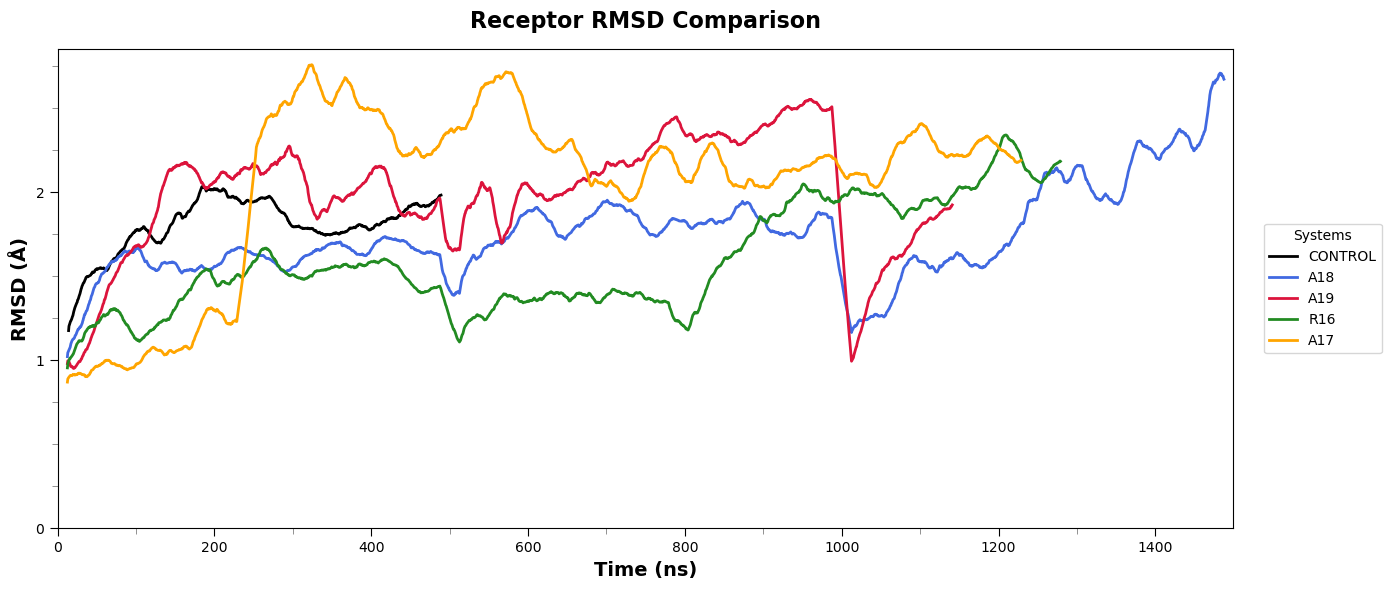

In [7]:
# Cell 2: Plotting RMSD System Comparison and Data Aggregation
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd

fig_rmsd, ax_rmsd = plt.subplots(figsize=(14, 6))
print("Generating RMSD comparison plot and aggregating data...")

# =====================================================================
systems_to_show = ["CONTROL", "A18", "A19", "R16", "A17"] 
# =====================================================================

window_size = 50 
max_x_val = 0    
rmsd_data_dict = {} 

for system, filepath in rmsd_files.items():
    df = pd.read_csv(filepath)
    
    # --- THE FIX: Strict Priority Targeting ---
    # First look strictly for 'Time_ns'. If not found, fall back to 'Time', then 'Frame'.
    x_col = next((col for col in df.columns if col == 'Time_ns'), None) \
         or next((col for col in df.columns if 'Time' in col), None) \
         or next((col for col in df.columns if 'Frame' in col), df.index)
    
    x_data = df[x_col] if isinstance(x_col, str) else x_col
    # ------------------------------------------
    
    y_col = next((col for col in df.columns if 'RMSD' in col.upper()), None)
    
    if y_col:
        smoothed_rmsd = df[y_col].rolling(window=window_size, center=True).mean()
        rmsd_data_dict[system] = pd.Series(smoothed_rmsd.values, index=x_data)
        
        if system in systems_to_show:
            ax_rmsd.plot(x_data, smoothed_rmsd, label=system, 
                         color=system_colors[system], linewidth=2.0)
            
            current_max = x_data.max()
            if current_max > max_x_val: max_x_val = current_max
            
# --- Create Master DataFrame ---
df_rmsd_master = pd.DataFrame(rmsd_data_dict).reset_index().rename(columns={'index': 'Time_ns'})

# --- Advanced Axis Formatting ---
ax_rmsd.xaxis.set_major_locator(ticker.MultipleLocator(200))
ax_rmsd.xaxis.set_minor_locator(ticker.MultipleLocator(100))
ax_rmsd.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
ax_rmsd.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))

ax_rmsd.tick_params(axis='both', which='major', length=6, color='black')
ax_rmsd.tick_params(axis='both', which='minor', length=4, color='gray')

ax_rmsd.set_title("Receptor RMSD Comparison", fontsize=16, fontweight='bold', pad=15)
ax_rmsd.set_xlabel("Time (ns)", fontsize=14, fontweight='bold')
ax_rmsd.set_ylabel("RMSD (Å)", fontsize=14, fontweight='bold')
ax_rmsd.set_xlim(0, max_x_val if max_x_val > 0 else 5000)
ax_rmsd.set_ylim(0, None) 
ax_rmsd.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True, title="Systems")

plt.tight_layout()

Generating Ligand RMSD comparison plot...


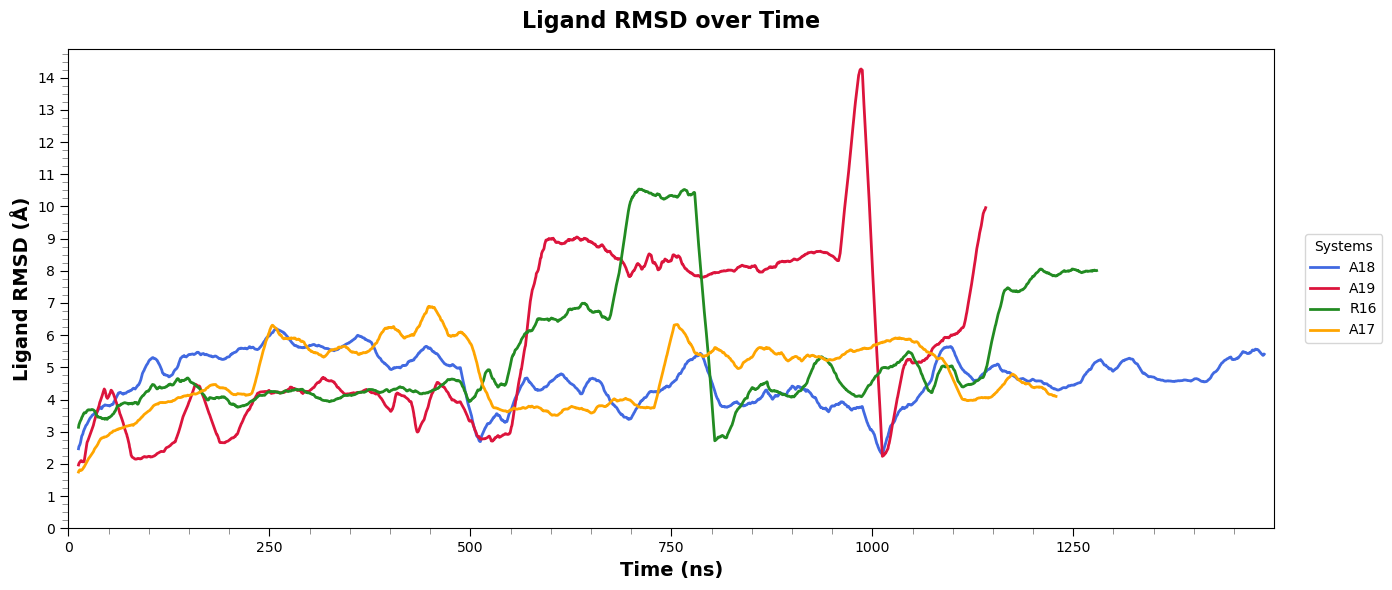

In [8]:
# Cell 3: Plotting Ligand RMSD System Comparison
fig_lig_rmsd, ax_lig_rmsd = plt.subplots(figsize=(14, 6))
print("Generating Ligand RMSD comparison plot...")

max_x_val_lig = 0    
lig_rmsd_data_dict = {} 

for system, filepath in rmsd_files.items():
    df = pd.read_csv(filepath)
    
    # --- THE FIX: Strict Priority Targeting ---
    x_col = next((col for col in df.columns if col == 'Time_ns'), None) \
         or next((col for col in df.columns if 'Time' in col), None) \
         or next((col for col in df.columns if 'Frame' in col), df.index)
    
    x_data = df[x_col] if isinstance(x_col, str) else x_col
    # ------------------------------------------
    
    y_col = next((col for col in df.columns if 'Ligand_RMSD' in col or 'LIG_RMSD' in col), None)
    
    if y_col:
        smoothed_lig_rmsd = df[y_col].rolling(window=window_size, center=True).mean()
        lig_rmsd_data_dict[system] = pd.Series(smoothed_lig_rmsd.values, index=x_data)
        
        if system in systems_to_show:
            ax_lig_rmsd.plot(x_data, smoothed_lig_rmsd, label=system, 
                             color=system_colors[system], linewidth=2.0)
            
            current_max = x_data.max()
            if current_max > max_x_val_lig: max_x_val_lig = current_max
    else:
        if system != "CONTROL":
            print(f" -> WARNING: No Ligand RMSD data found for {system}!")

if lig_rmsd_data_dict:
    df_lig_rmsd_master = pd.DataFrame(lig_rmsd_data_dict).reset_index().rename(columns={'index': 'Time_ns'})

    ax_lig_rmsd.xaxis.set_major_locator(ticker.MultipleLocator(250))
    ax_lig_rmsd.xaxis.set_minor_locator(ticker.MultipleLocator(50))
    ax_lig_rmsd.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
    ax_lig_rmsd.yaxis.set_minor_locator(ticker.MultipleLocator(0.25))

    ax_lig_rmsd.tick_params(axis='both', which='major', length=6, color='black')
    ax_lig_rmsd.tick_params(axis='both', which='minor', length=4, color='gray')

    ax_lig_rmsd.set_title("Ligand RMSD over Time", fontsize=16, fontweight='bold', pad=15)
    ax_lig_rmsd.set_xlabel("Time (ns)", fontsize=14, fontweight='bold')
    ax_lig_rmsd.set_ylabel("Ligand RMSD (Å)", fontsize=14, fontweight='bold')

    ax_lig_rmsd.set_xlim(0, max_x_val_lig if max_x_val_lig > 0 else 5000)
    ax_lig_rmsd.set_ylim(0, None) 
    ax_lig_rmsd.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True, title="Systems")

    plt.tight_layout()
else:
    print("No Ligand RMSD data was aggregated. Plot will be empty.")

Generating RMSD Boxplots...


/tmp/ipykernel_6626/192460092.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='System', y='RMSD', data=df_rec_melted, palette=system_colors,
/tmp/ipykernel_6626/192460092.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='System', y='Ligand_RMSD', data=df_lig_melted, palette=system_colors,


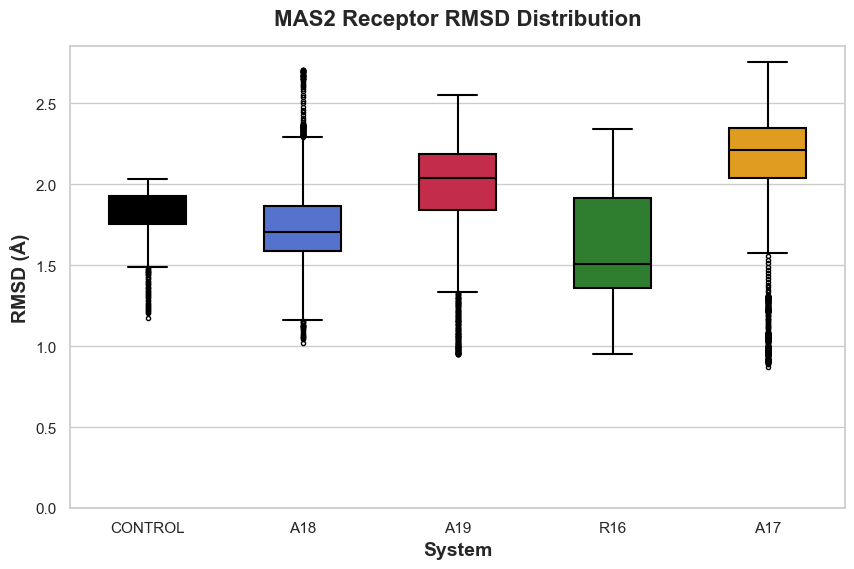

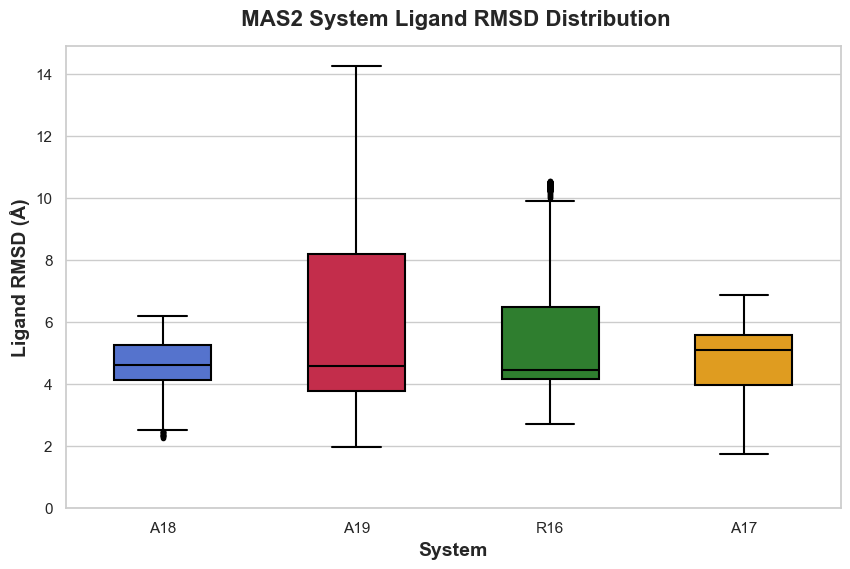

In [9]:
# Cell 4: Statistical Boxplot Comparison
import seaborn as sns

print("Generating RMSD Boxplots...")
sns.set_context("notebook")
sns.set_style("whitegrid")

# --- 1. RECEPTOR BOXPLOT ---
if 'df_rmsd_master' in locals() and not df_rmsd_master.empty:
    fig_box_rec, ax_box_rec = plt.subplots(figsize=(10, 6))
    df_rec_melted = df_rmsd_master.melt(id_vars=['Time_ns'], var_name='System', value_name='RMSD').dropna()
    df_rec_melted = df_rec_melted[df_rec_melted['System'].isin(systems_to_show)]
    
    sns.boxplot(x='System', y='RMSD', data=df_rec_melted, palette=system_colors, 
                ax=ax_box_rec, width=0.5, fliersize=3, linewidth=1.5)
    
    ax_box_rec.set_title(f'{systemid} Receptor RMSD Distribution', fontsize=16, fontweight='bold', pad=15)
    ax_box_rec.set_xlabel("System", fontsize=14, fontweight='bold')
    ax_box_rec.set_ylabel("RMSD (Å)", fontsize=14, fontweight='bold')
    ax_box_rec.set_ylim(0, None)

# --- 2. LIGAND BOXPLOT ---
if 'df_lig_rmsd_master' in locals() and not df_lig_rmsd_master.empty:
    fig_box_lig, ax_box_lig = plt.subplots(figsize=(10, 6))
    df_lig_melted = df_lig_rmsd_master.melt(id_vars=['Time_ns'], var_name='System', value_name='Ligand_RMSD').dropna()
    
    valid_lig_systems = [s for s in systems_to_show if s in df_lig_rmsd_master.columns]
    df_lig_melted = df_lig_melted[df_lig_melted['System'].isin(valid_lig_systems)]
    
    sns.boxplot(x='System', y='Ligand_RMSD', data=df_lig_melted, palette=system_colors, 
                ax=ax_box_lig, width=0.5, fliersize=3, linewidth=1.5)
    
    ax_box_lig.set_title(f' {systemid} System Ligand RMSD Distribution', fontsize=16, fontweight='bold', pad=15)
    ax_box_lig.set_xlabel("System", fontsize=14, fontweight='bold')
    ax_box_lig.set_ylabel("Ligand RMSD (Å)", fontsize=14, fontweight='bold')
    ax_box_lig.set_ylim(0, None)

plt.show()

In [10]:
# Cell 5: Master Export Node
print("Initiating Master File Export...")

# --- 1. Export Receptor Trajectory Data ---
if 'df_rmsd_master' in locals() and not df_rmsd_master.empty:
    df_rmsd_master.to_csv(fn_rmsd_table_csv, index=False)
    fig_rmsd.savefig(fn_rmsd_comp_png, dpi=1200, bbox_inches='tight')
    fig_rmsd.savefig(fn_rmsd_comp_pdf, bbox_inches='tight')
    print(f" [Saved] Receptor RMSD Data & Line Plots")

# --- 2. Export Ligand Trajectory Data ---
if 'df_lig_rmsd_master' in locals() and not df_lig_rmsd_master.empty:
    df_lig_rmsd_master.to_csv(fn_lig_rmsd_table_csv, index=False)
    fig_lig_rmsd.savefig(fn_lig_rmsd_comp_png, dpi=1200, bbox_inches='tight')
    fig_lig_rmsd.savefig(fn_lig_rmsd_comp_pdf, bbox_inches='tight')
    print(f" [Saved] Ligand RMSD Data & Line Plots")

# --- 3. Export Receptor Boxplots ---
if 'fig_box_rec' in locals():
    fig_box_rec.savefig(fn_box_rec_png, dpi=1200, bbox_inches='tight')
    fig_box_rec.savefig(fn_box_rec_pdf, bbox_inches='tight')
    print(f" [Saved] Receptor Boxplots")

# --- 4. Export Ligand Boxplots ---
if 'fig_box_lig' in locals():
    fig_box_lig.savefig(fn_box_lig_png, dpi=1200, bbox_inches='tight')
    fig_box_lig.savefig(fn_box_lig_pdf, bbox_inches='tight')
    print(f" [Saved] Ligand Boxplots")

print("\nAll analyses successfully exported to disk!")

Initiating Master File Export...
 [Saved] Receptor RMSD Data & Line Plots
 [Saved] Ligand RMSD Data & Line Plots
 [Saved] Receptor Boxplots
 [Saved] Ligand Boxplots

All analyses successfully exported to disk!


# RMSF Data Comparison

Dont forget to set __folder__ with the system __data__

In [61]:
# Cell 2: General Pathing and Dynamic File Discovery
general_folder_path = f"{systemid}/DATA"

# Master Color Palette (Guarantees consistency across all your comparison plots)
system_colors = {
    "CONTROL": "black",
    "A18": "royalblue",
    "A19": "crimson",
    "R16": "forestgreen",
    "A17": "orange"
}

# Dictionary to store the dynamically found file paths
rmsf_files = {}

print(f"Scanning '{general_folder_path}' for Receptor RMSF files...")

for system in system_colors.keys():
    # Use glob to search for any CSV containing 'Receptor_RMSF' in its name
    search_pattern = os.path.join(general_folder_path, system, "*Receptor_RMSF*.csv")
    found_files = glob.glob(search_pattern)
    
    if found_files:
        rmsf_files[system] = found_files[0] # Grab the first matched file
        print(f"{system}: Found '{os.path.basename(found_files[0])}'")
    else:
        print(f"{system}: No Receptor RMSF file found.")

Scanning 'MAS2/DATA' for Receptor RMSF files...
CONTROL: Found 'CONTROL_Receptor_RMSF_Data.csv'
A18: Found 'A18_Receptor_RMSF_Data.csv'
A19: Found 'A19_Receptor_RMSF_Data.csv'
R16: Found 'R16_Receptor_RMSF_Data.csv'
A17: Found 'A17_Receptor_RMSF_Data.csv'


In [62]:
# Cell 2.5: Global Output File Registry

# 1. Define the master output directory
output_dir = general_folder_path
os.makedirs(output_dir, exist_ok=True) # Safety check to ensure the folder exists

# 2. Define output paths for the Differential Analysis Table
fn_diff_table_csv = os.path.join(output_dir, "RMSF_Differential_Analysis.csv")

# 3. Define output paths for the RMSF Comparison Plots
fn_rmsf_comp_png = os.path.join(output_dir, "RMSF_System_Comparison.png")
fn_rmsf_comp_pdf = os.path.join(output_dir, "RMSF_System_Comparison.pdf")

In [63]:
# Cell 3: Calculate RMSF Differences vs. CONTROL
print("Aggregating data and calculating differences compared to CONTROL...\n")

df_combined = pd.DataFrame()
diff_cols = []

# 1. Load CONTROL first as the baseline
if "CONTROL" in rmsf_files:
    df_ctrl = pd.read_csv(rmsf_files["CONTROL"])
    y_col_ctrl = next((col for col in df_ctrl.columns if 'RMSF' in col or 'Average' in col), None)
    
    df_combined['Residue'] = df_ctrl['Residue'] if 'Residue' in df_ctrl.columns else df_ctrl.index
    df_combined['CONTROL'] = df_ctrl[y_col_ctrl]
else:
    print("ERROR: CONTROL file not found. Cannot establish baseline.")

# 2. Load the other systems and calculate their delta (Δ) from CONTROL
for system, filepath in rmsf_files.items():
    if system == "CONTROL": 
        continue
        
    df_sys = pd.read_csv(filepath)
    y_col = next((col for col in df_sys.columns if 'RMSF' in col or 'Average' in col), None)
    
    df_combined[system] = df_sys[y_col]
    
    # Calculate the difference (Positive = more flexible than control; Negative = more rigid)
    diff_col_name = f"{system}_Diff"
    df_combined[diff_col_name] = df_combined[system] - df_combined['CONTROL']
    diff_cols.append(diff_col_name)

# 3. Calculate Maximum Absolute Difference to rank the impact severity
df_combined['Max_Abs_Diff'] = df_combined[diff_cols].abs().max(axis=1)

# Sort the table to show the most altered residues at the top
df_top_diffs = df_combined.sort_values(by='Max_Abs_Diff', ascending=False).reset_index(drop=True)

print("Top 20 Residues with the largest RMSF structural shift (ΔRMSF):")
display_cols = ['Residue', 'CONTROL'] + [sys for sys in system_colors.keys() if sys != 'CONTROL'] + diff_cols + ['Max_Abs_Diff']
display(df_top_diffs[display_cols].head(20))

Aggregating data and calculating differences compared to CONTROL...

Top 20 Residues with the largest RMSF structural shift (ΔRMSF):


,Residue,CONTROL,A18,A19,R16,A17,A18_Diff,A19_Diff,R16_Diff,A17_Diff,Max_Abs_Diff
0,149,1.569631,4.677315,3.600173,1.712454,2.970891,3.107684,2.030542,0.142823,1.401260,3.107684
1,228,0.993539,1.115048,1.096187,4.082780,1.306750,0.121509,0.102648,3.089241,0.313211,3.089241
2,147,2.091225,4.834229,4.604749,2.308181,3.283232,2.743004,2.513524,0.216956,1.192007,2.743004
3,148,1.990374,4.052440,4.480795,1.703017,3.794214,2.062065,2.490420,-0.287358,1.803839,2.490420
4,227,1.159994,1.462111,1.380349,3.253462,1.718360,0.302118,0.220355,2.093469,0.558367,2.093469
5,146,2.460125,4.086532,4.492175,2.666334,3.056614,1.626407,2.032050,0.206209,0.596489,2.032050
6,150,1.546863,3.561233,3.342414,1.711720,1.619627,2.014369,1.795551,0.164856,0.072763,2.014369
7,153,0.924093,2.853616,1.706508,1.430445,1.021022,1.929523,0.782415,0.506352,0.096929,1.929523
8,151,0.944132,2.834814,1.668951,1.663214,1.043051,1.890681,0.724818,0.719082,0.098919,1.890681
9,152,0.967115,2.829732,1.543806,1.745991,1.059709,1.862617,0.576691,0.778876,0.092594,1.862617


In [64]:
# Cell 4: Export Differential Table

# Save the fully sorted master table to disk using the global registry
df_top_diffs[display_cols].to_csv(fn_diff_table_csv, index=False)

print(f"Differential analysis successfully saved to: {fn_diff_table_csv}")

Differential analysis successfully saved to: MAS2/DATA/RMSF_Differential_Analysis.csv


## Remember
Set the corresponding protein length for the plot.

Add a __+1 residue__ to the total length to make the plot not end abruptly

Generating RMSF comparison plot...


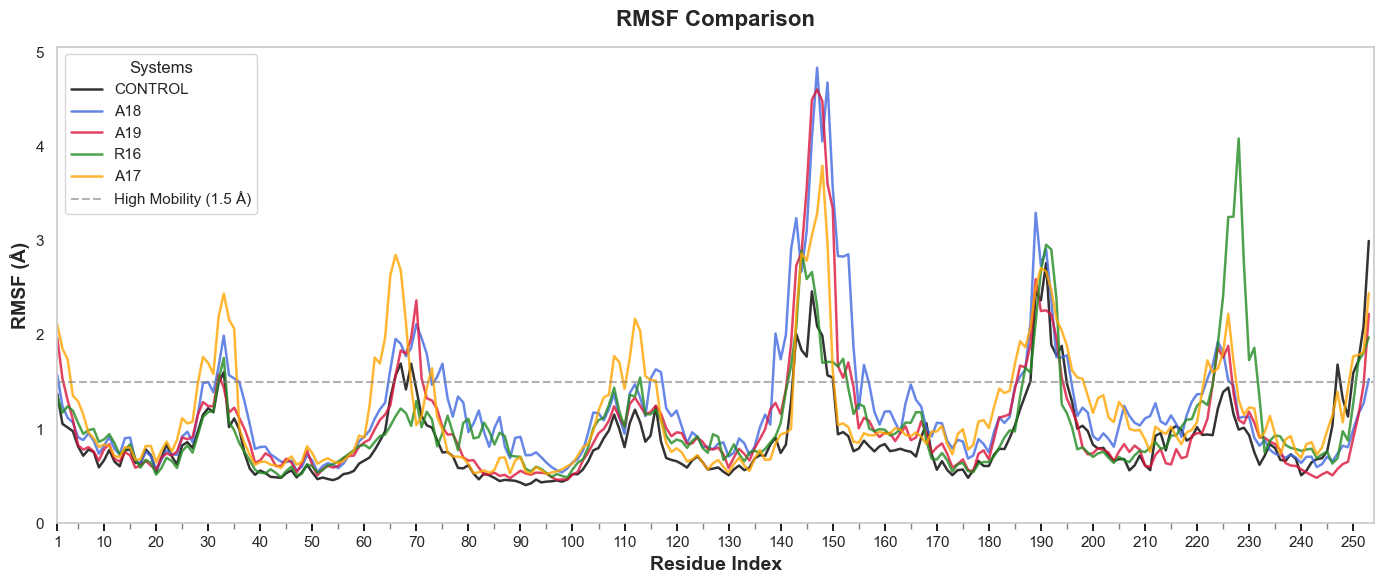

In [65]:
# Cell 5: Plotting Receptor RMSF Comparison with Custom Axes
fig, ax = plt.subplots(figsize=(14, 6))

print("Generating RMSF comparison plot...")

# --- 1. Plot the Data ---
for system in system_colors.keys():
    if system in df_combined.columns:
        ax.plot(df_combined['Residue'], df_combined[system], label=system, 
                color=system_colors[system], linewidth=1.8, alpha=0.8)

# --- 2. Advanced Axis Formatting ---
major_tick_interval = 10   # Place a major number every 10 residues
minor_tick_interval = 5    # Place small unnumbered ticks every 5 residues
final_residue = 255        # Force this residue to appear at the end

# Generate the major ticks (e.g., 0, 10, 20...)
major_ticks = list(range(0, final_residue + 1, major_tick_interval))

# Ensure the plot starts at Residue 1 instead of 0
if major_ticks[0] == 0:
    major_ticks[0] = 1 

# Force the final residue onto the list if the math missed it
if final_residue not in major_ticks:
    major_ticks.append(final_residue)

# Apply the ticks to the plot
ax.set_xticks(major_ticks)
ax.xaxis.set_minor_locator(ticker.MultipleLocator(minor_tick_interval))

# --- THE FIXES ---
# Force Seaborn to physically draw the tick marks on the bottom edge
ax.tick_params(axis='x', which='major', bottom=True, length=6, color='black')
ax.tick_params(axis='x', which='minor', bottom=True, length=4, color='gray')

# Turn off the default background grid mesh
ax.grid(False)
# -----------------

# --- 3. Styling and Labels ---
ax.set_title("RMSF Comparison", fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel("Residue Index", fontsize=14, fontweight='bold')
ax.set_ylabel("RMSF (Å)", fontsize=14, fontweight='bold')

# Threshold line for high-mobility visual reference (This will be the ONLY horizontal line)
ax.axhline(y=1.5, color='gray', linestyle='--', alpha=0.6, label='High Mobility (1.5 Å)')

ax.set_xlim(1, 254) #<--------------------------------------------------------------- PROTEIN / PLOT LENGTH ------------------------------------------------------>
ax.set_ylim(0, None)
ax.legend(loc='upper left', frameon=True, title="Systems")

plt.tight_layout()

# The figure will display automatically here

In [66]:
# Cell 6: Save the RMSF Plot

# Export the active figure using the global registry
fig.savefig(fn_rmsf_comp_png, dpi=1200, bbox_inches='tight')
fig.savefig(fn_rmsf_comp_pdf, bbox_inches='tight')

print("Plot successfully saved to:")
print(f" -> {fn_rmsf_comp_png}")
print(f" -> {fn_rmsf_comp_pdf}")

Plot successfully saved to:
 -> MAS2/DATA/RMSF_System_Comparison.png
 -> MAS2/DATA/RMSF_System_Comparison.pdf


# Secondary Structure Content Comparison

## Parsing

In [20]:
# Cell 7: Secondary Structure File Discovery & Output Registry
general_folder_path = f"{systemid}/DATA"

system_colors = {
    "CONTROL": "black",
    "A18": "royalblue",
    "A19": "crimson",
    "R16": "forestgreen",
    "A17": "orange"
}

ss_files = {}
print(f"Scanning '{general_folder_path}' for Receptor SS (Per Residue) files...\n")

for system in system_colors.keys():
    search_pattern_1 = os.path.join(general_folder_path, system, "*Receptor_SS_Per_Res.csv")
    search_pattern_2 = os.path.join(general_folder_path, system, "*Receptor_SS_per_res.csv")
    
    found_files = glob.glob(search_pattern_1) + glob.glob(search_pattern_2)
    
    if found_files:
        ss_files[system] = found_files[0]
        print(f"  {system}: Found '{os.path.basename(found_files[0])}'")
    else:
        print(f"  {system}: No SS file found.")

# ── Output Registry ────────────────────────────────────────────────────────────

# --- Tables ---
fn_ss_diff_csv        = os.path.join(general_folder_path, "SS_Structural_Variation_Master.csv")
fn_ss_relative_diff   = os.path.join(general_folder_path, "SS_Differential_vs_Control.csv")

# --- Full Heatmaps ---
fn_helix_heat_png     = os.path.join(general_folder_path, "SS_AlphaHelix_Heatmap.png")
fn_helix_heat_pdf     = os.path.join(general_folder_path, "SS_AlphaHelix_Heatmap.pdf")

fn_beta_heat_png      = os.path.join(general_folder_path, "SS_BetaSheet_Heatmap.png")
fn_beta_heat_pdf      = os.path.join(general_folder_path, "SS_BetaSheet_Heatmap.pdf")

# --- Differential Heatmaps ---
fn_diff_helix_png     = os.path.join(general_folder_path, "SS_Differential_Helix_Heatmap.png")
fn_diff_helix_pdf     = os.path.join(general_folder_path, "SS_Differential_Helix_Heatmap.pdf")

fn_diff_beta_png      = os.path.join(general_folder_path, "SS_Differential_Beta_Heatmap.png")
fn_diff_beta_pdf      = os.path.join(general_folder_path, "SS_Differential_Beta_Heatmap.pdf")

# --- Zoomed Heatmaps ---
fn_diff_beta_zoom_png = os.path.join(general_folder_path, "SS_Differential_Beta_Heatmap_Zoomed.png")
fn_diff_beta_zoom_pdf = os.path.join(general_folder_path, "SS_Differential_Beta_Heatmap_Zoomed.pdf")

fn_beta_zoom_png      = os.path.join(general_folder_path, "SS_BetaSheet_Heatmap_Zoomed.png")
fn_beta_zoom_pdf      = os.path.join(general_folder_path, "SS_BetaSheet_Heatmap_Zoomed.pdf")

# --- Composite Plots ---

fn_composite_helix_png = os.path.join(general_folder_path, "SS_Helix_Composite.png")
fn_composite_helix_pdf = os.path.join(general_folder_path, "SS_Helix_Composite.pdf")

# --- Per-Domain Helix Heatmaps (dictionary keyed by domain name) ---
helix_domains = ['TM1', 'TM2', 'TM3', 'TM4', 'TM5', 'TM6', 'TM7', 'Helix8']

fn_helix_domain_png = {
    d: os.path.join(general_folder_path, f"SS_Helix_{d}_Zoomed.png")
    for d in helix_domains
}
fn_helix_domain_pdf = {
    d: os.path.join(general_folder_path, f"SS_Helix_{d}_Zoomed.pdf")
    for d in helix_domains
}

print("\nOutput registry configured.")

Scanning 'MAS2/DATA' for Receptor SS (Per Residue) files...

  CONTROL: Found 'CONTROL_Receptor_SS_Per_Res.csv'
  A18: Found 'A18_Receptor_SS_Per_Res.csv'
  A19: Found 'A19_Receptor_SS_Per_Res.csv'
  R16: Found 'R16_Receptor_SS_Per_Res.csv'
  A17: Found 'A17_Receptor_SS_Per_Res.csv'

Output registry configured.


In [21]:
# Cell 8: Calculate Helix and Beta Sheet Variations

print("Aggregating SS data and calculating structural variation...\n")

df_ss_helix = pd.DataFrame() 
df_ss_beta = pd.DataFrame()

for system, filepath in ss_files.items():
    df = pd.read_csv(filepath)
    res_col = df['Residue'] if 'Residue' in df.columns else df.index
    
    if df_ss_helix.empty:
        df_ss_helix['Residue'] = res_col
        df_ss_beta['Residue'] = res_col
        
    helix_col = next((col for col in df.columns if 'Helix' in col), None)
    beta_col = next((col for col in df.columns if 'Beta' in col or 'Sheet' in col), None)
    
    df_ss_helix[system] = df[helix_col] if helix_col else 0.0
    df_ss_beta[system] = df[beta_col] if beta_col else 0.0

sys_cols = list(system_colors.keys())

# 1. Calculate Maximum Variations
df_ss_helix['Max_Helix_Diff_%'] = df_ss_helix[sys_cols].max(axis=1) - df_ss_helix[sys_cols].min(axis=1)
df_ss_beta['Max_Beta_Diff_%'] = df_ss_beta[sys_cols].max(axis=1) - df_ss_beta[sys_cols].min(axis=1)

# 2. Sort to find the most disrupted segments
df_top_helix = df_ss_helix.sort_values(by='Max_Helix_Diff_%', ascending=False).reset_index(drop=True)
df_top_beta = df_ss_beta.sort_values(by='Max_Beta_Diff_%', ascending=False).reset_index(drop=True)

print("--- TOP 15 RESIDUES: ALPHA HELIX VARIATION (Unfolding/Locking) ---")
display(df_top_helix.head(15))

print("\n--- TOP 15 RESIDUES: BETA SHEET VARIATION (Formation/Breaking) ---")
display(df_top_beta.head(15))

# 3. Create the master table variable for export
df_master_variation = pd.merge(df_ss_helix, df_ss_beta, on='Residue', suffixes=('_Helix', '_Beta'))
print("\nVariation analysis complete. Data ready for plotting and saving.")

Aggregating SS data and calculating structural variation...

--- TOP 15 RESIDUES: ALPHA HELIX VARIATION (Unfolding/Locking) ---


,Residue,CONTROL,A18,A19,R16,A17,Max_Helix_Diff_%
0,194,0.0,99.700000,99.349805,81.881533,100.000000,100.000000
1,195,0.2,99.766667,99.609883,98.296554,100.000000,99.800000
2,193,0.0,98.300000,99.306459,83.894696,99.476229,99.476229
3,165,99.4,99.666667,1.083658,100.000000,100.000000,98.916342
4,168,34.8,87.200000,99.913307,1.122726,2.377115,98.790582
5,192,0.0,82.700000,97.659298,83.004259,98.307816,98.307816
6,229,24.3,99.800000,39.011704,2.284166,97.985496,97.515834
7,211,97.7,55.900000,0.433463,0.309717,53.424658,97.390283
8,230,24.3,99.900000,96.618986,2.710027,99.919420,97.209393
9,151,61.9,4.133333,67.490247,99.883856,98.630137,95.750523



--- TOP 15 RESIDUES: BETA SHEET VARIATION (Formation/Breaking) ---


,Residue,CONTROL,A18,A19,R16,A17,Max_Beta_Diff_%
0,145,0.0,22.333333,0.0,0.000000,0.00000,22.333333
1,147,22.1,0.000000,0.0,0.000000,0.04029,22.100000
2,150,22.1,21.733333,0.0,0.000000,0.00000,22.100000
3,144,2.4,0.000000,0.0,0.000000,0.00000,2.400000
4,140,2.3,0.166667,0.0,0.116144,0.04029,2.300000
5,148,0.0,0.633333,0.0,0.000000,0.00000,0.633333
6,143,0.0,0.166667,0.0,0.116144,0.00000,0.166667
7,149,0.0,0.000000,0.0,0.000000,0.08058,0.080580
8,228,0.0,0.000000,0.0,0.077429,0.00000,0.077429
9,224,0.0,0.000000,0.0,0.000000,0.04029,0.040290



Variation analysis complete. Data ready for plotting and saving.


Generating Alpha Helix Continuous Percentage Heatmap...


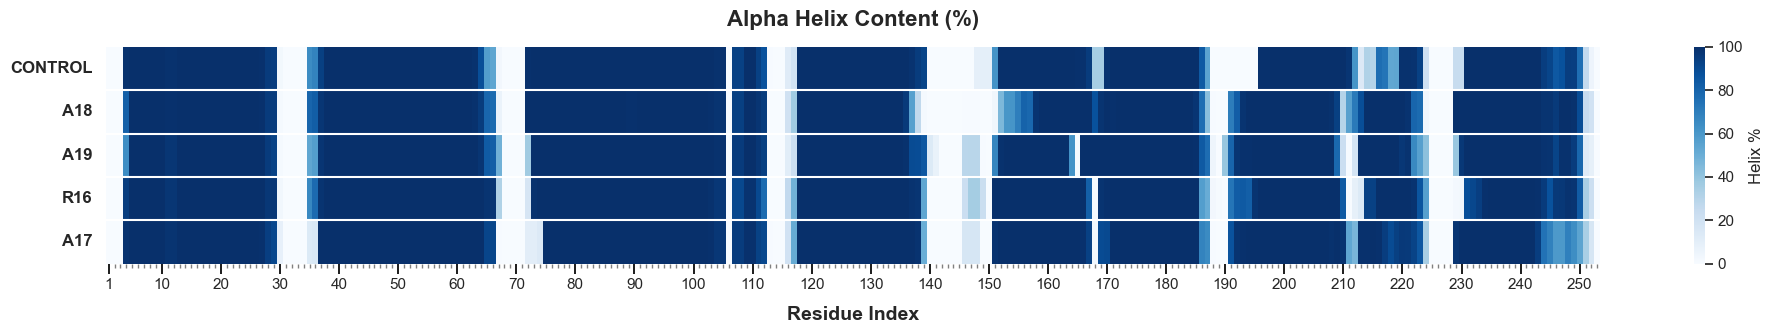

In [22]:
# Cell 9: Plotting Alpha Helix Percentage Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating Alpha Helix Continuous Percentage Heatmap...")

# Prepare data: Residue as index, transposed so Systems are rows
heat_helix = df_ss_helix.set_index('Residue')[sys_cols].T

# Setup a wide, short figure (perfect for 4 rows)
fig_helix, ax_helix = plt.subplots(figsize=(20, 3.5))

# Draw Heatmap (Blues: 0% = White, 100% = Dark Blue)
sns.heatmap(heat_helix, cmap='Blues', vmin=0, vmax=100, ax=ax_helix, cbar_kws={'label': 'Helix %'})

# --- 1. Horizontal Row Separators ---
# Draw crisp lines between the systems to guide the eye
for y in range(1, len(sys_cols)):
    ax_helix.axhline(y=y, color='white', linewidth=1.5)

# --- 2. Advanced Tick Formatting ---
major_tick_interval = 10
final_residue = 310
major_tick_positions, major_tick_labels = [], []
minor_tick_positions = []

for i, res in enumerate(heat_helix.columns):
    center_pos = i + 0.5
    minor_tick_positions.append(center_pos) # Every single residue gets a minor tick
    
    if res == 1 or res % major_tick_interval == 0 or res == final_residue:
        major_tick_positions.append(center_pos)
        major_tick_labels.append(res)

# Apply Major Ticks
ax_helix.set_xticks(major_tick_positions)
ax_helix.set_xticklabels(major_tick_labels, rotation=0, fontsize=11)
ax_helix.tick_params(axis='x', which='major', bottom=True, length=7, color='black')

# Apply Minor Ticks (every single value)
ax_helix.set_xticks(minor_tick_positions, minor=True)
ax_helix.tick_params(axis='x', which='minor', bottom=True, length=3, color='gray')

# Format Y-axis System Labels
ax_helix.set_yticklabels(ax_helix.get_yticklabels(), rotation=0, fontweight='bold', fontsize=12)

# --- 3. Styling ---
ax_helix.set_title("Alpha Helix Content (%)", fontsize=16, fontweight='bold', pad=15)
ax_helix.set_xlabel("Residue Index", fontsize=14, fontweight='bold', labelpad=10)
ax_helix.set_ylabel("")

plt.tight_layout()

Generating Beta Sheet Continuous Percentage Heatmap...


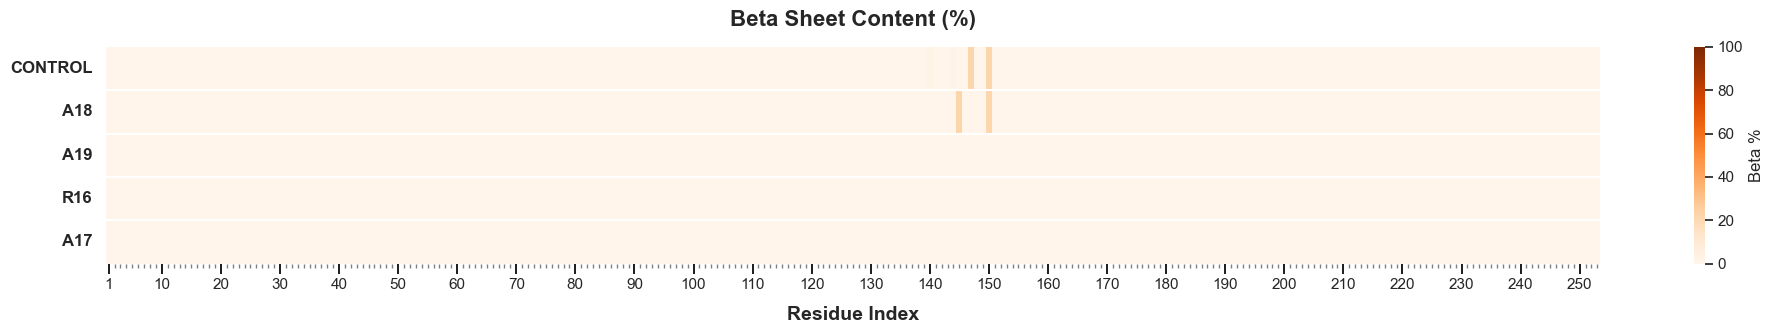

In [23]:
# Cell 10: Plotting Beta Sheet Percentage Heatmap
print("Generating Beta Sheet Continuous Percentage Heatmap...")

# Prepare data
heat_beta = df_ss_beta.set_index('Residue')[sys_cols].T

# Setup figure
fig_beta, ax_beta = plt.subplots(figsize=(20, 3.5))

# Draw Heatmap (Oranges: 0% = White, 100% = Dark Orange)
sns.heatmap(heat_beta, cmap='Oranges', vmin=0, vmax=100, ax=ax_beta, cbar_kws={'label': 'Beta %'})

# --- 1. Horizontal Row Separators ---
for y in range(1, len(sys_cols)):
    ax_beta.axhline(y=y, color='white', linewidth=1.5)

# --- 2. Independent Tick Formatting ---
# Computed fresh from heat_beta.columns, not inherited from Cell 9
major_tick_interval = 10
final_residue = 310
major_tick_positions, major_tick_labels, minor_tick_positions = [], [], []

for i, res in enumerate(heat_beta.columns):
    center_pos = i + 0.5
    minor_tick_positions.append(center_pos)

    if res == 1 or res % major_tick_interval == 0 or res == final_residue:
        major_tick_positions.append(center_pos)
        major_tick_labels.append(res)

# Apply Major Ticks
ax_beta.set_xticks(major_tick_positions)
ax_beta.set_xticklabels(major_tick_labels, rotation=0, fontsize=11)
ax_beta.tick_params(axis='x', which='major', bottom=True, length=7, color='black')

# Apply Minor Ticks
ax_beta.set_xticks(minor_tick_positions, minor=True)
ax_beta.tick_params(axis='x', which='minor', bottom=True, length=3, color='gray')

# Format Y-axis
ax_beta.set_yticklabels(ax_beta.get_yticklabels(), rotation=0, fontweight='bold', fontsize=12)

# --- 3. Styling ---
ax_beta.set_title("Beta Sheet Content (%)", fontsize=16, fontweight='bold', pad=15)
ax_beta.set_xlabel("Residue Index", fontsize=14, fontweight='bold', labelpad=10)
ax_beta.set_ylabel("")

plt.tight_layout()

In [24]:
# Cell 11: Export Secondary Structure Data and Heatmaps
print("Saving Secondary Structure analysis files to disk...")

# 1. Save the Master Variation CSV Table
df_master_variation.to_csv(fn_ss_diff_csv, index=False)
print(f" -> Table saved: {fn_ss_diff_csv}")

# 2. Save the Helix Heatmap
fig_helix.savefig(fn_helix_heat_png, dpi=600, bbox_inches='tight')
fig_helix.savefig(fn_helix_heat_pdf, bbox_inches='tight')
print(f" -> Plot saved: {fn_helix_heat_png} | .pdf")

# 3. Save the Beta Heatmap
fig_beta.savefig(fn_beta_heat_png, dpi=600, bbox_inches='tight')
fig_beta.savefig(fn_beta_heat_pdf, bbox_inches='tight')
print(f" -> Plot saved: {fn_beta_heat_png} | .pdf")

print("\nAll Secondary Structure exports completed successfully!")

Saving Secondary Structure analysis files to disk...
 -> Table saved: MAS2/DATA/SS_Structural_Variation_Master.csv
 -> Plot saved: MAS2/DATA/SS_AlphaHelix_Heatmap.png | .pdf
 -> Plot saved: MAS2/DATA/SS_BetaSheet_Heatmap.png | .pdf

All Secondary Structure exports completed successfully!


In [25]:
# Cell 12: Secondary Structure Differential Analysis (Helix & Beta vs CONTROL)
import pandas as pd
import os

print("Calculating structural changes relative to CONTROL...\n")

# --- 1. Master Domain Dictionaries ---
domain_ranges_at1r = {
    'N-Term': (1, 14), 'TM1': (15, 45), 'ICL1': (46, 51), 'TM2': (52, 79),
    'ECL1': (80, 87), 'TM3': (88, 121), 'ICL2': (122, 131), 'TM4': (132, 156),
    'ECL2': (157, 179), 'TM5': (180, 219), 'ICL3': (220, 226), 'TM6': (227, 257),
    'ECL3': (258, 263), 'TM7': (264, 291), 'Helix8': (292, 308), 'C-Term': (309, 310)
}

domain_ranges_at2r = {
    'N-Term': (1, 6), 'TM1': (7, 37), 'ICL1': (38, 43), 'TM2': (44, 71),
    'ECL1': (72, 78), 'TM3': (79, 113), 'ICL2': (114, 122), 'TM4': (123, 147),
    'ECL2': (148, 166), 'TM5': (167, 207), 'ICL3': (208, 213), 'TM6': (214, 250),
    'ECL3': (251, 255), 'TM7': (256, 278), 'Turn/H8a': (279, 290), 'Helix8': (291, 300),
    'C-Term': (301, 306)
}

domain_ranges_mas1 = {
    'N-Term': (1, 3), 'TM1': (4, 31), 'ICL1': (32, 34), 'TM2': (35, 66),
    'ECL1': (67, 71), 'TM3': (72, 105), 'ICL2': (106, 117), 'TM4': (118, 139),
    'ECL2': (140, 150), 'TM5': (151, 187), 'ICL3': (188, 195), 'TM6': (196, 213),
    'ECL3': (214, 228), 'TM7': (229, 251), 'C-Term': (252, 253)
}

# --- 2. Dynamic System Selection ---
if "AT2R" in systemid.upper():
    domain_ranges = domain_ranges_at2r
    print(" -> AT2R detected. Loading AT2R domain boundaries.")
elif "MAS" in systemid.upper():
    domain_ranges = domain_ranges_mas1
    print(" -> MAS1 detected. Loading MAS1 domain boundaries.")
elif "AT1R" in systemid.upper():
    domain_ranges = domain_ranges_at1r
    print(" -> AT1R detected. Loading AT1R domain boundaries.")
else:
    print(f" -> WARNING: '{systemid}' not explicitly recognized. Defaulting to AT1R.")
    domain_ranges = domain_ranges_at1r

# Pre-compute a direct mapping dictionary for C-level Pandas vectorization
domain_map = {res: dom for dom, (start, end) in domain_ranges.items() for res in range(start, end + 1)}

# --- 3. Calculate Differences for Both Structures ---
df_diff = pd.DataFrame()
df_diff['Residue'] = df_ss_helix['Residue']

# Vectorized Domain Assignment (Instantaneous)
df_diff['Domain'] = df_diff['Residue'].map(domain_map).fillna("Unknown")

mutants = [sys for sys in sys_cols if sys != "CONTROL"]

for mut in mutants:
    # Positive value = Gained structure | Negative value = Lost structure
    df_diff[f'{mut}_dHelix_%'] = df_ss_helix[mut] - df_ss_helix['CONTROL']
    df_diff[f'{mut}_dBeta_%'] = df_ss_beta[mut] - df_ss_beta['CONTROL']

dhelix_cols = [f'{mut}_dHelix_%' for mut in mutants]
dbeta_cols = [f'{mut}_dBeta_%' for mut in mutants]

# Find the maximum absolute change for ranking purposes
df_diff['Max_Abs_dHelix_%'] = df_diff[dhelix_cols].abs().max(axis=1)
df_diff['Max_Abs_dBeta_%'] = df_diff[dbeta_cols].abs().max(axis=1)

# --- 4. View Top Disrupted Residues ---
top_diff_helix = df_diff.sort_values(by='Max_Abs_dHelix_%', ascending=False).reset_index(drop=True)
top_diff_beta = df_diff.sort_values(by='Max_Abs_dBeta_%', ascending=False).reset_index(drop=True)

print("\n--- TOP 15 RESIDUES: ALPHA HELIX GAIN/LOSS vs CONTROL ---")
display(top_diff_helix[['Residue', 'Domain', 'Max_Abs_dHelix_%'] + dhelix_cols].head(15))

print("\n--- TOP 15 RESIDUES: BETA SHEET GAIN/LOSS vs CONTROL ---")
display(top_diff_beta[['Residue', 'Domain', 'Max_Abs_dBeta_%'] + dbeta_cols].head(15))

# --- 5. Aggregate by Domain (Zone Analysis) ---
domain_impact_helix = df_diff.groupby('Domain')['Max_Abs_dHelix_%'].sum().sort_values(ascending=False)
domain_impact_beta = df_diff.groupby('Domain')['Max_Abs_dBeta_%'].sum().sort_values(ascending=False)

print("\n--- MOST DISRUPTED DOMAINS: HELIX (Total Cumulative Change) ---")
print(domain_impact_helix.head(5))

print("\n--- MOST DISRUPTED DOMAINS: BETA SHEET (Total Cumulative Change) ---")
print(domain_impact_beta.head(5))

# --- 6. Export ---
df_diff.to_csv(fn_ss_relative_diff, index=False)
print(f"\nDetailed Differential Table saved to: {fn_ss_relative_diff}")

Calculating structural changes relative to CONTROL...

 -> MAS1 detected. Loading MAS1 domain boundaries.

--- TOP 15 RESIDUES: ALPHA HELIX GAIN/LOSS vs CONTROL ---


,Residue,Domain,Max_Abs_dHelix_%,A18_dHelix_%,A19_dHelix_%,R16_dHelix_%,A17_dHelix_%
0,194,ICL3,100.000000,99.700000,99.349805,81.881533,100.000000
1,195,ICL3,99.800000,99.566667,99.409883,98.096554,99.800000
2,193,ICL3,99.476229,98.300000,99.306459,83.894696,99.476229
3,165,TM5,98.316342,0.266667,-98.316342,0.600000,0.600000
4,192,ICL3,98.307816,82.700000,97.659298,83.004259,98.307816
5,211,TM6,97.390283,-41.800000,-97.266537,-97.390283,-44.275342
6,139,TM4,90.366667,-90.366667,-7.384525,-38.680178,-42.300000
7,73,TM3,89.102256,0.100000,0.056654,-0.713008,-89.102256
8,72,TM3,88.903707,0.433333,-63.089077,-82.388115,-88.903707
9,191,ICL3,86.623691,70.600000,79.410490,73.248161,86.623691



--- TOP 15 RESIDUES: BETA SHEET GAIN/LOSS vs CONTROL ---


,Residue,Domain,Max_Abs_dBeta_%,A18_dBeta_%,A19_dBeta_%,R16_dBeta_%,A17_dBeta_%
0,145,ECL2,22.333333,22.333333,0.0,0.000000,0.00000
1,147,ECL2,22.100000,-22.100000,-22.1,-22.100000,-22.05971
2,150,ECL2,22.100000,-0.366667,-22.1,-22.100000,-22.10000
3,144,ECL2,2.400000,-2.400000,-2.4,-2.400000,-2.40000
4,140,ECL2,2.300000,-2.133333,-2.3,-2.183856,-2.25971
5,148,ECL2,0.633333,0.633333,0.0,0.000000,0.00000
6,143,ECL2,0.166667,0.166667,0.0,0.116144,0.00000
7,149,ECL2,0.080580,0.000000,0.0,0.000000,0.08058
8,228,ECL3,0.077429,0.000000,0.0,0.077429,0.00000
9,224,ECL3,0.040290,0.000000,0.0,0.000000,0.04029



--- MOST DISRUPTED DOMAINS: HELIX (Total Cumulative Change) ---
Domain
TM5     603.233334
ICL3    528.994118
ECL3    393.936218
TM7     369.982561
TM6     337.469016
Name: Max_Abs_dHelix_%, dtype: float64

--- MOST DISRUPTED DOMAINS: BETA SHEET (Total Cumulative Change) ---
Domain
ECL2    72.147247
ECL3     0.158010
ICL3     0.077429
TM7      0.038715
ECL1     0.000000
Name: Max_Abs_dBeta_%, dtype: float64

Detailed Differential Table saved to: MAS2/DATA/SS_Differential_vs_Control.csv


## Entire Protein Plots

Generating Differential Alpha Helix Heatmap...
 -> Saved: MAS2/DATA/SS_Differential_Helix_Heatmap.png


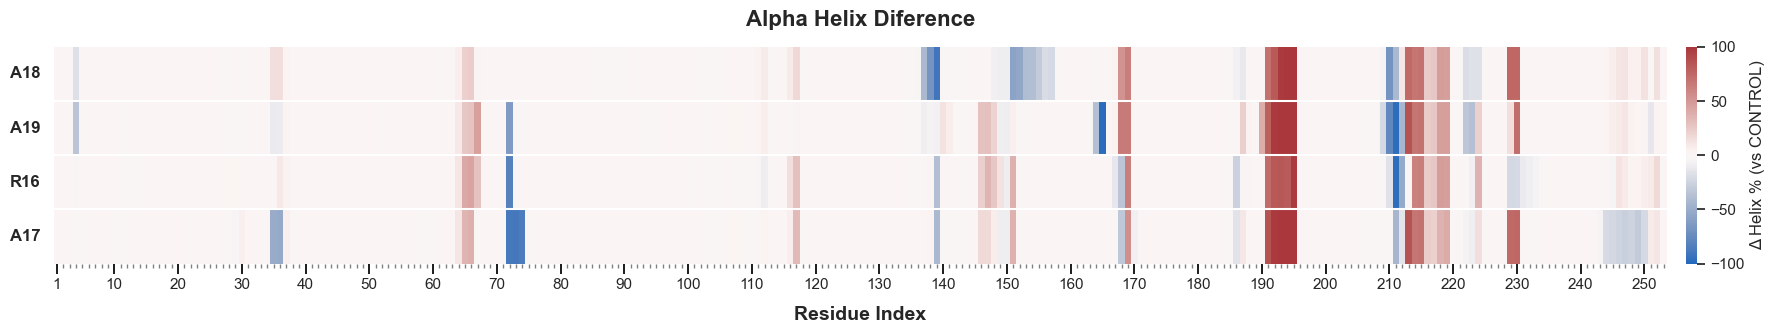

In [26]:
# Cell 13: Plotting Differential Alpha Helix Heatmap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

print("Generating Differential Alpha Helix Heatmap...")

# Prepare data: Residue as index, transposed so Mutants are rows
diff_heat_helix = df_diff.set_index('Residue')[dhelix_cols].T
diff_heat_helix.index = diff_heat_helix.index.str.replace('_dHelix_%', '')

# Setup figure
fig_diff_helix, ax_diff_helix = plt.subplots(figsize=(20, 3.5))

# Dynamically set color limit perfectly centered on 0
vmax_val = np.ceil(diff_heat_helix.abs().max().max() / 10) * 10
if vmax_val == 0: vmax_val = 10 

# Draw Diverging Heatmap (vlag: Blue = Loss, Red = Gain)
sns.heatmap(diff_heat_helix, cmap='vlag', vmin=-vmax_val, vmax=vmax_val, center=0, 
            ax=ax_diff_helix, cbar_kws={'label': 'Δ Helix % (vs CONTROL)', 'pad': 0.01})

# Horizontal Separators
for y in range(1, len(mutants)):
    ax_diff_helix.axhline(y=y, color='white', linewidth=1.5)

# --- INDEPENDENT TICK FORMATTING FIX ---
major_tick_interval = 10
final_residue = 310
major_tick_positions, major_tick_labels, minor_tick_positions = [], [], []

for i, res in enumerate(diff_heat_helix.columns):
    center_pos = i + 0.5
    minor_tick_positions.append(center_pos)
    if res == 1 or res % major_tick_interval == 0 or res == final_residue:
        major_tick_positions.append(center_pos)
        major_tick_labels.append(res)
# ---------------------------------------

# Apply Ticks
ax_diff_helix.set_xticks(major_tick_positions)
ax_diff_helix.set_xticklabels(major_tick_labels, rotation=0, fontsize=11)
ax_diff_helix.tick_params(axis='x', which='major', bottom=True, length=7, color='black')

ax_diff_helix.set_xticks(minor_tick_positions, minor=True)
ax_diff_helix.tick_params(axis='x', which='minor', bottom=True, length=3, color='gray')

ax_diff_helix.set_yticklabels(ax_diff_helix.get_yticklabels(), rotation=0, fontweight='bold', fontsize=12)

# Styling
ax_diff_helix.set_title("Alpha Helix Diference", fontsize=16, fontweight='bold', pad=15)
ax_diff_helix.set_xlabel("Residue Index", fontsize=14, fontweight='bold', labelpad=10)
ax_diff_helix.set_ylabel("")

plt.tight_layout()

# Save
fig_diff_helix.savefig(fn_diff_helix_png, dpi=600, bbox_inches='tight')
fig_diff_helix.savefig(fn_diff_helix_pdf, bbox_inches='tight')
print(f" -> Saved: {fn_diff_helix_png}")

Generating Differential Beta Sheet Heatmap...
 -> Saved: MAS2/DATA/SS_Differential_Beta_Heatmap.png


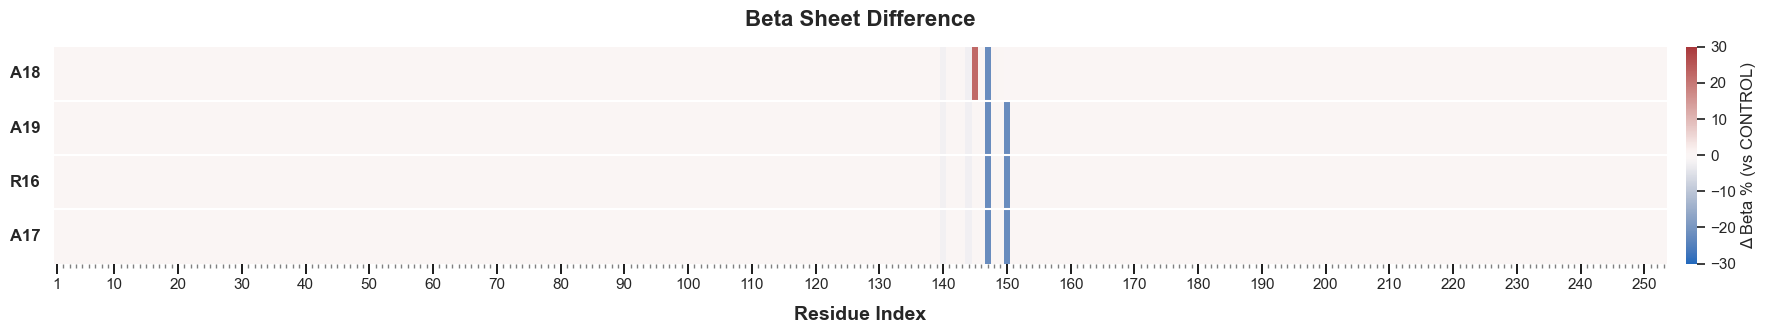

In [27]:
# Cell 14: Plotting Differential Beta Sheet Heatmap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

print("Generating Differential Beta Sheet Heatmap...")

# Prepare data: Residue as index, transposed so Mutants are rows
diff_heat_beta = df_diff.set_index('Residue')[dbeta_cols].T
diff_heat_beta.index = diff_heat_beta.index.str.replace('_dBeta_%', '')

# Setup figure
fig_diff_beta, ax_diff_beta = plt.subplots(figsize=(20, 3.5))

# Dynamically set color limit perfectly centered on 0 for the beta data
vmax_val_beta = np.ceil(diff_heat_beta.abs().max().max() / 10) * 10
if vmax_val_beta == 0: vmax_val_beta = 10 

# Draw Diverging Heatmap
sns.heatmap(diff_heat_beta, cmap='vlag', vmin=-vmax_val_beta, vmax=vmax_val_beta, center=0, 
            ax=ax_diff_beta, cbar_kws={'label': 'Δ Beta % (vs CONTROL)', 'pad': 0.01})

# Horizontal Separators
for y in range(1, len(mutants)):
    ax_diff_beta.axhline(y=y, color='white', linewidth=1.5)

# --- INDEPENDENT TICK FORMATTING FIX ---
major_tick_interval = 10
final_residue = 310
major_tick_positions, major_tick_labels, minor_tick_positions = [], [], []

for i, res in enumerate(diff_heat_beta.columns):
    center_pos = i + 0.5
    minor_tick_positions.append(center_pos)
    if res == 1 or res % major_tick_interval == 0 or res == final_residue:
        major_tick_positions.append(center_pos)
        major_tick_labels.append(res)
# ---------------------------------------

# Apply Ticks
ax_diff_beta.set_xticks(major_tick_positions)
ax_diff_beta.set_xticklabels(major_tick_labels, rotation=0, fontsize=11)
ax_diff_beta.tick_params(axis='x', which='major', bottom=True, length=7, color='black')

ax_diff_beta.set_xticks(minor_tick_positions, minor=True)
ax_diff_beta.tick_params(axis='x', which='minor', bottom=True, length=3, color='gray')

ax_diff_beta.set_yticklabels(ax_diff_beta.get_yticklabels(), rotation=0, fontweight='bold', fontsize=12)

# Styling
ax_diff_beta.set_title("Beta Sheet Difference", fontsize=16, fontweight='bold', pad=15)
ax_diff_beta.set_xlabel("Residue Index", fontsize=14, fontweight='bold', labelpad=10)
ax_diff_beta.set_ylabel("")

plt.tight_layout()

# Save
fig_diff_beta.savefig(fn_diff_beta_png, dpi=600, bbox_inches='tight')
fig_diff_beta.savefig(fn_diff_beta_pdf, bbox_inches='tight')
print(f" -> Saved: {fn_diff_beta_png}")

## Zoomed Per Domain Plots

Generating Differential Beta Sheet Heatmap (Zoomed)...
 -> Saved: MAS2/DATA/SS_Differential_Beta_Heatmap_Zoomed.png


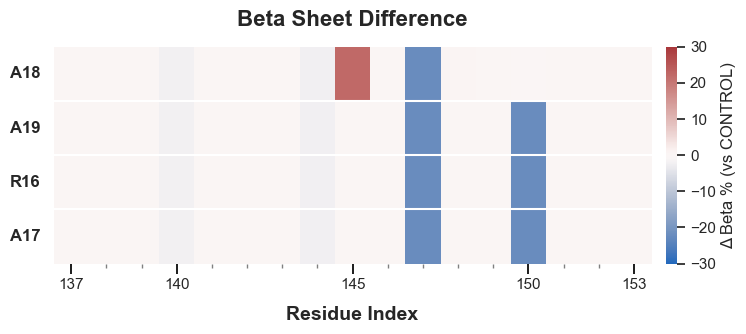

In [28]:
# Cell 15: Plotting Differential Beta Sheet Heatmap (Auto-Zoomed)
print("Generating Differential Beta Sheet Heatmap (Zoomed)...")

# Prepare data
diff_heat_beta = df_diff.set_index('Residue')[dbeta_cols].T
diff_heat_beta.index = diff_heat_beta.index.str.replace('_dBeta_%', '')

# ====================================================================
# --- AUTO-ZOOM LOGIC ---

# Minimum absolute change (%) for a residue to be considered active.
# Set at 1.0% because GPCR beta content is naturally sparse — anything
# below this is more likely simulation noise than a real structural event.
beta_threshold = 1.0

active_residues = diff_heat_beta.columns[
    (diff_heat_beta.abs() >= beta_threshold).any()
].tolist()

buffer = 3
keep_residues = set()
for res in active_residues:
    for r in range(int(res) - buffer, int(res) + buffer + 1):
        if r in diff_heat_beta.columns:
            keep_residues.add(r)

zoomed_residues = sorted(list(keep_residues))

if not zoomed_residues:
    print("No significant Beta Sheet differences found. Showing full range.")
    zoomed_residues = diff_heat_beta.columns

diff_heat_beta_zoomed = diff_heat_beta[zoomed_residues]
# ====================================================================

fig_width = min(20, max(8, len(zoomed_residues) * 0.25))
fig_diff_beta, ax_diff_beta = plt.subplots(figsize=(fig_width, 3.5))

vmax_val_beta = np.ceil(diff_heat_beta_zoomed.abs().max().max() / 10) * 10
if vmax_val_beta == 0: vmax_val_beta = 10

sns.heatmap(diff_heat_beta_zoomed, cmap='vlag', vmin=-vmax_val_beta, vmax=vmax_val_beta, center=0,
            ax=ax_diff_beta, cbar_kws={'label': 'Δ Beta % (vs CONTROL)', 'pad': 0.02})

for y in range(1, len(mutants)):
    ax_diff_beta.axhline(y=y, color='white', linewidth=1.5)

# --- Dynamic Tick Formatting ---
major_tick_positions, major_tick_labels, minor_tick_positions = [], [], []

for i, res in enumerate(diff_heat_beta_zoomed.columns):
    center_pos = i + 0.5
    minor_tick_positions.append(center_pos)

    if i == 0 or i == len(diff_heat_beta_zoomed.columns) - 1 or res % 5 == 0:
        major_tick_positions.append(center_pos)
        major_tick_labels.append(int(res))

    if i > 0 and res - diff_heat_beta_zoomed.columns[i - 1] > 1:
        ax_diff_beta.axvline(x=i, color='black', linewidth=2.0, linestyle='--')

ax_diff_beta.set_xticks(major_tick_positions)
ax_diff_beta.set_xticklabels(major_tick_labels, rotation=0, fontsize=11)
ax_diff_beta.tick_params(axis='x', which='major', bottom=True, length=7, color='black')

ax_diff_beta.set_xticks(minor_tick_positions, minor=True)
ax_diff_beta.tick_params(axis='x', which='minor', bottom=True, length=3, color='gray')

ax_diff_beta.set_yticklabels(ax_diff_beta.get_yticklabels(), rotation=0, fontweight='bold', fontsize=12)

ax_diff_beta.set_title("Beta Sheet Difference", fontsize=16, fontweight='bold', pad=15)
ax_diff_beta.set_xlabel("Residue Index", fontsize=14, fontweight='bold', labelpad=10)
ax_diff_beta.set_ylabel("")

plt.tight_layout()

fig_diff_beta.savefig(fn_diff_beta_zoom_png, dpi=600, bbox_inches='tight')
fig_diff_beta.savefig(fn_diff_beta_zoom_pdf, bbox_inches='tight')
print(f" -> Saved: {fn_diff_beta_zoom_png}")

Generating Beta Sheet Content Heatmap (Zoomed to active regions)...
  Showing 17 residues (from 137 to 153)
 -> Saved: MAS2/DATA/SS_BetaSheet_Heatmap_Zoomed.png


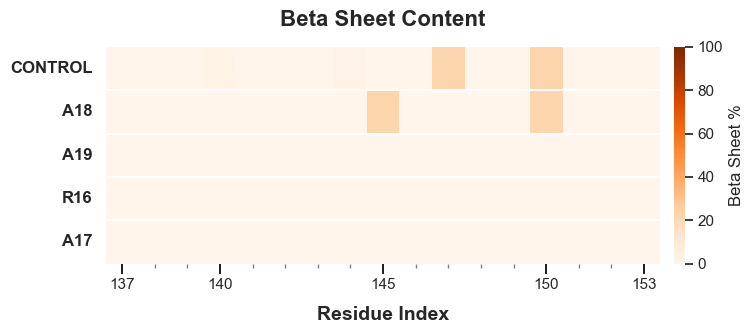

In [29]:
# Cell 16: Beta Sheet Content Heatmap (Auto-Zoomed to Active Regions)

print("Generating Beta Sheet Content Heatmap (Zoomed to active regions)...")

# --- AUTO-ZOOM LOGIC ---
# Threshold: keep residues where ANY system shows >= 2% beta content
beta_threshold = 2.0
active_residues_beta = heat_beta.columns[
    (heat_beta >= beta_threshold).any()
].tolist()

# Add a buffer of +/- 3 residues around each active site for context
buffer = 3
keep_residues_beta = set()
for res in active_residues_beta:
    for r in range(int(res) - buffer, int(res) + buffer + 1):
        if r in heat_beta.columns:
            keep_residues_beta.add(r)

zoomed_residues_beta = sorted(list(keep_residues_beta))

# Fallback: if nothing passes the threshold, show full range
if not zoomed_residues_beta:
    print("  WARNING: No residues exceeded threshold. Showing full range.")
    zoomed_residues_beta = heat_beta.columns.tolist()

# Slice to zoomed region
heat_beta_zoomed = heat_beta[zoomed_residues_beta]

print(f"  Showing {len(zoomed_residues_beta)} residues "
      f"(from {zoomed_residues_beta[0]} to {zoomed_residues_beta[-1]})")

# --- FIGURE SETUP ---
fig_width = min(20, max(8, len(zoomed_residues_beta) * 0.25))
fig_beta_zoom, ax_beta_zoom = plt.subplots(figsize=(fig_width, 3.5))

# --- HEATMAP ---
sns.heatmap(
    heat_beta_zoomed,
    cmap='Oranges',
    vmin=0, vmax=100,
    ax=ax_beta_zoom,
    cbar_kws={'label': 'Beta Sheet %', 'pad': 0.02}
)

# --- ROW SEPARATORS ---
for y in range(1, len(sys_cols)):
    ax_beta_zoom.axhline(y=y, color='white', linewidth=1.5)

# --- TICK FORMATTING ---
major_tick_positions_bz, major_tick_labels_bz, minor_tick_positions_bz = [], [], []

for i, res in enumerate(heat_beta_zoomed.columns):
    center_pos = i + 0.5
    minor_tick_positions_bz.append(center_pos)

    if i == 0 or i == len(heat_beta_zoomed.columns) - 1 or int(res) % 5 == 0:
        major_tick_positions_bz.append(center_pos)
        major_tick_labels_bz.append(int(res))

    # Dashed vertical line to mark sequence gaps (non-contiguous regions)
    if i > 0 and res - heat_beta_zoomed.columns[i - 1] > 1:
        ax_beta_zoom.axvline(x=i, color='black', linewidth=2.0, linestyle='--')

ax_beta_zoom.set_xticks(major_tick_positions_bz)
ax_beta_zoom.set_xticklabels(major_tick_labels_bz, rotation=0, fontsize=11)
ax_beta_zoom.tick_params(axis='x', which='major', bottom=True, length=7, color='black')

ax_beta_zoom.set_xticks(minor_tick_positions_bz, minor=True)
ax_beta_zoom.tick_params(axis='x', which='minor', bottom=True, length=3, color='gray')

ax_beta_zoom.set_yticklabels(ax_beta_zoom.get_yticklabels(), rotation=0, fontweight='bold', fontsize=12)

# --- STYLING ---
ax_beta_zoom.set_title("Beta Sheet Content",
                        fontsize=16, fontweight='bold', pad=15)
ax_beta_zoom.set_xlabel("Residue Index", fontsize=14, fontweight='bold', labelpad=10)
ax_beta_zoom.set_ylabel("")

plt.tight_layout()

# --- SAVE ---
fig_beta_zoom.savefig(fn_beta_zoom_png, dpi=600, bbox_inches='tight')
fig_beta_zoom.savefig(fn_beta_zoom_pdf, bbox_inches='tight')
print(f" -> Saved: {fn_beta_zoom_png}")

Generating per-domain Alpha Helix Content Heatmaps...

  Plotting TM1: residues 3–32 (30 residues)


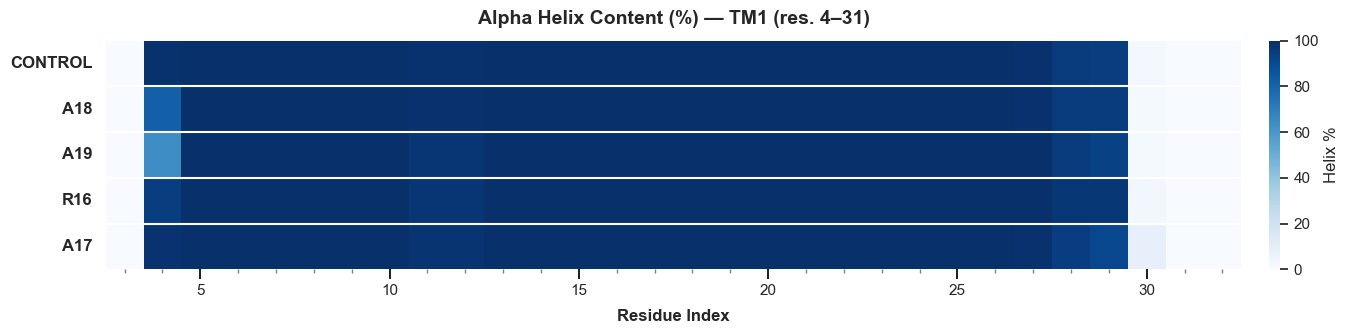

  Plotting TM2: residues 34–67 (34 residues)


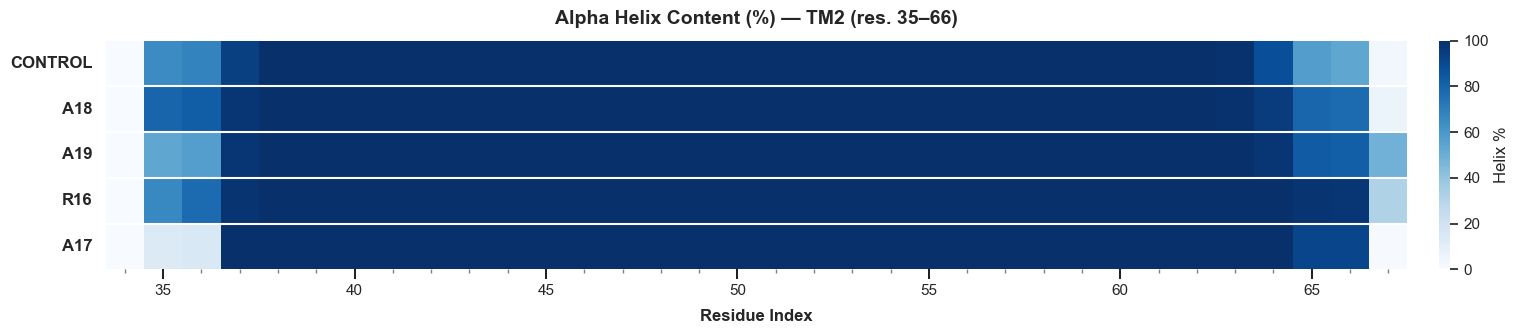

  Plotting TM3: residues 71–106 (36 residues)


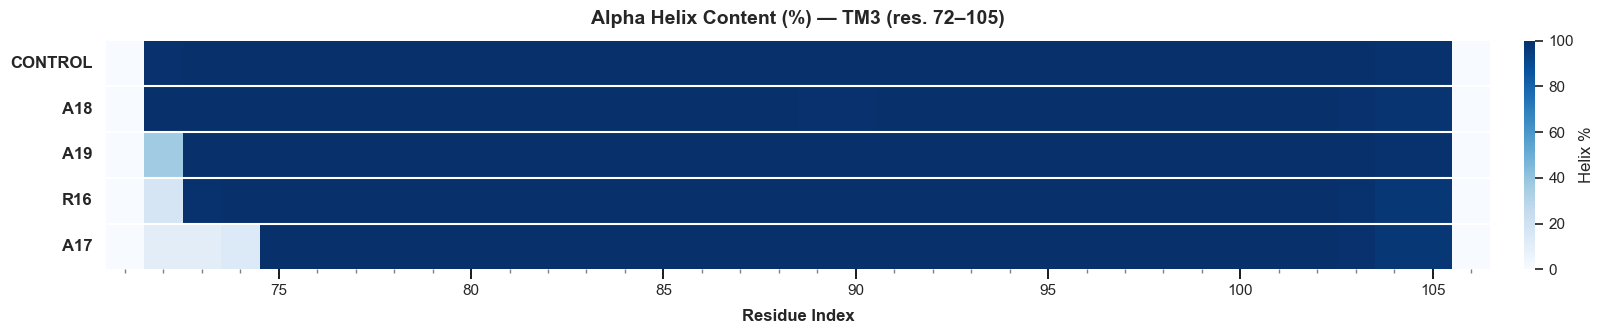

  Plotting TM4: residues 117–140 (24 residues)


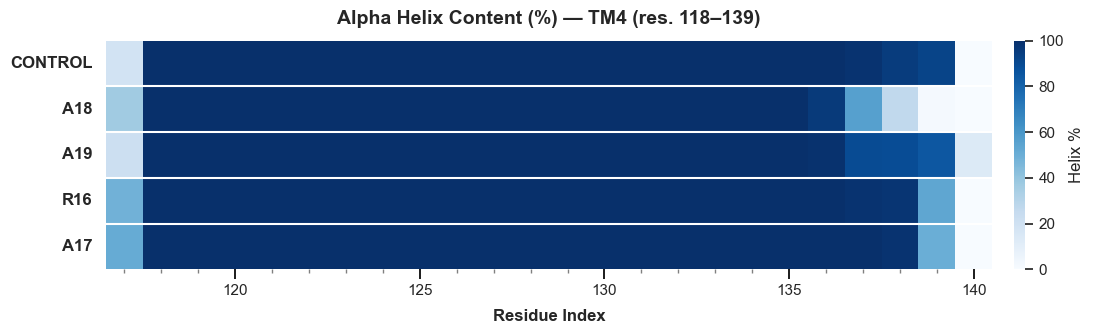

  Plotting TM5: residues 150–188 (39 residues)


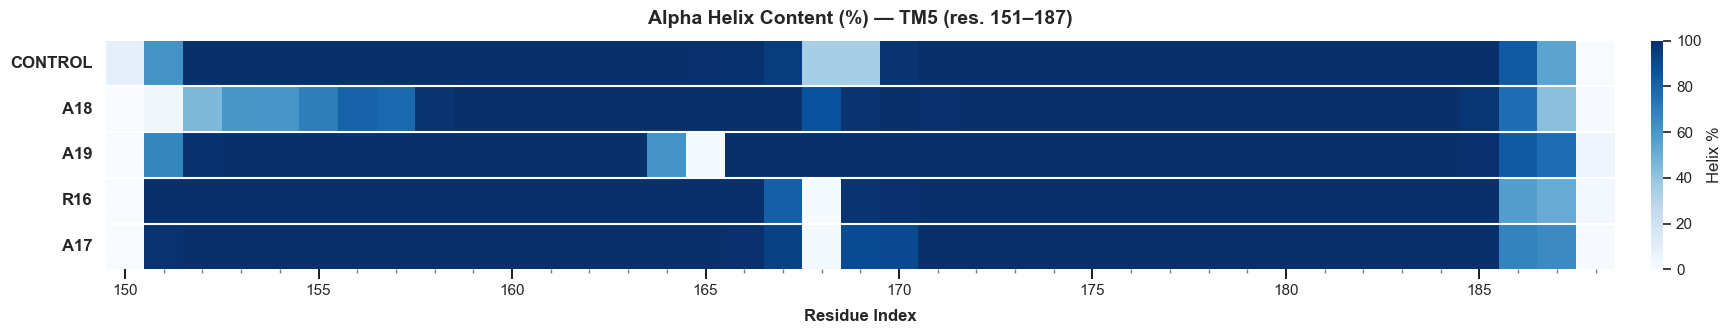

  Plotting TM6: residues 195–214 (20 residues)


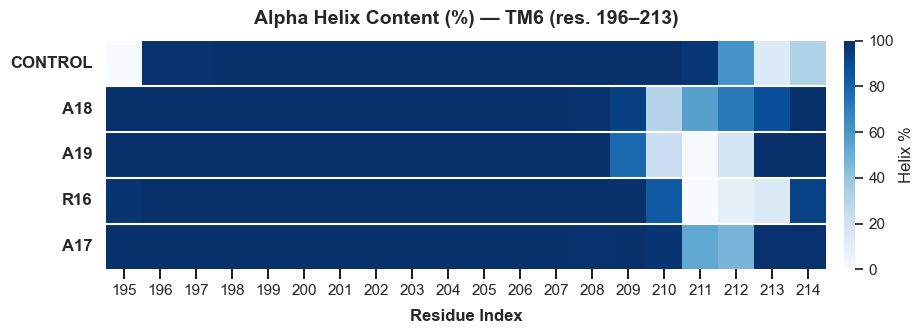

  Plotting TM7: residues 228–252 (25 residues)


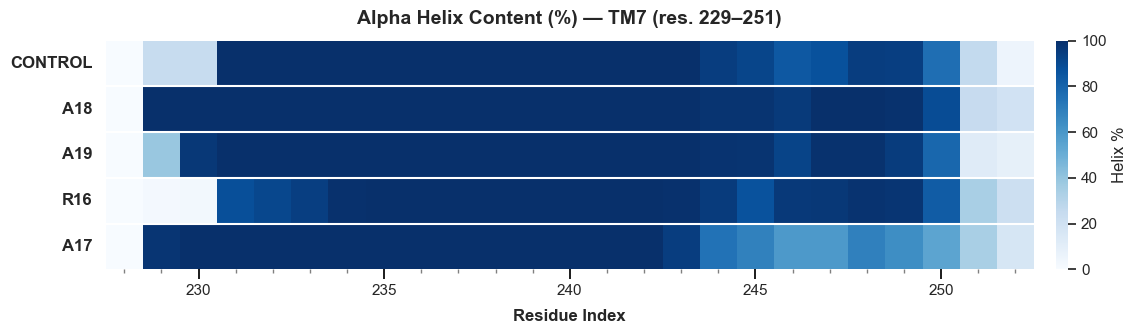


All per-domain helix plots completed.


In [32]:
# Cell 17: Alpha Helix Content Heatmaps — Zoomed per Helix Domain
import os
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating per-domain Alpha Helix Content Heatmaps...\n")

# --- 1. DYNAMIC DOMAIN DISCOVERY ---
# Only attempt to plot domains that are actually defined for the current systemid
# and have the word 'TM' or 'Helix' in their name.
active_helix_domains = [d for d in domain_ranges.keys() if ('TM' in d or 'Helix' in d)]

for domain_name in active_helix_domains:

    # --- 2. SLICE TO DOMAIN RESIDUES ---
    start_res, end_res = domain_ranges[domain_name]
    domain_residues = [r for r in heat_helix.columns if (start_res - 1) <= r <= (end_res + 1)]

    if not domain_residues:
        print(f"  WARNING: No residues found in data for {domain_name} ({start_res}-{end_res}). Skipping.")
        continue

    heat_domain = heat_helix[domain_residues]
    n_res = len(domain_residues)

    print(f"  Plotting {domain_name}: residues {domain_residues[0]}–{domain_residues[-1]} ({n_res} residues)")

    # --- 3. FIGURE SETUP ---
    cell_width = 0.5 
    fig_dom, ax_dom = plt.subplots(figsize=(n_res * cell_width, 3.5))

    sns.heatmap(
        heat_domain,
        cmap='Blues',
        vmin=0, vmax=100,
        ax=ax_dom,
        cbar_kws={'label': 'Helix %', 'pad': 0.02}
    )

    # --- 4. ROW SEPARATORS ---
    for y in range(1, len(sys_cols)):
        ax_dom.axhline(y=y, color='white', linewidth=1.5)

    # --- 5. TICK FORMATTING ---
    label_step = 1 if n_res <= 20 else 5
    major_tick_pos, major_tick_lab, minor_tick_pos = [], [], []

    for i, res in enumerate(heat_domain.columns):
        center_pos = i + 0.5
        minor_tick_pos.append(center_pos)

        if int(res) % label_step == 0:
            major_tick_pos.append(center_pos)
            major_tick_lab.append(int(res))

    ax_dom.set_xticks(major_tick_pos)
    ax_dom.set_xticklabels(major_tick_lab, rotation=0, fontsize=11)
    ax_dom.tick_params(axis='x', which='major', bottom=True, length=7, color='black')

    ax_dom.set_xticks(minor_tick_pos, minor=True)
    ax_dom.tick_params(axis='x', which='minor', bottom=True, length=3, color='gray')

    ax_dom.set_yticklabels(ax_dom.get_yticklabels(), rotation=0, fontweight='bold', fontsize=12)

    # --- 6. STYLING ---
    ax_dom.set_title(f"Alpha Helix Content (%) — {domain_name} (res. {start_res}–{end_res})",
                     fontsize=14, fontweight='bold', pad=12)
    ax_dom.set_xlabel("Residue Index", fontsize=12, fontweight='bold', labelpad=8)
    ax_dom.set_ylabel("")

    plt.tight_layout()
    plt.show()

    # --- 7. SAVE ---
    fig_dom.savefig(fn_helix_domain_png.get(domain_name, os.path.join(general_folder_path, f"SS_Helix_{domain_name}_Zoomed.png")), dpi=600, bbox_inches='tight')
    fig_dom.savefig(fn_helix_domain_pdf.get(domain_name, os.path.join(general_folder_path, f"SS_Helix_{domain_name}_Zoomed.pdf")), bbox_inches='tight')
    
    plt.close(fig_dom)

print("\nAll per-domain helix plots completed.")

Generating Composite Grid...

 -> Saved: MAS2/DATA/SS_Helix_Composite.png | .pdf


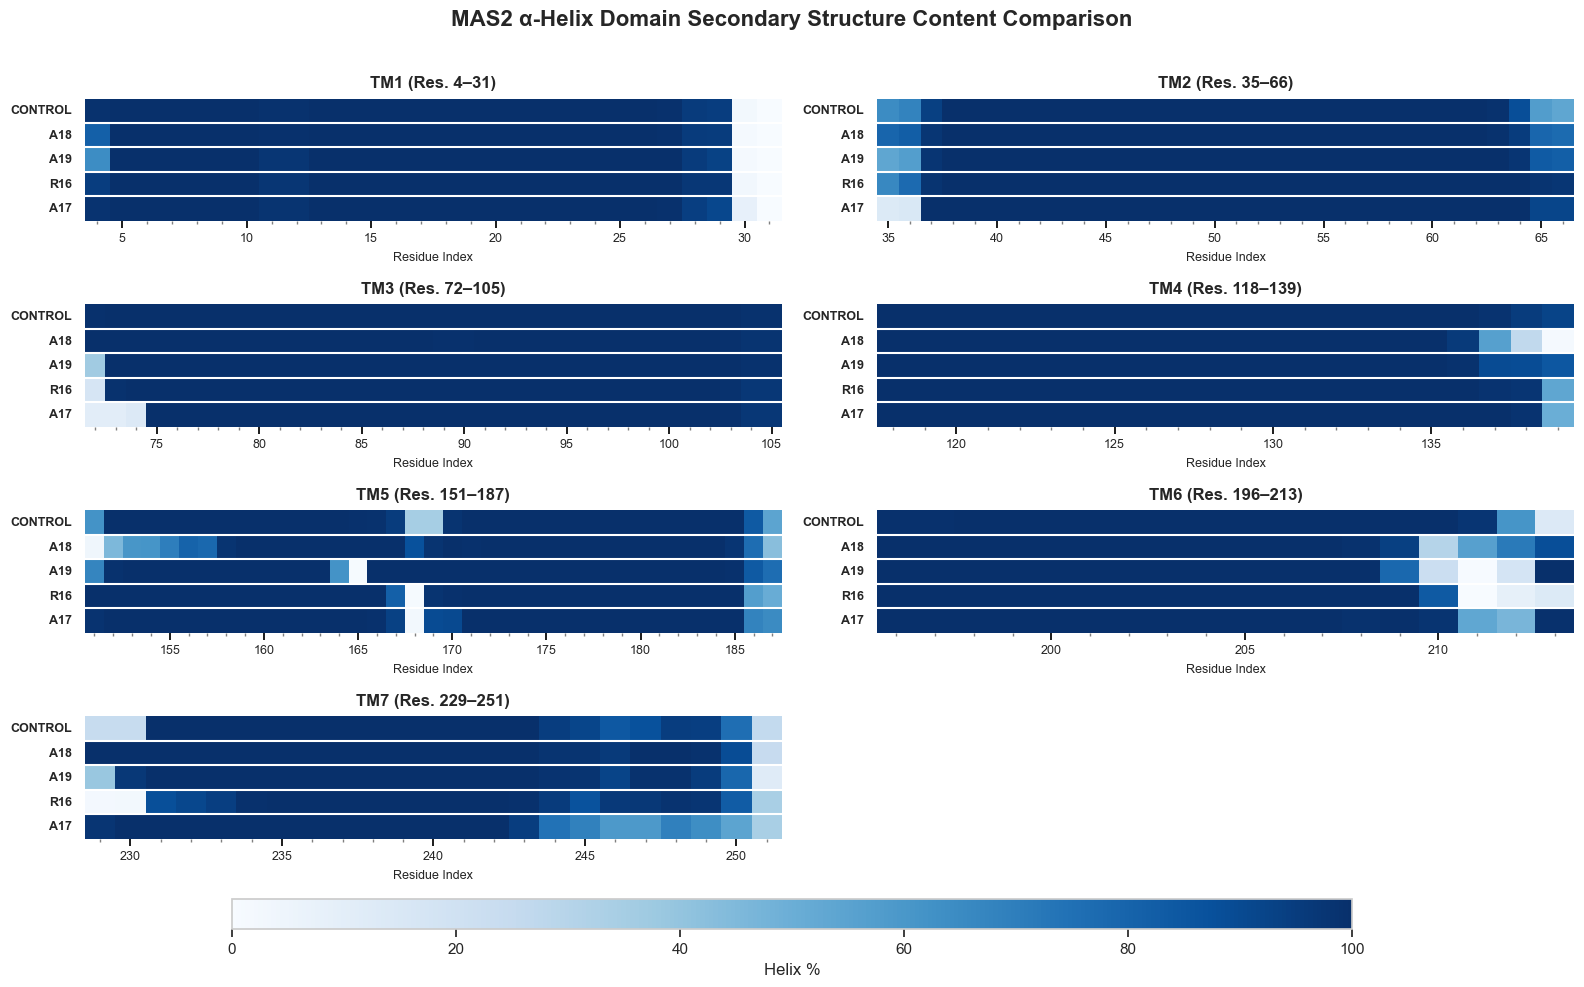

In [33]:
# Cell 18: Composite Alpha Helix Content Heatmap (Dynamic Grid)
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import math

print("Generating Composite Grid...\n")

# --- CONFIGURATION ---
fig_width   = 16    
cbar_height = 0.03  
cbar_pad    = 0.06  

# Ensure we only work with existing domains
active_helix_domains = [d for d in domain_ranges.keys() if ('TM' in d or 'Helix' in d)]
n_domains = len(active_helix_domains)

# --- DYNAMIC LAYOUT SETUP ---
# Calculate rows needed for 2 columns
n_cols = 2
n_rows = math.ceil(n_domains / n_cols)
fig_height = max(6, n_rows * 2.5) # Scale height based on number of rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height))
fig.suptitle(f'{systemid} α-Helix Domain Secondary Structure Content Comparison',
             fontsize=16, fontweight='bold')
axes_flat = axes.flatten()

for idx, ax in enumerate(axes_flat):
    # Hide axes that exceed our domain count (e.g., the 8th slot when plotting 7 domains)
    if idx >= n_domains:
        ax.set_visible(False)
        continue

    domain_name = active_helix_domains[idx]

    start_res, end_res = domain_ranges[domain_name]
    domain_residues = [r for r in heat_helix.columns if start_res <= r <= end_res]
    
    if not domain_residues:
        ax.set_visible(False)
        continue
        
    heat_domain = heat_helix[domain_residues]

    # --- HEATMAP ---
    sns.heatmap(
        heat_domain,
        cmap='Blues',
        vmin=0, vmax=100,
        ax=ax,
        cbar=False
    )

    for y in range(1, len(sys_cols)):
        ax.axhline(y=y, color='white', linewidth=1.5)

    # --- TICK FORMATTING ---
    major_tick_pos, major_tick_lab, minor_tick_pos = [], [], []

    for i, res in enumerate(heat_domain.columns):
        center_pos = i + 0.5
        minor_tick_pos.append(center_pos)
        if int(res) % 5 == 0:
            major_tick_pos.append(center_pos)
            major_tick_lab.append(int(res))

    ax.set_xticks(major_tick_pos)
    ax.set_xticklabels(major_tick_lab, rotation=0, fontsize=9)
    ax.tick_params(axis='x', which='major', bottom=True, length=5, color='black')

    ax.set_xticks(minor_tick_pos, minor=True)
    ax.tick_params(axis='x', which='minor', bottom=True, length=2, color='gray')

    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9, fontweight='bold')
    ax.set_xlabel("Residue Index", fontsize=9, labelpad=5)
    ax.set_ylabel("")

    ax.set_title(f"{domain_name} (Res. {start_res}–{end_res})", fontsize=12, fontweight='bold', pad=8)

# --- SHARED COLORBAR AT BOTTOM ---
fig.tight_layout(rect=[0, cbar_pad + cbar_height, 1, 0.97])

sm = cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(vmin=0, vmax=100))
sm.set_array([])

cbar_ax = fig.add_axes([0.15, cbar_pad, 0.70, cbar_height])
fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', label='Helix %')

# --- SAVE & SHOW ---
fig.savefig(fn_composite_helix_png, dpi=600, bbox_inches='tight')
fig.savefig(fn_composite_helix_pdf, bbox_inches='tight')
print(f" -> Saved: {fn_composite_helix_png} | .pdf")
plt.show()

# Intracelular Cavity Comparison: SASA

In [34]:
# Cell 2: SASA File Discovery, Helpers, and Output Registry
general_folder_path = Path(f"{systemid}/DATA")

system_colors = {
    "CONTROL": "black",
    "A18": "royalblue",
    "A19": "crimson",
    "R16": "forestgreen",
    "A17": "orange"
}

# --- Centralized Plotting Helper ---
def save_and_show(fig, base_path):
    """Saves plots as high-res PNG and PDF, then displays them inline."""
    png_path = base_path.with_suffix('.png')
    pdf_path = base_path.with_suffix('.pdf')
    fig.savefig(png_path, dpi=1200, bbox_inches='tight')
    fig.savefig(pdf_path, bbox_inches='tight')
    print(f" -> Saved: {png_path.name}")
    plt.show()

# --- File Discovery ---
sasa_files = {}
print(f"Scanning '{general_folder_path}' for SASA files...\n")

for system in system_colors.keys():
    # Robust path discovery
    system_dir = general_folder_path / system
    if system_dir.exists():
        found_files = list(system_dir.rglob("*[iI]ntracellular_[pP]ocket_[sS][aA][sS][aA]*.csv"))
        if found_files:
            sasa_files[system] = found_files[0]
            print(f" [Found] {system}: '{found_files[0].name}'")
        else:
            print(f" [Missing] {system}: No SASA file found.")
    else:
        print(f" [Missing] {system}: Directory not found.")

# ── Global Output Registry ────────────────────────────────────────────────────

# 1. Data Tables
fn_sasa_table_csv = general_folder_path / "SASA_Smoothed_Data_Master.csv"

# 2. Comparison Line Plot
out_base_sasa_comp = general_folder_path / "SASA_System_Comparison"

# 3. Global Boxplot
out_base_sasa_global_box = general_folder_path / "SASA_Global_Boxplot"

# 4. Per-System Dictionaries (Base paths for the helper)
out_base_sasa_composite = {sys: general_folder_path / f"SASA_Composite_{sys}" for sys in system_colors.keys()}
out_base_sasa_hist_iso  = {sys: general_folder_path / f"SASA_Isolated_Hist_{sys}" for sys in system_colors.keys()}
out_base_sasa_box_iso   = {sys: general_folder_path / f"SASA_Isolated_Box_{sys}" for sys in system_colors.keys()}

# 5. Composite Grids (4x1 and 2x2)
out_base_sasa_grid_box = general_folder_path / "SASA_Grid_Boxplots"
out_base_sasa_grid_hist = general_folder_path / "SASA_Grid_Histograms"

print("\nOutput registry configured.")

Scanning 'MAS2/DATA' for SASA files...

 [Found] CONTROL: 'CONTROL_Intracellular_Pocket_SASA.csv'
 [Found] A18: 'A18_Intracellular_Pocket_SASA.csv'
 [Found] A19: 'A19_Intracellular_Pocket_SASA.csv'
 [Found] R16: 'R16_Intracellular_Pocket_SASA.csv'
 [Found] A17: 'A17_Intracellular_Pocket_SASA.csv'

Output registry configured.


Aggregating time-aligned SASA data and generating comparison plot...

 -> Master Data Table saved: SASA_Smoothed_Data_Master.csv
 -> Saved: SASA_System_Comparison.png


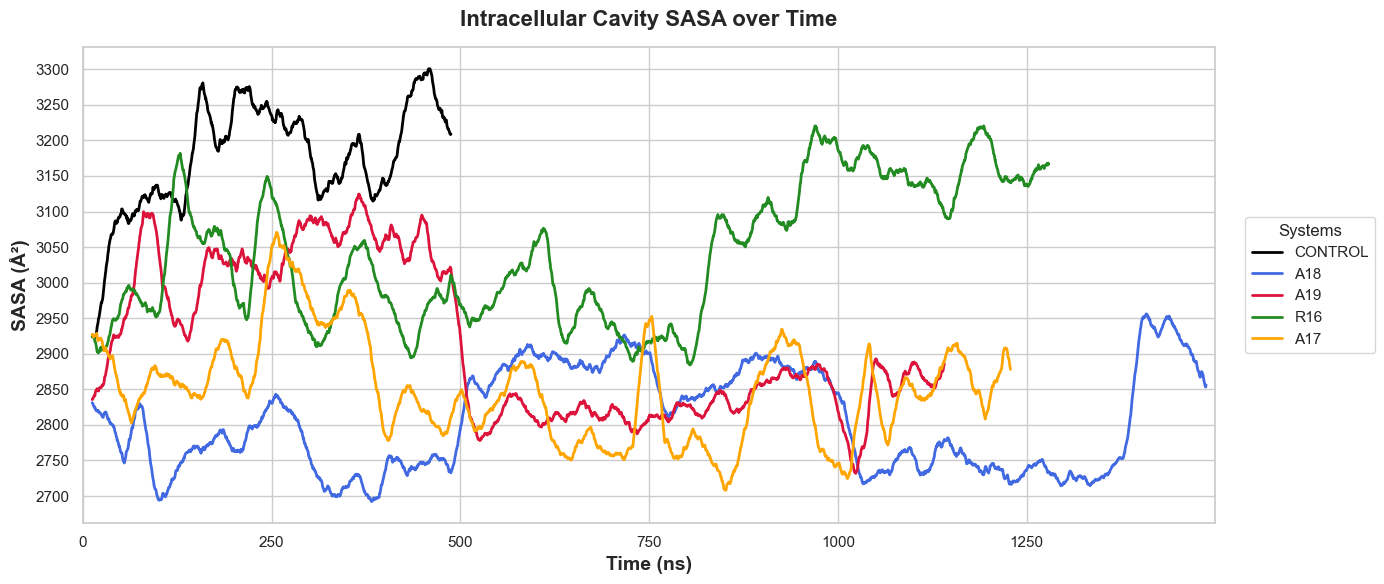

In [36]:
# Cell 3: Time-Aligned Data Aggregation and Smoothing Comparison

fig_sasa, ax_sasa = plt.subplots(figsize=(14, 6))
print("Aggregating time-aligned SASA data and generating comparison plot...")

systems_to_show = ["CONTROL", "A18", "A19", "R16", "A17"] 
window_size = 50 
max_x_val = 0    

sasa_data_dict = {} 

for system, filepath in sasa_files.items():
    df = pd.read_csv(filepath)
    
    # 1. Robust Column Targeting: Prioritize 'time' strictly over 'frame'
    time_col = next((col for col in df.columns if 'time' in col.lower()), None)
    y_col = next((col for col in df.columns if 'sasa' in col.lower() or 'area' in col.lower()), None)
    
    if time_col and y_col:
        # Set Time as the DataFrame index to force perfect chronological alignment
        df = df.set_index(time_col)
        
        smoothed_sasa = df[y_col].rolling(window=window_size, center=True).mean()
        sasa_data_dict[system] = smoothed_sasa
        
        if system in systems_to_show:
            # Plot directly using the index (Time) as X
            ax_sasa.plot(smoothed_sasa.index, smoothed_sasa.values, 
                         label=system, color=system_colors[system], linewidth=2.0)
            
            current_max = smoothed_sasa.index.max()
            if current_max > max_x_val: max_x_val = current_max

# 2. Create Master DataFrame (Safe merge via Time Index)
df_sasa_master = pd.DataFrame(sasa_data_dict).reset_index().rename(columns={'index': 'Time_ns'})
df_sasa_master.to_csv(fn_sasa_table_csv, index=False)
print(f"\n -> Master Data Table saved: {fn_sasa_table_csv.name}")

# 3. Axis Formatting
ax_sasa.xaxis.set_major_locator(ticker.MultipleLocator(250))
ax_sasa.xaxis.set_minor_locator(ticker.MultipleLocator(50))
ax_sasa.yaxis.set_major_locator(ticker.MultipleLocator(50))
ax_sasa.yaxis.set_minor_locator(ticker.MultipleLocator(25))

ax_sasa.tick_params(axis='both', which='major', length=6, color='black')
ax_sasa.tick_params(axis='both', which='minor', length=4, color='gray')

ax_sasa.set_title("Intracellular Cavity SASA over Time", fontsize=16, fontweight='bold', pad=15)
ax_sasa.set_xlabel("Time (ns)", fontsize=14, fontweight='bold')
ax_sasa.set_ylabel("SASA (Å²)", fontsize=14, fontweight='bold')

ax_sasa.set_xlim(0, max_x_val if max_x_val > 0 else 5000)
ax_sasa.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True, title="Systems")
plt.tight_layout()

# Export & Show
save_and_show(fig_sasa, out_base_sasa_comp)

Generating Global and Isolated SASA Distributions...



/tmp/ipykernel_6626/3330821414.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x='System', y='SASA', palette=system_colors, ax=ax_comp)


 -> Saved: SASA_Global_Boxplot.png


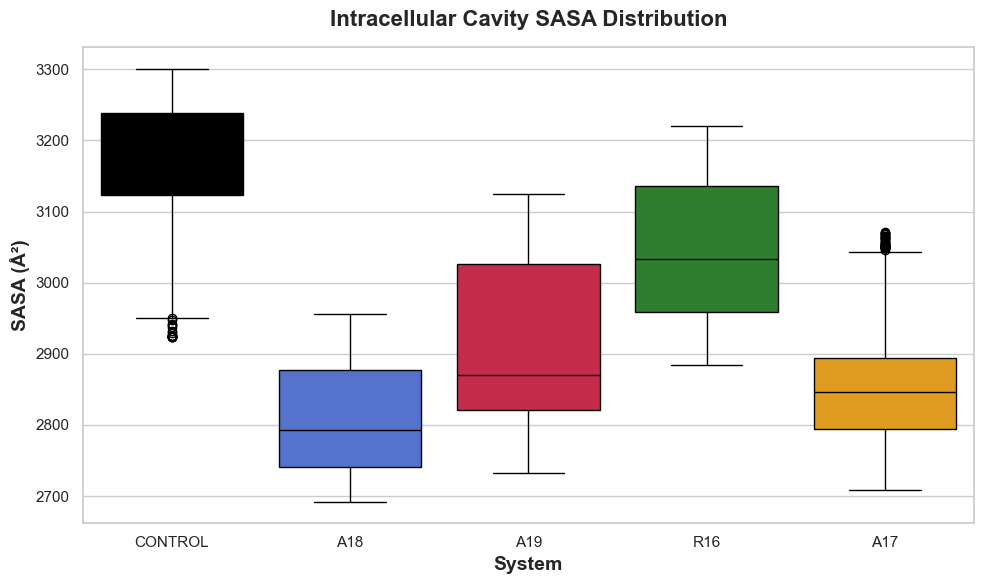

 -> Saved: SASA_Composite_CONTROL.png


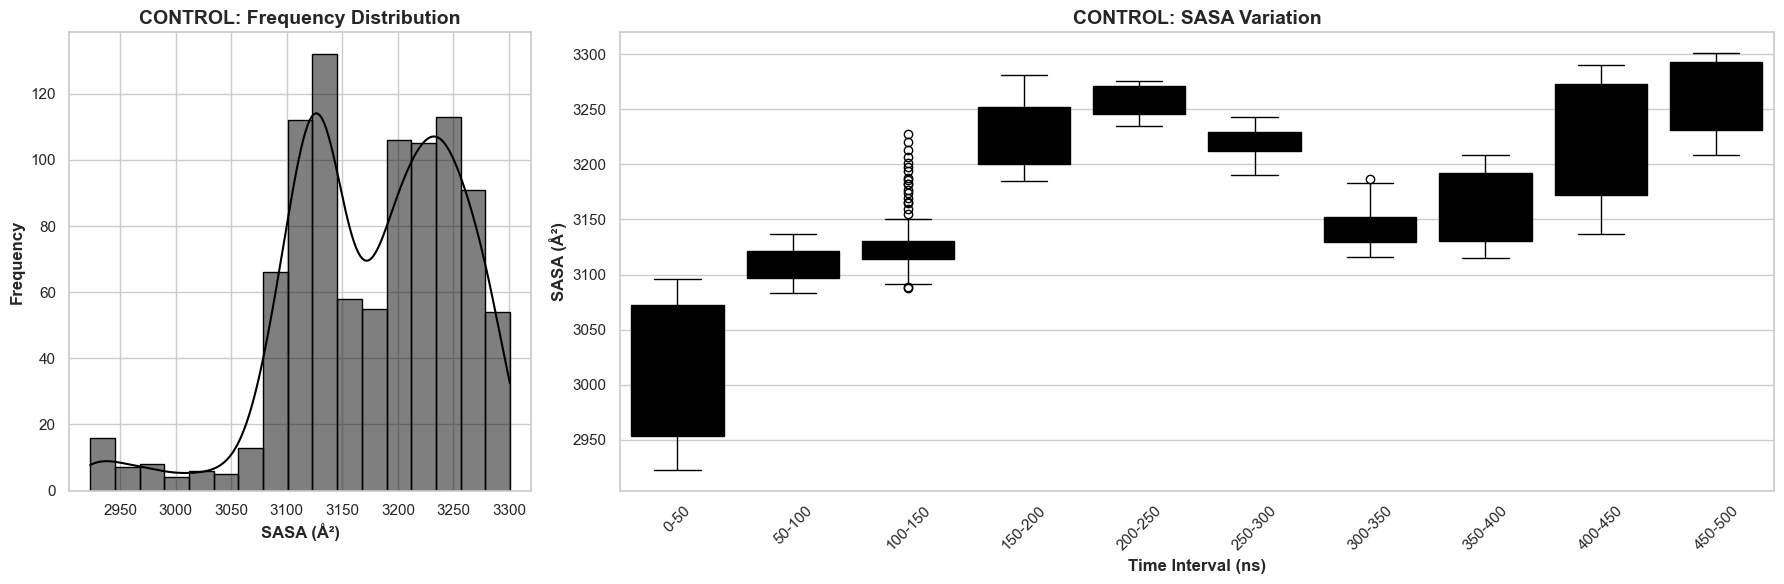

 -> Saved: SASA_Isolated_Hist_CONTROL.png


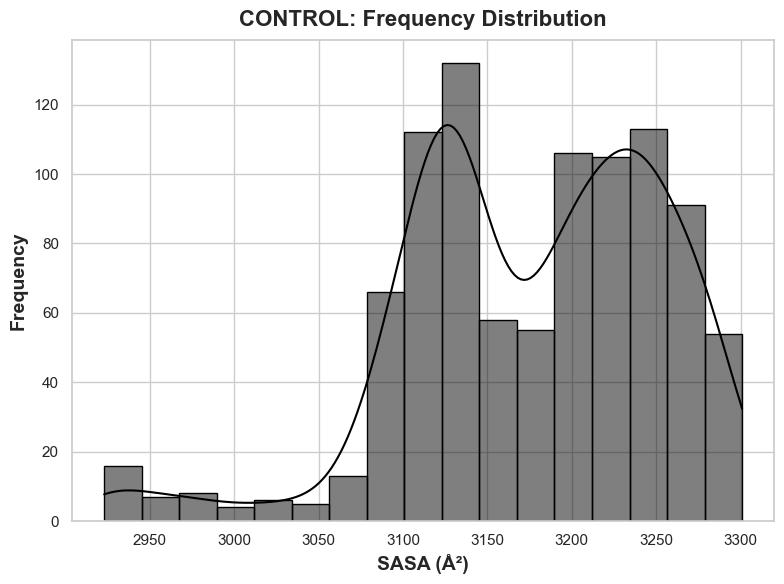

 -> Saved: SASA_Isolated_Box_CONTROL.png


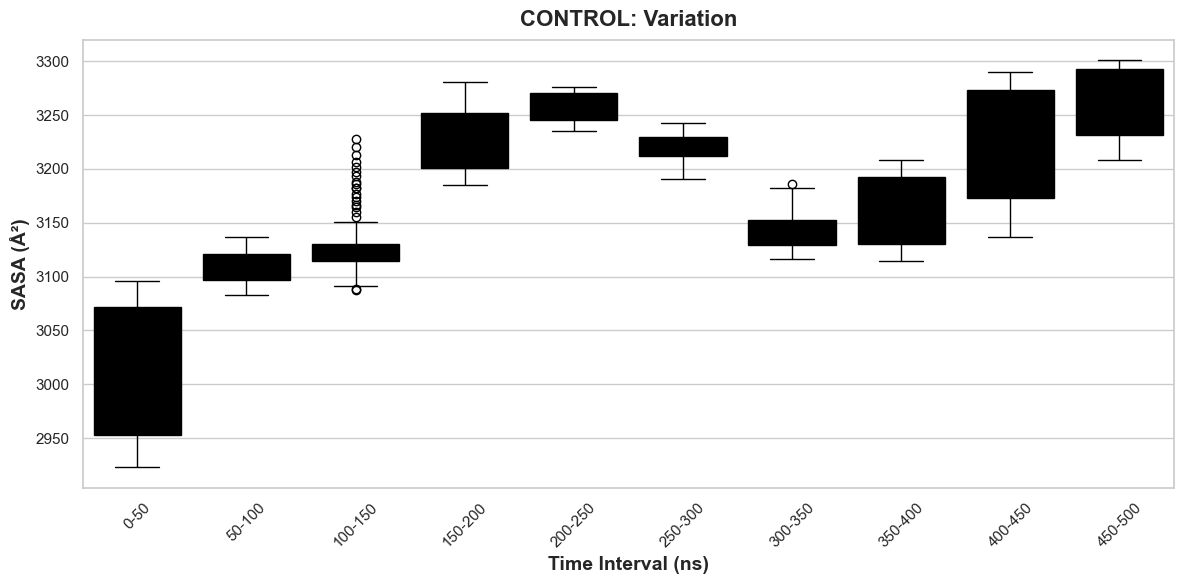

 -> Saved: SASA_Composite_A18.png


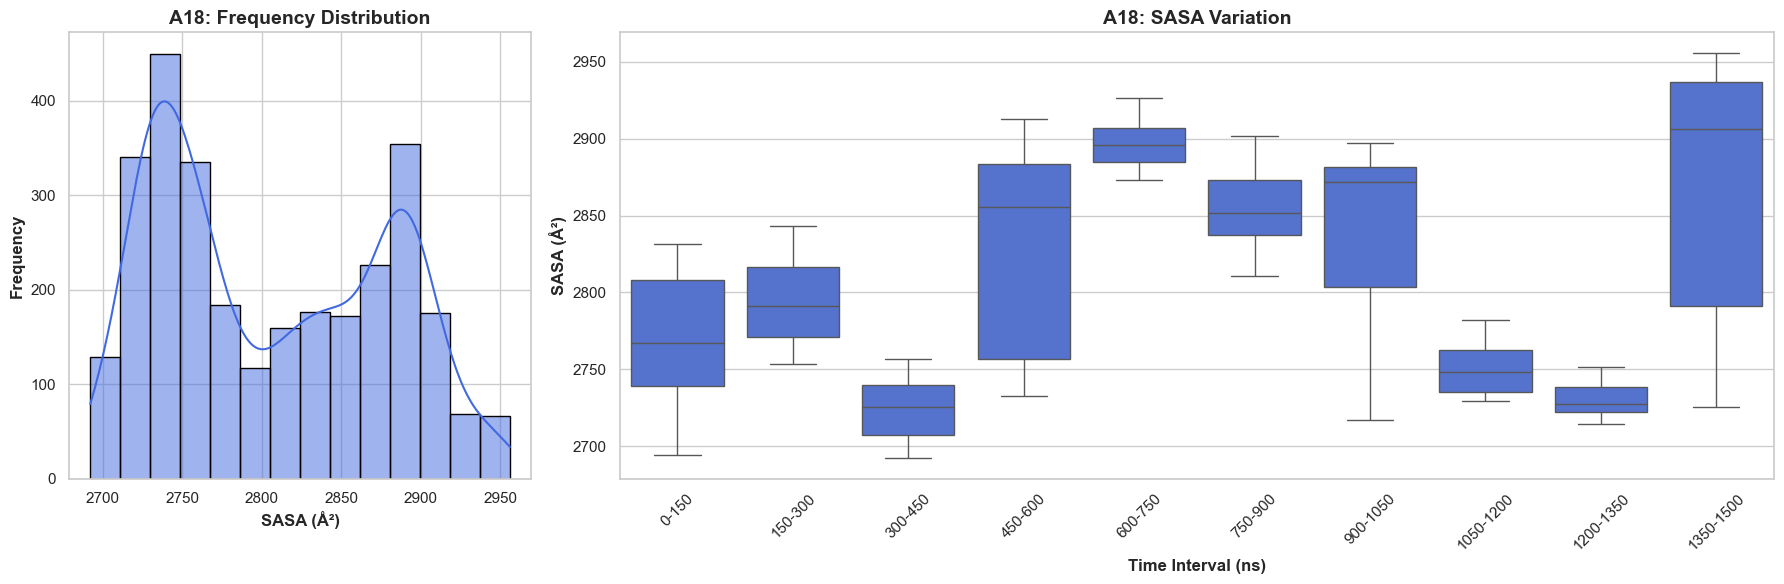

 -> Saved: SASA_Isolated_Hist_A18.png


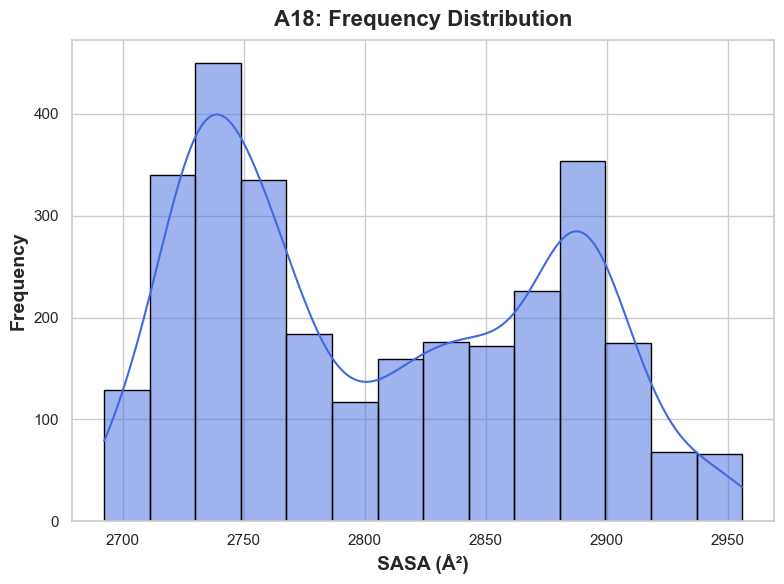

 -> Saved: SASA_Isolated_Box_A18.png


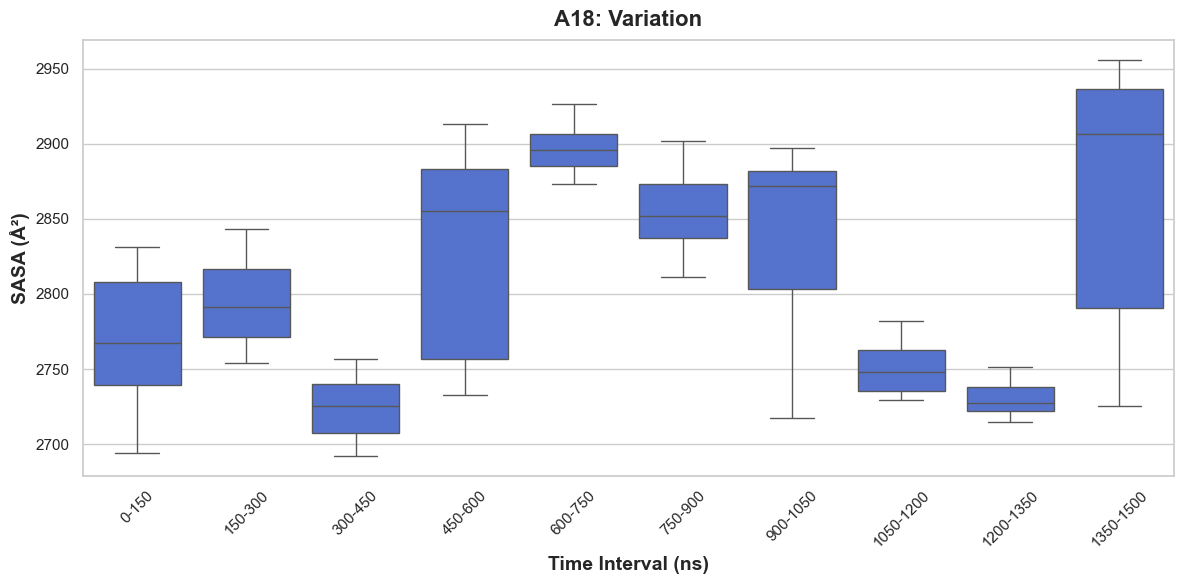

 -> Saved: SASA_Composite_A19.png


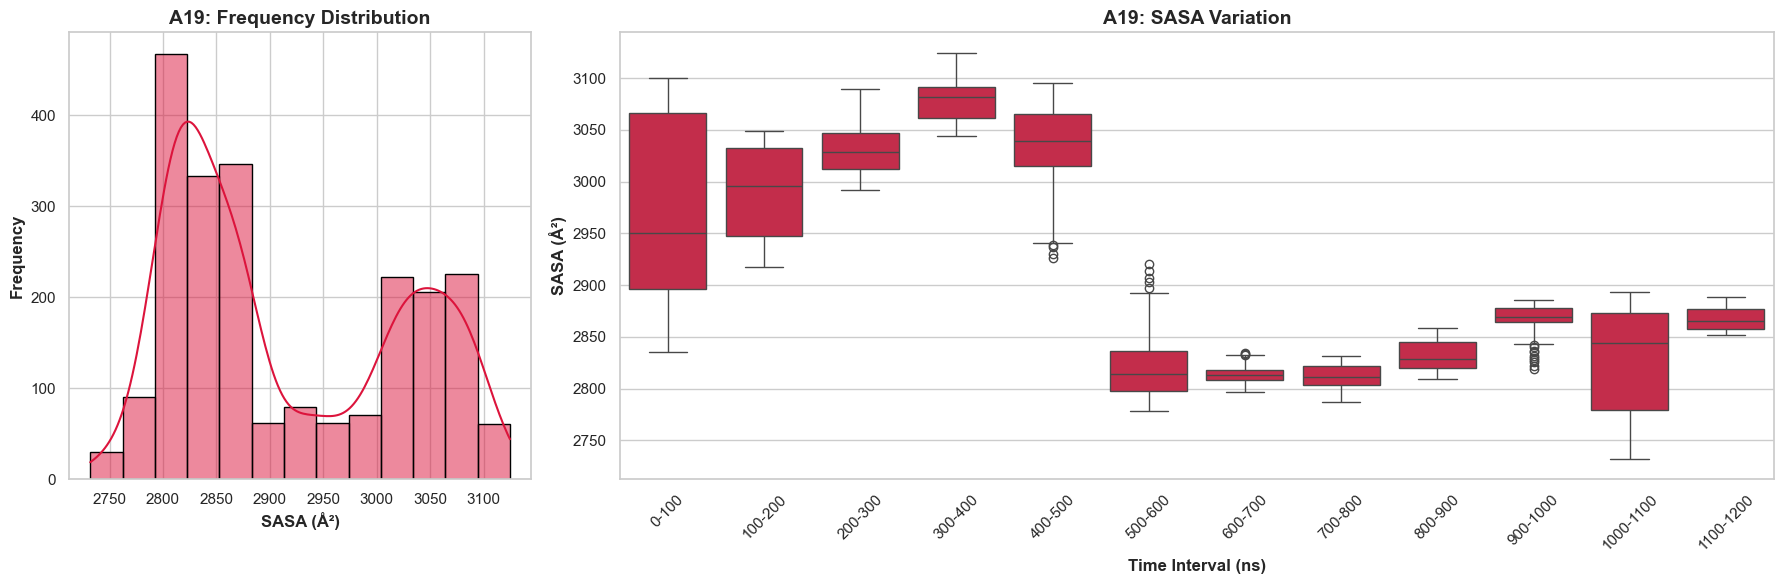

 -> Saved: SASA_Isolated_Hist_A19.png


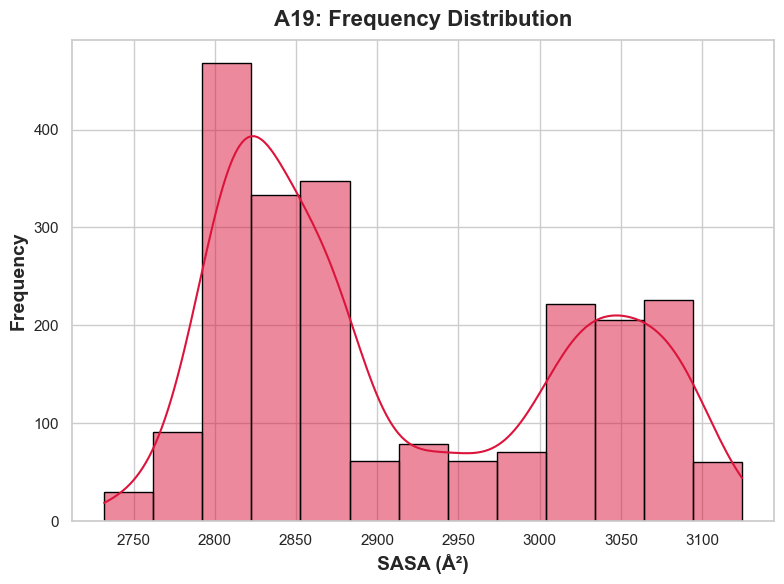

 -> Saved: SASA_Isolated_Box_A19.png


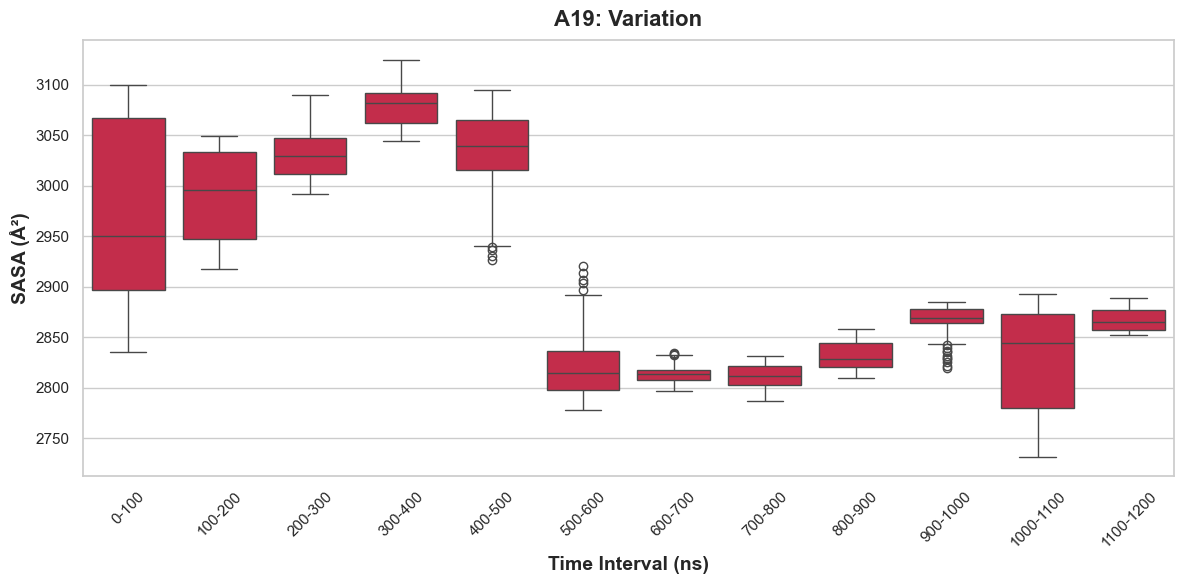

 -> Saved: SASA_Composite_R16.png


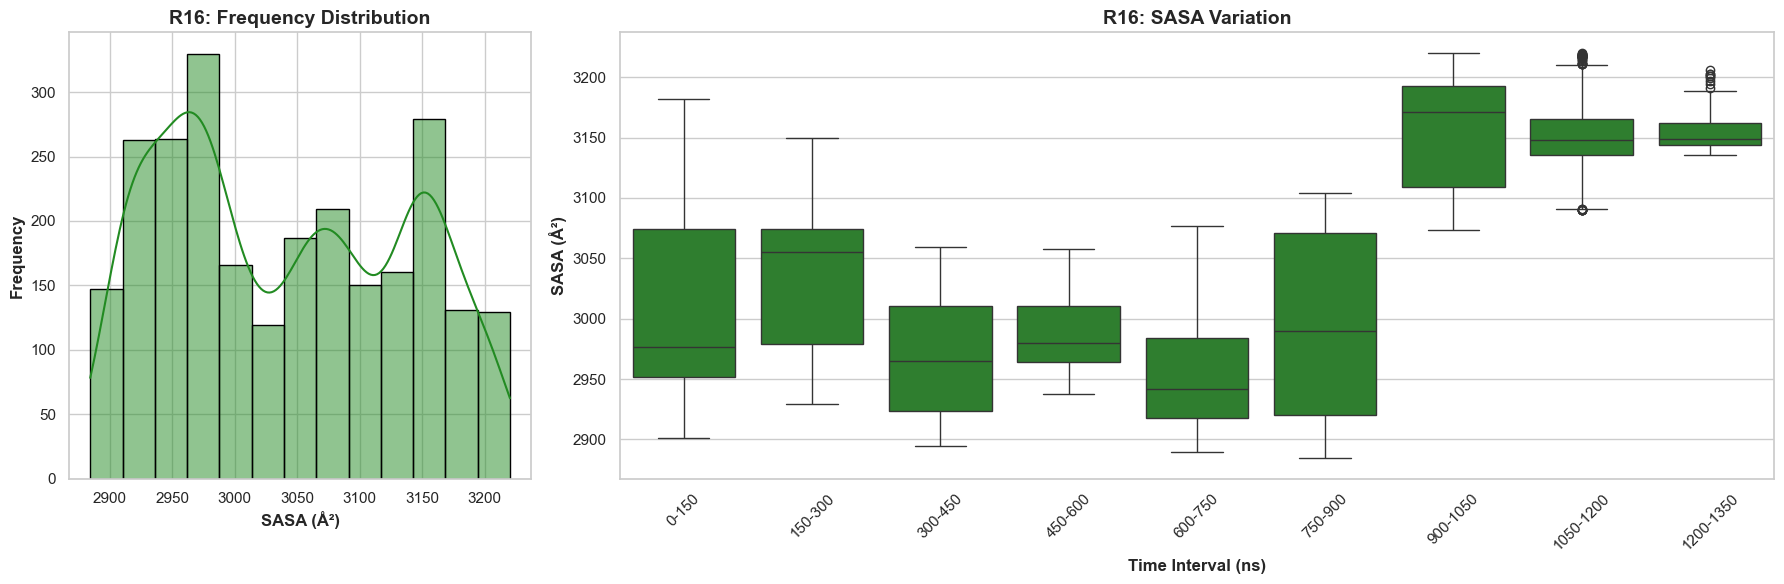

 -> Saved: SASA_Isolated_Hist_R16.png


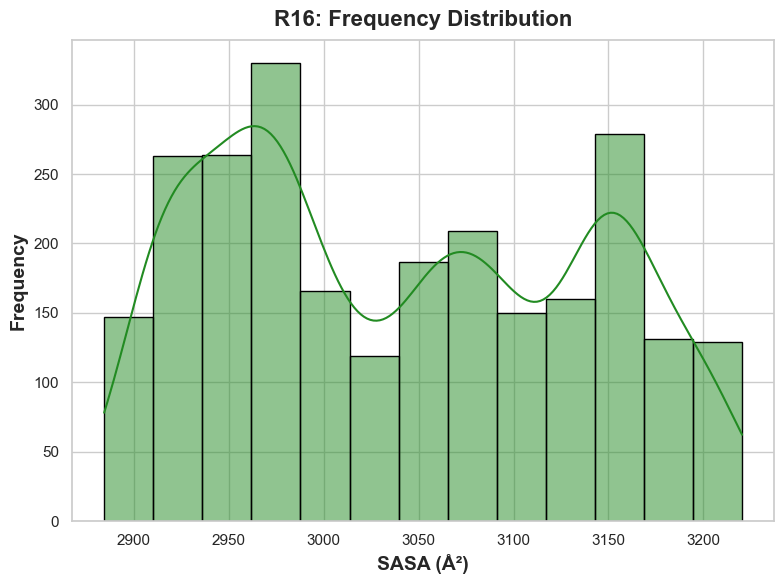

 -> Saved: SASA_Isolated_Box_R16.png


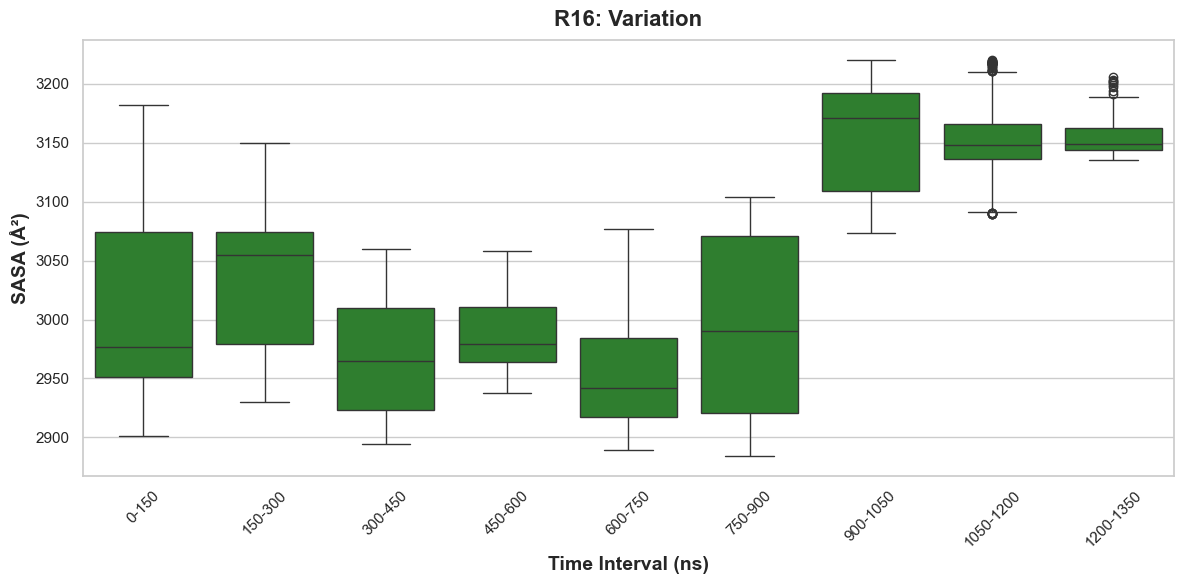

 -> Saved: SASA_Composite_A17.png


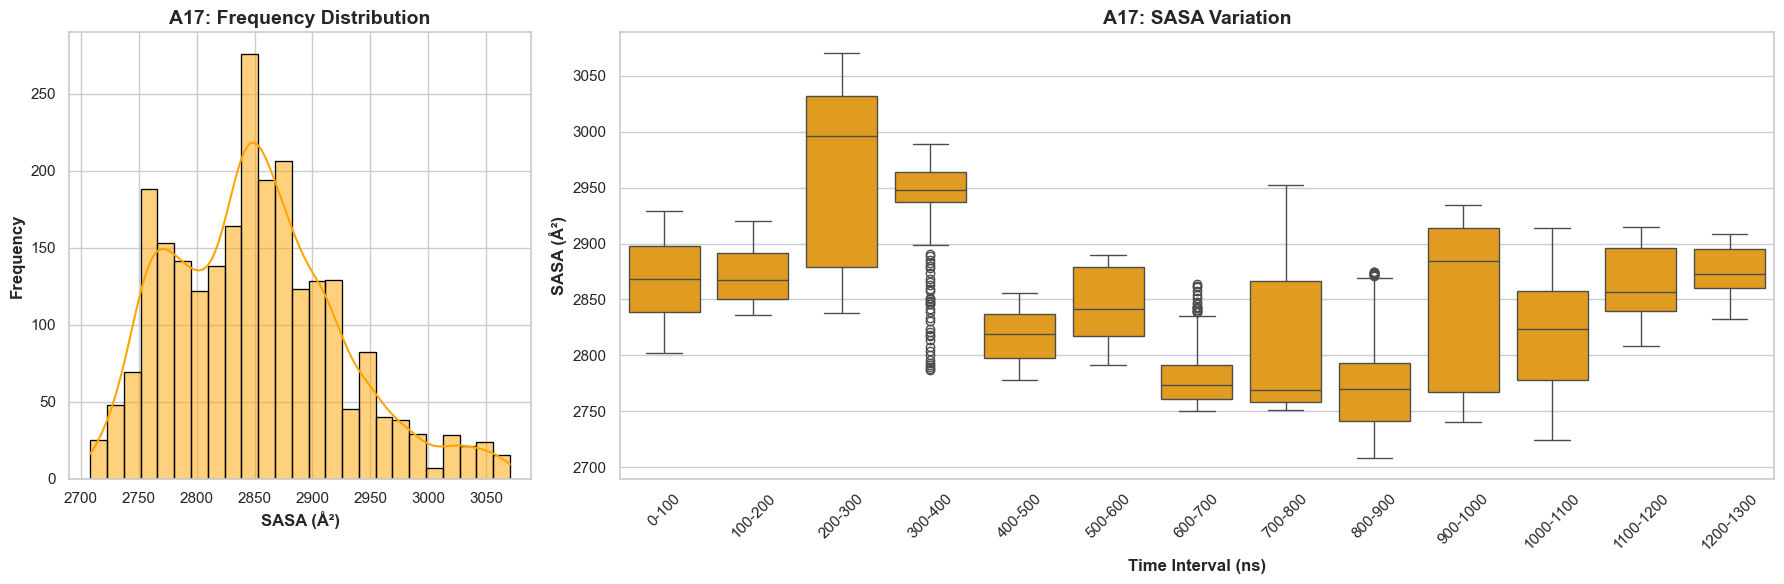

 -> Saved: SASA_Isolated_Hist_A17.png


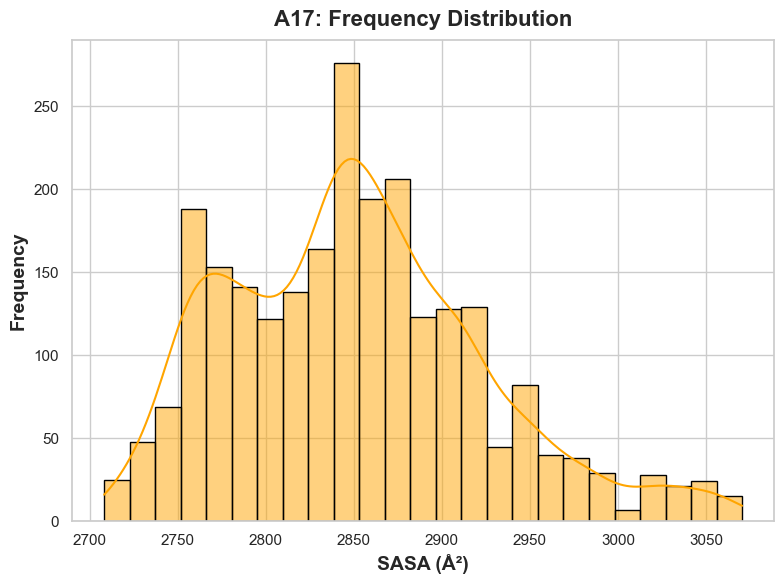

 -> Saved: SASA_Isolated_Box_A17.png


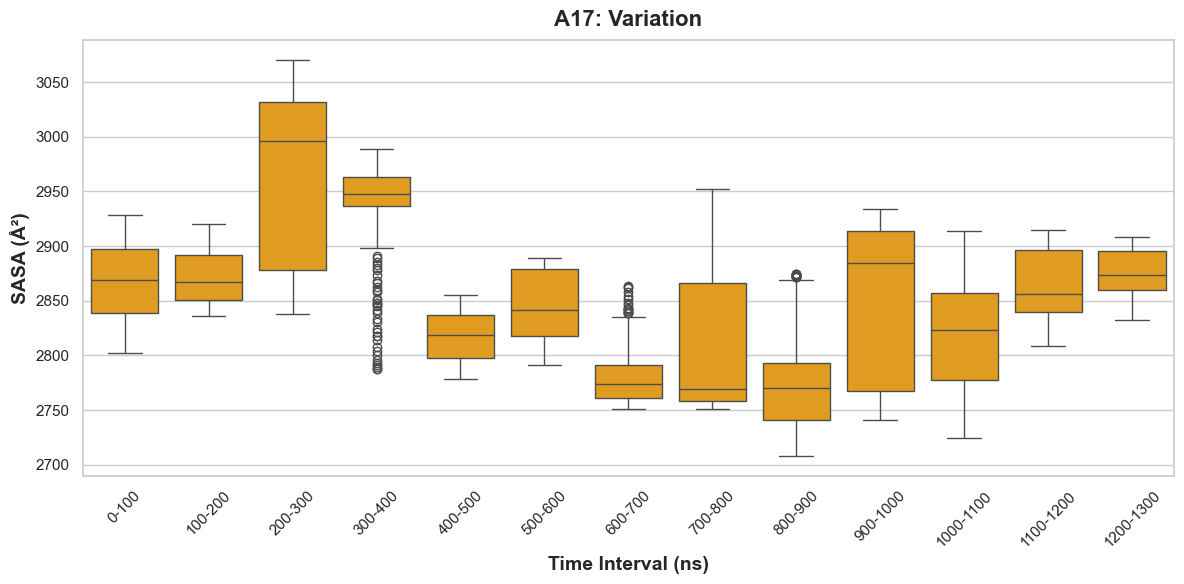


All dynamic SASA distribution plots generated successfully.


In [37]:
# Cell 4: SASA Distributions, Histograms, and Dynamic Time-Binned Boxplots

print("Generating Global and Isolated SASA Distributions...\n")

# Prep data for global plotting
df_melted = df_sasa_master.melt(
    id_vars='Time_ns', 
    value_vars=[s for s in systems_to_show if s in df_sasa_master.columns], 
    var_name='System', 
    value_name='SASA'
).dropna()

# ==============================================================================
# --- 1. Global Boxplot ---
# ==============================================================================
fig_comp, ax_comp = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_melted, x='System', y='SASA', palette=system_colors, ax=ax_comp)

ax_comp.set_title("Intracellular Cavity SASA Distribution", fontsize=16, fontweight='bold', pad=15)
ax_comp.set_xlabel("System", fontsize=14, fontweight='bold')
ax_comp.set_ylabel("SASA (Å²)", fontsize=14, fontweight='bold')
plt.tight_layout()

save_and_show(fig_comp, out_base_sasa_global_box)

# ==============================================================================
# --- 2. Per-System Plots (Composite and Isolated) ---
# ==============================================================================
target_bins = 10  # Optimal readability

for system in systems_to_show:
    if system not in df_sasa_master.columns: continue
    
    # Isolate system data and drop NaNs resulting from differing trajectory lengths
    sys_data = df_sasa_master[['Time_ns', system]].dropna().copy()
    if sys_data.empty: continue

    # Dynamic Interval Calculation
    max_time = sys_data['Time_ns'].max()
    raw_interval = max_time / target_bins
    time_interval_ns = max(50, int(round(raw_interval / 50.0) * 50.0))
    
    bins = np.arange(0, max_time + time_interval_ns, time_interval_ns)
    labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]
    sys_data['Time_Bin'] = pd.cut(sys_data['Time_ns'], bins=bins, labels=labels, include_lowest=True)
    
    # ---------------------------------------------------------
    # PLOT A: Composite Figure (1x2)
    # ---------------------------------------------------------
    fig_sys, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [1, 2.5]})
    
    sns.histplot(sys_data[system], kde=True, color=system_colors[system], ax=ax_hist, edgecolor='black')
    ax_hist.set_title(f"{system}: Frequency Distribution", fontsize=14, fontweight='bold')
    ax_hist.set_xlabel("SASA (Å²)", fontsize=12, fontweight='bold')
    ax_hist.set_ylabel("Frequency", fontsize=12, fontweight='bold')
    
    sns.boxplot(data=sys_data, x='Time_Bin', y=system, color=system_colors[system], ax=ax_box)
    ax_box.set_title(f"{system}: SASA Variation", fontsize=14, fontweight='bold')
    ax_box.set_xlabel("Time Interval (ns)", fontsize=12, fontweight='bold')
    ax_box.set_ylabel("SASA (Å²)", fontsize=12, fontweight='bold')
    ax_box.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    
    save_and_show(fig_sys, out_base_sasa_composite[system])

    # ---------------------------------------------------------
    # PLOT B: Isolated Histogram
    # ---------------------------------------------------------
    fig_iso_h, ax_iso_h = plt.subplots(figsize=(8, 6))
    sns.histplot(sys_data[system], kde=True, color=system_colors[system], ax=ax_iso_h, edgecolor='black')
    ax_iso_h.set_title(f"{system}: Frequency Distribution", fontsize=16, fontweight='bold', pad=10)
    ax_iso_h.set_xlabel("SASA (Å²)", fontsize=14, fontweight='bold')
    ax_iso_h.set_ylabel("Frequency", fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    save_and_show(fig_iso_h, out_base_sasa_hist_iso[system])

    # ---------------------------------------------------------
    # PLOT C: Isolated Time-Binned Boxplot
    # ---------------------------------------------------------
    fig_iso_b, ax_iso_b = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=sys_data, x='Time_Bin', y=system, color=system_colors[system], ax=ax_iso_b)
    ax_iso_b.set_title(f"{system}: Variation", fontsize=16, fontweight='bold', pad=10)
    ax_iso_b.set_xlabel("Time Interval (ns)", fontsize=14, fontweight='bold')
    ax_iso_b.set_ylabel("SASA (Å²)", fontsize=14, fontweight='bold')
    ax_iso_b.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    
    save_and_show(fig_iso_b, out_base_sasa_box_iso[system])

print("\nAll dynamic SASA distribution plots generated successfully.")

Generating SASA Composite Grids...

 -> Saved Composite Boxplots: SASA_Grid_Boxplots.png | SASA_Grid_Boxplots.pdf


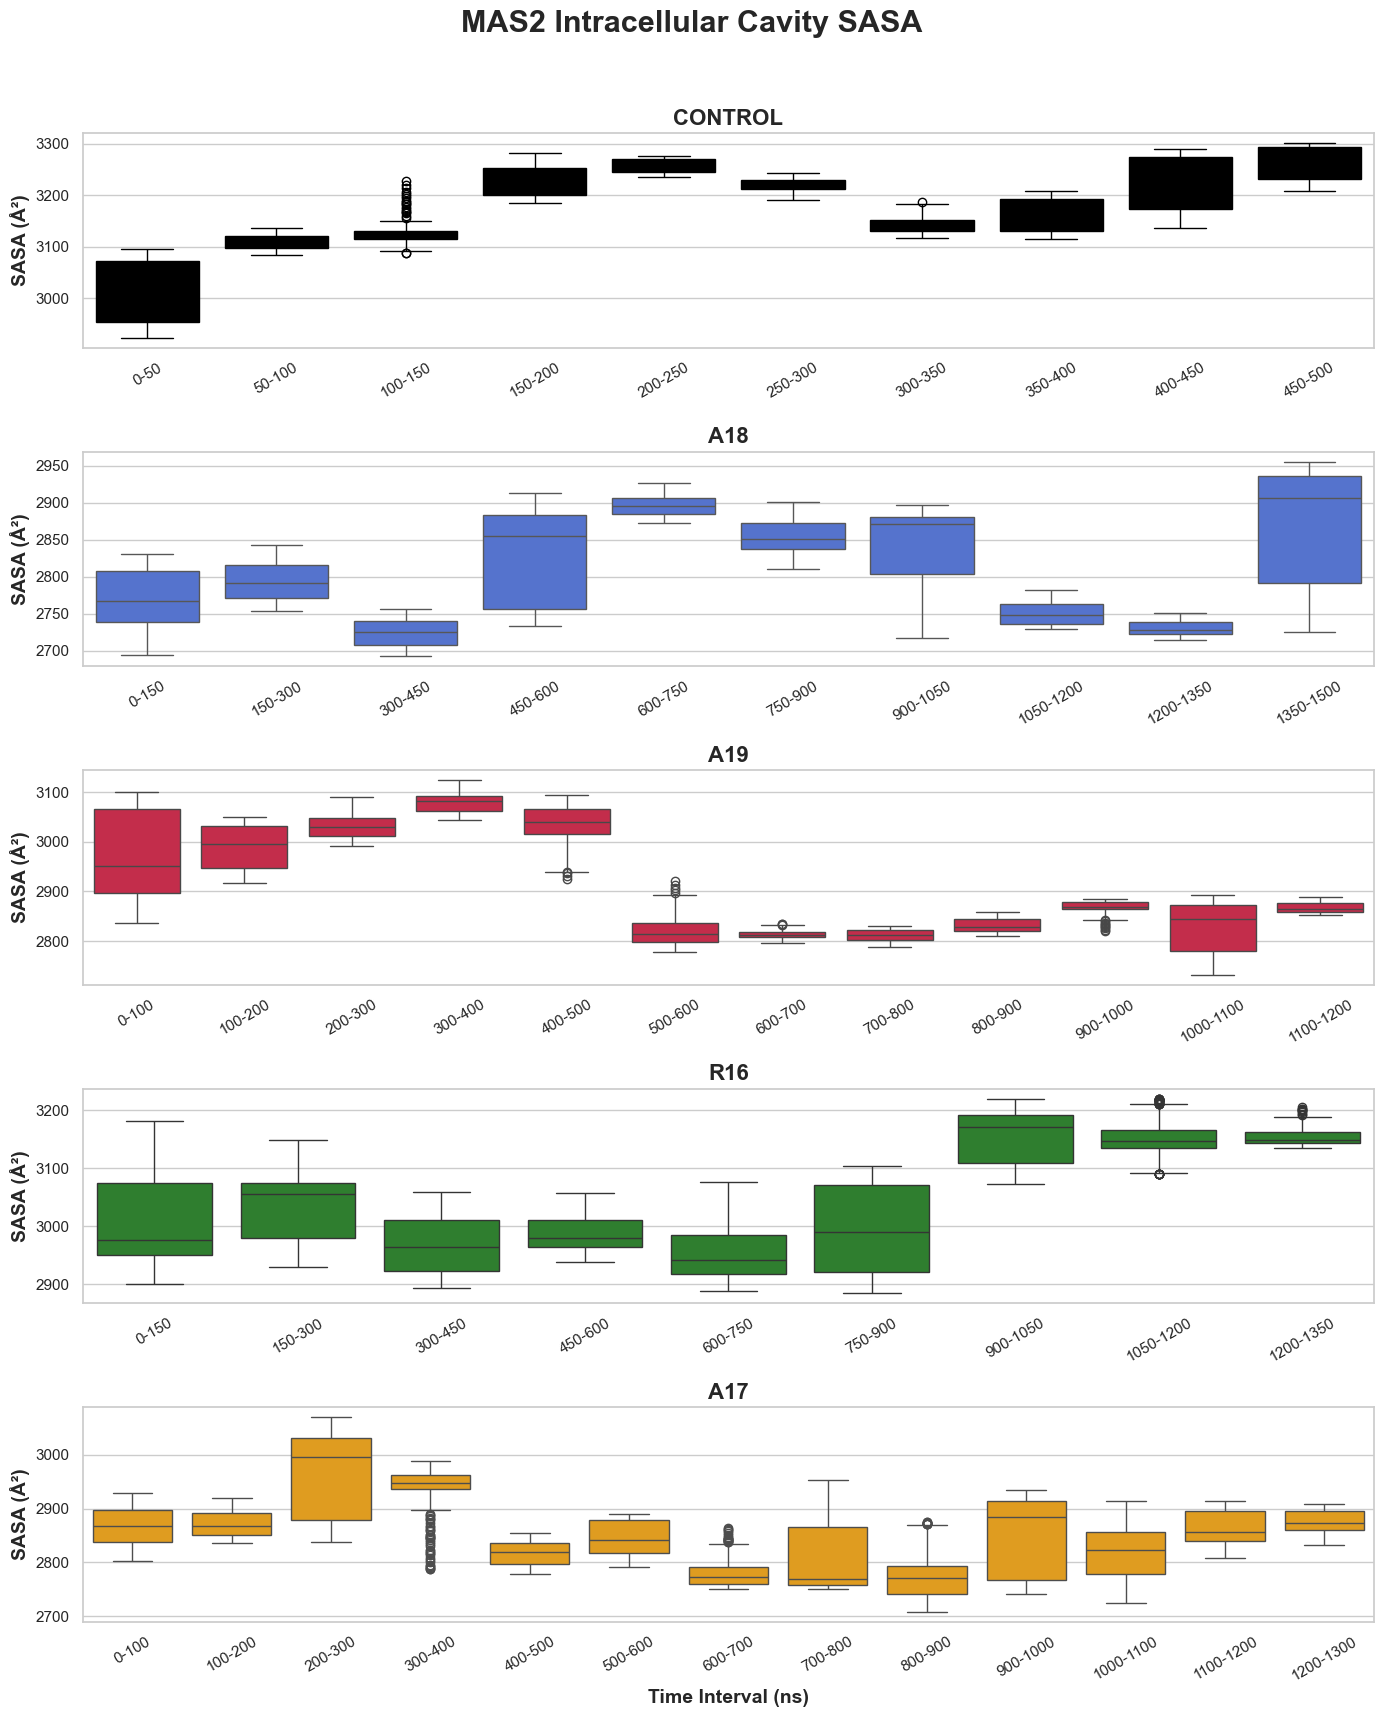

 -> Saved Composite Histograms: SASA_Grid_Histograms.png | SASA_Grid_Histograms.pdf


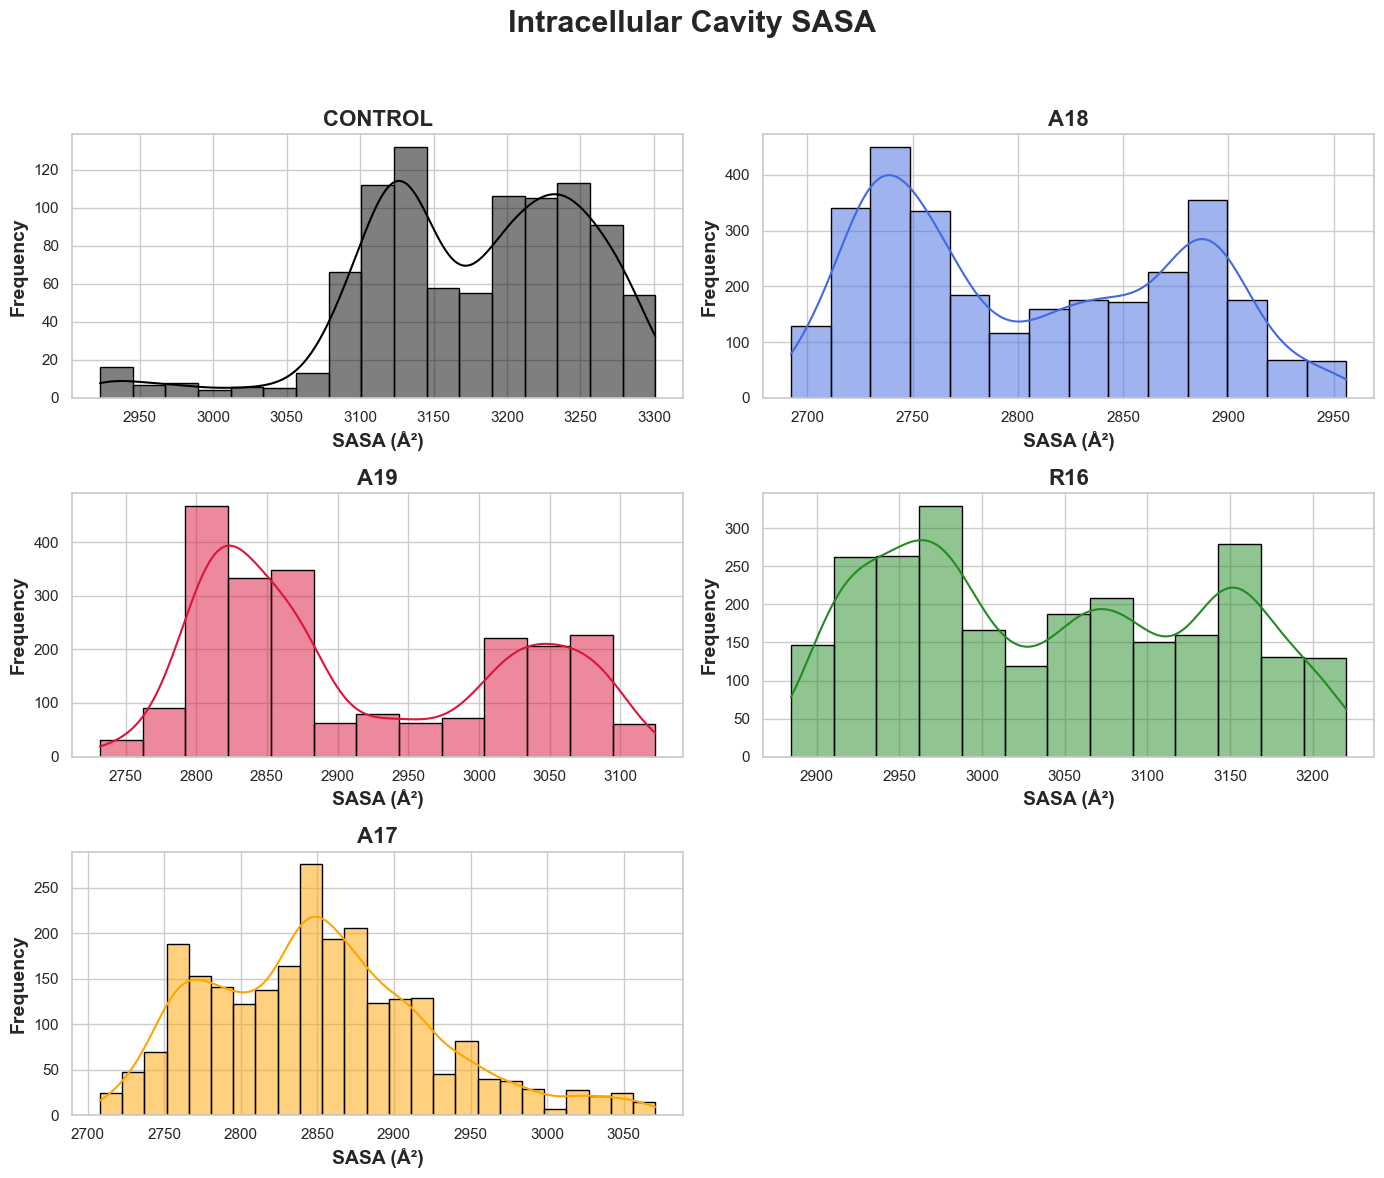


All composite grids generated and exported successfully.


In [41]:
# Cell 5: SASA Composite Grids (Dynamic Boxplots & Histograms)
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating SASA Composite Grids...\n")

target_bins = 10  # Maintain consistent readability per system
n_systems = len(systems_to_show)

# ==============================================================================
# --- 1. Dynamic Interval Boxplot Grid ---
# ==============================================================================
# Dynamically scale the figure height (e.g., 3.5 inches per system)
box_fig_height = max(10, n_systems * 3.5)
fig_grid_box, axes_box = plt.subplots(nrows=n_systems, ncols=1, figsize=(14, box_fig_height))
fig_grid_box.suptitle(f'{systemid} Intracellular Cavity SASA', fontsize=22, fontweight='bold', y=0.98)

# Ensure axes_box is iterable even if there's only 1 system
if n_systems == 1:
    axes_box = [axes_box]

for idx, system in enumerate(systems_to_show):
    ax = axes_box[idx]
    
    if system not in df_sasa_master.columns:
        ax.set_visible(False)
        continue
        
    sys_data = df_sasa_master[['Time_ns', system]].dropna().copy()
    if sys_data.empty:
        ax.set_visible(False)
        continue

    # Dynamic Interval Calculation (Independent for each subplot)
    max_time = sys_data['Time_ns'].max()
    raw_interval = max_time / target_bins
    time_interval_ns = max(50, int(round(raw_interval / 50.0) * 50.0))
    
    bins = np.arange(0, max_time + time_interval_ns, time_interval_ns)
    labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]
    sys_data['Time_Bin'] = pd.cut(sys_data['Time_ns'], bins=bins, labels=labels, include_lowest=True)
    
    sns.boxplot(data=sys_data, x='Time_Bin', y=system, color=system_colors[system], ax=ax)
    
    # Styling Subplot
    ax.set_title(system, fontsize=16, fontweight='bold')
    ax.set_ylabel("SASA (Å²)", fontsize=14, fontweight='bold')
    
    # Only label the X-axis fully on the very bottom plot to save space
    is_last_plot = (idx == n_systems - 1)
    ax.set_xlabel("Time Interval (ns)" if is_last_plot else "", fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Prevent title overlap

# Explicit Export (PNG & PDF) & Display
png_box = out_base_sasa_grid_box.with_suffix('.png')
pdf_box = out_base_sasa_grid_box.with_suffix('.pdf')
fig_grid_box.savefig(png_box, dpi=1200, bbox_inches='tight')
fig_grid_box.savefig(pdf_box, bbox_inches='tight')
print(f" -> Saved Composite Boxplots: {png_box.name} | {pdf_box.name}")
plt.show()


# ==============================================================================
# --- 2. Dynamic Histogram Grid ---
# ==============================================================================
# Calculate required rows based on 2 columns
n_cols = 2
n_rows = math.ceil(n_systems / n_cols)
hist_fig_height = max(6, n_rows * 4) # 4 inches per row

fig_grid_hist, axes_hist = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(14, hist_fig_height))
fig_grid_hist.suptitle("Intracellular Cavity SASA", fontsize=22, fontweight='bold', y=0.98)

# Flatten the array for easy iteration
axes_hist_flat = axes_hist.flatten() if n_systems > 1 else [axes_hist]

for idx, ax in enumerate(axes_hist_flat):
    # Hide axes that exceed our system count (e.g., the 6th slot when plotting 5 systems)
    if idx >= n_systems:
        ax.set_visible(False)
        continue
        
    system = systems_to_show[idx]
    
    if system not in df_sasa_master.columns:
        ax.set_visible(False)
        continue
        
    sys_data = df_sasa_master[['Time_ns', system]].dropna().copy()
    if sys_data.empty:
        ax.set_visible(False)
        continue
        
    sns.histplot(sys_data[system], kde=True, color=system_colors[system], ax=ax, edgecolor='black')
    
    # Styling Subplot
    ax.set_title(system, fontsize=16, fontweight='bold')
    ax.set_xlabel("SASA (Å²)", fontsize=14, fontweight='bold')
    ax.set_ylabel("Frequency", fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])  # Prevent title overlap

# Explicit Export (PNG & PDF) & Display
png_hist = out_base_sasa_grid_hist.with_suffix('.png')
pdf_hist = out_base_sasa_grid_hist.with_suffix('.pdf')
fig_grid_hist.savefig(png_hist, dpi=1200, bbox_inches='tight')
fig_grid_hist.savefig(pdf_hist, bbox_inches='tight')
print(f" -> Saved Composite Histograms: {png_hist.name} | {pdf_hist.name}")
plt.show()

print("\nAll composite grids generated and exported successfully.")

# Intracelular Cavity Comparison: Volume

In [42]:
# Cell 5: Volume File Discovery, Helpers, and Output Registry

general_folder_path = Path(f"{systemid}/DATA")

system_colors = {
    "CONTROL": "black",
    "A18": "royalblue",
    "A19": "crimson",
    "R16": "forestgreen",
    "A17": "orange"
}

# --- Centralized Plotting Helper ---
def save_and_show(fig, base_path):
    """Saves plots as high-res PNG and PDF, then displays them inline."""
    png_path = base_path.with_suffix('.png')
    pdf_path = base_path.with_suffix('.pdf')
    fig.savefig(png_path, dpi=1200, bbox_inches='tight')
    fig.savefig(pdf_path, bbox_inches='tight')
    print(f" -> Saved: {png_path.name}")
    plt.show()

# --- File Discovery ---
vol_files = {}
print(f"Scanning '{general_folder_path}' for Volume files...\n")

for system in system_colors.keys():
    system_dir = general_folder_path / system
    if system_dir.exists():
        found_files = list(system_dir.rglob("*[iI]ntracellular_[pP]ocket_[vV]olume*.csv"))
        if found_files:
            vol_files[system] = found_files[0]
            print(f" [Found] {system}: '{found_files[0].name}'")
        else:
            print(f" [Missing] {system}: No Volume file found.")
    else:
        print(f" [Missing] {system}: Directory not found.")

# ── Global Output Registry ────────────────────────────────────────────────────

# 1. Data Tables
fn_vol_table_csv = general_folder_path / "Volume_Smoothed_Data_Master.csv"

# 2. Comparison Line Plot
out_base_vol_comp = general_folder_path / "Volume_System_Comparison"

# 3. Global Boxplot
out_base_vol_global_box = general_folder_path / "Volume_Global_Boxplot"

# 4. Per-System Dictionaries
out_base_vol_composite = {sys: general_folder_path / f"Volume_Composite_{sys}" for sys in system_colors.keys()}
out_base_vol_hist_iso  = {sys: general_folder_path / f"Volume_Isolated_Hist_{sys}" for sys in system_colors.keys()}
out_base_vol_box_iso   = {sys: general_folder_path / f"Volume_Isolated_Box_{sys}" for sys in system_colors.keys()}

# 5. Composite Grids
out_base_vol_grid_box = general_folder_path / "Volume_Grid_Boxplots"
out_base_vol_grid_hist = general_folder_path / "Volume_Grid_Histograms"

print("\nOutput registry configured.")

Scanning 'MAS2/DATA' for Volume files...

 [Found] CONTROL: 'CONTROL_Intracellular_Pocket_Volume.csv'
 [Found] A18: 'A18_Intracellular_Pocket_Volume.csv'
 [Found] A19: 'A19_Intracellular_Pocket_Volume.csv'
 [Found] R16: 'R16_Intracellular_Pocket_Volume.csv'
 [Found] A17: 'A17_Intracellular_Pocket_Volume.csv'

Output registry configured.


Aggregating time-aligned Volume data and generating comparison plot...

 -> Master Data Table saved: Volume_Smoothed_Data_Master.csv
 -> Saved: Volume_System_Comparison.png


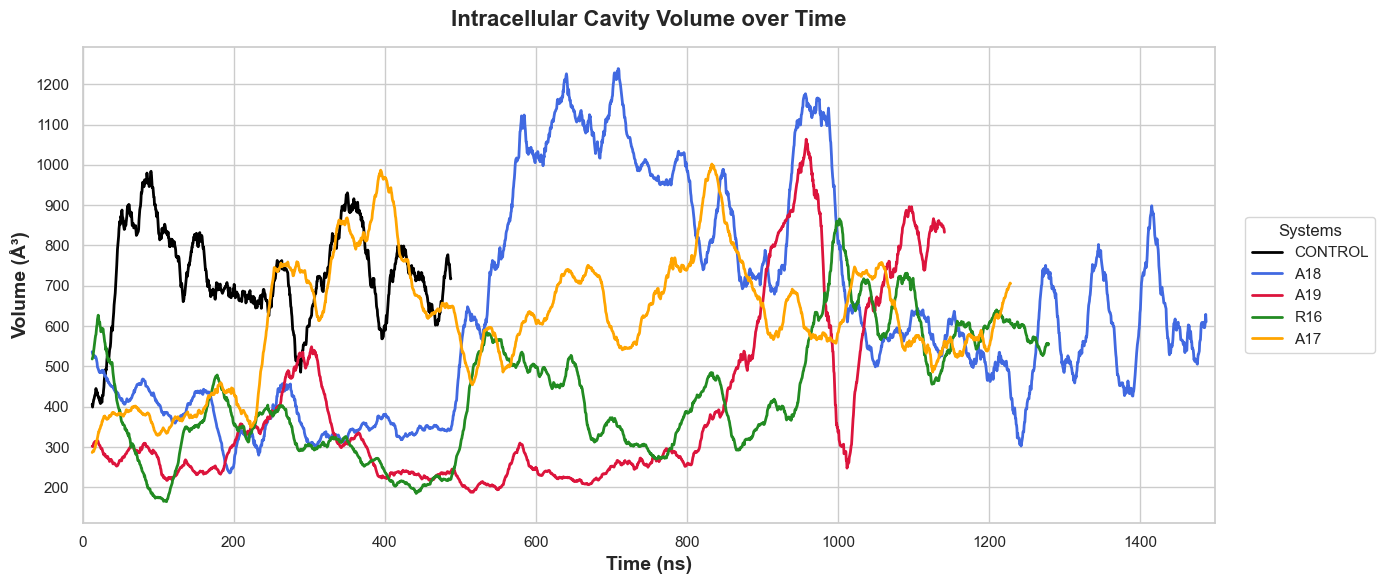

In [45]:
# Cell 6: Robust Time-Aligned Volume Aggregation and Smoothing Comparison

fig_vol, ax_vol = plt.subplots(figsize=(14, 6))
print("Aggregating time-aligned Volume data and generating comparison plot...")

# =====================================================================
systems_to_show = ["CONTROL", "A18", "A19", "R16", "A17"] 
# =====================================================================

window_size = 50 
max_x_val = 0    

vol_data_dict = {} 

for system, filepath in vol_files.items():
    df = pd.read_csv(filepath)
    
    # Robust Column Targeting
    time_col = next((col for col in df.columns if 'time' in col.lower()), None)
    y_col = next((col for col in df.columns if 'volume' in col.lower() or 'vol' in col.lower()), None)
    
    if time_col and y_col:
        # Set Time as the DataFrame index to force perfect chronological alignment
        df = df.set_index(time_col)
        
        smoothed_vol = df[y_col].rolling(window=window_size, center=True).mean()
        vol_data_dict[system] = smoothed_vol
        
        if system in systems_to_show:
            ax_vol.plot(smoothed_vol.index, smoothed_vol.values, 
                        label=system, color=system_colors[system], linewidth=2.0)
            
            current_max = smoothed_vol.index.max()
            if current_max > max_x_val: max_x_val = current_max

# Create Master DataFrame (Safe merge via Time Index)
df_vol_master = pd.DataFrame(vol_data_dict).reset_index().rename(columns={'index': 'Time_ns'})
df_vol_master.to_csv(fn_vol_table_csv, index=False)
print(f"\n -> Master Data Table saved: {fn_vol_table_csv.name}")

# Axis Formatting
x_major_interval = 200  
x_minor_interval = 50   
y_major_interval = 100   
y_minor_interval = 25   

ax_vol.xaxis.set_major_locator(ticker.MultipleLocator(x_major_interval))
ax_vol.xaxis.set_minor_locator(ticker.MultipleLocator(x_minor_interval))
ax_vol.yaxis.set_major_locator(ticker.MultipleLocator(y_major_interval))
ax_vol.yaxis.set_minor_locator(ticker.MultipleLocator(y_minor_interval))

ax_vol.tick_params(axis='both', which='major', length=6, color='black')
ax_vol.tick_params(axis='both', which='minor', length=4, color='gray')

ax_vol.set_title("Intracellular Cavity Volume over Time", fontsize=16, fontweight='bold', pad=15)
ax_vol.set_xlabel("Time (ns)", fontsize=14, fontweight='bold')
ax_vol.set_ylabel("Volume (Å³)", fontsize=14, fontweight='bold')

ax_vol.set_xlim(0, max_x_val if max_x_val > 0 else 5000)
ax_vol.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True, title="Systems")
plt.tight_layout()

save_and_show(fig_vol, out_base_vol_comp)

Generating Volume Distributions and Grids...



/tmp/ipykernel_6626/3511400044.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_melted, x='System', y='Volume', palette=system_colors, ax=ax_comp)


 -> Saved: Volume_Global_Boxplot.png


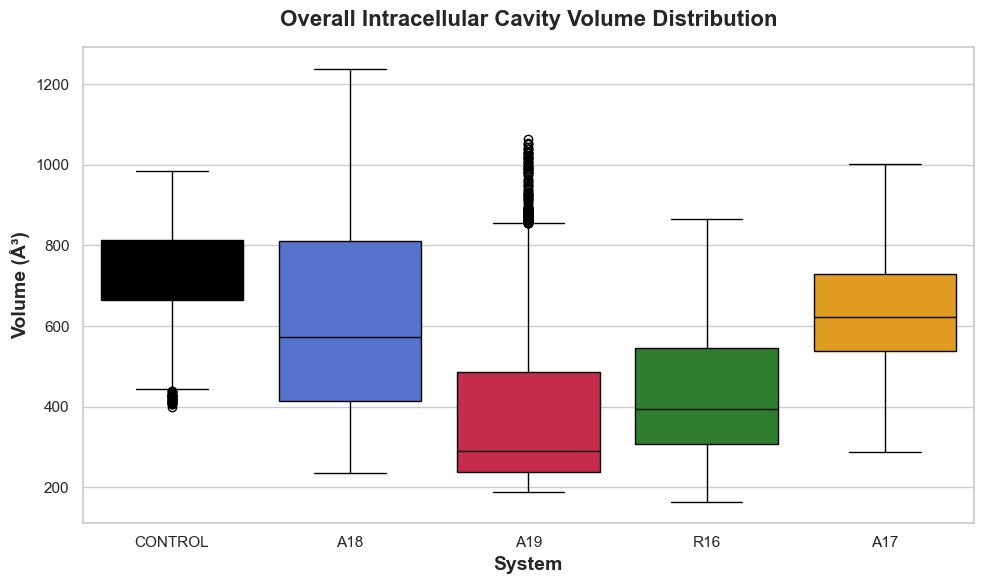

 -> Saved: Volume_Composite_CONTROL.png


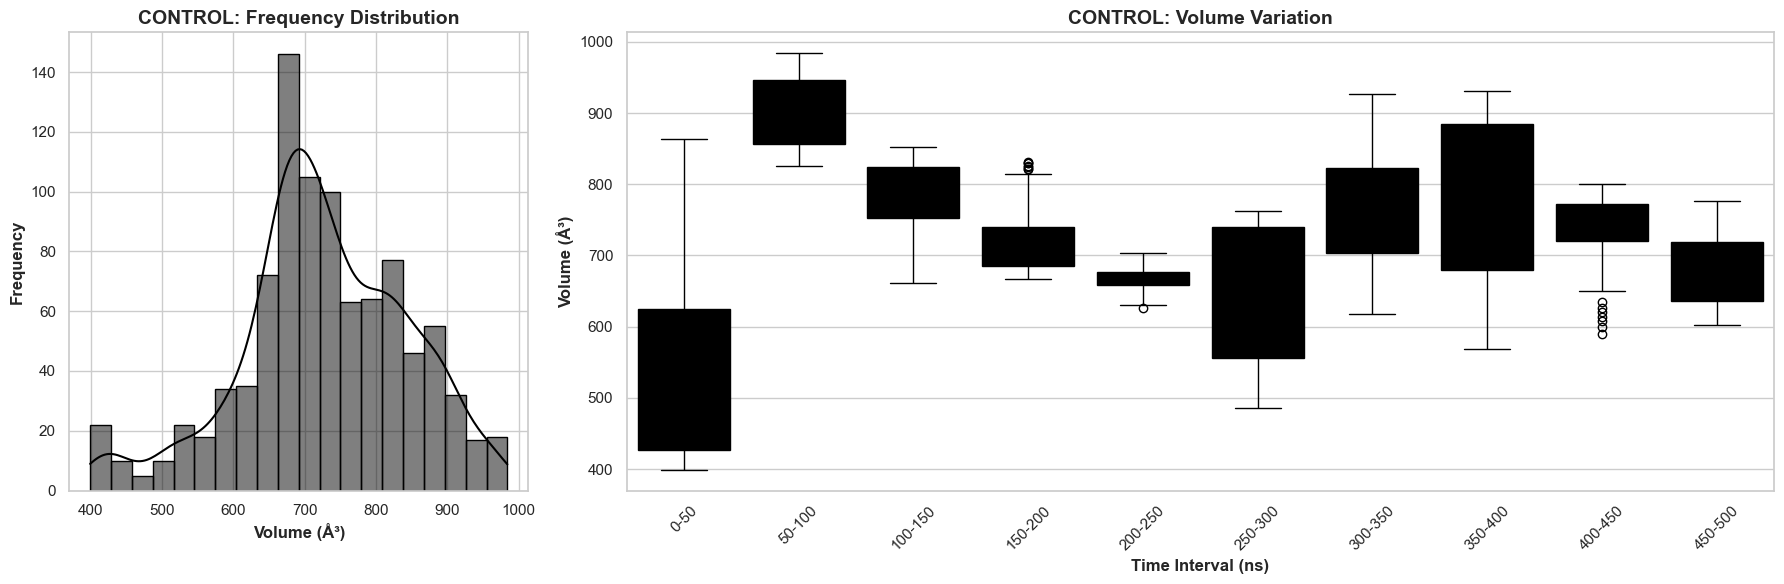

 -> Saved: Volume_Isolated_Hist_CONTROL.png


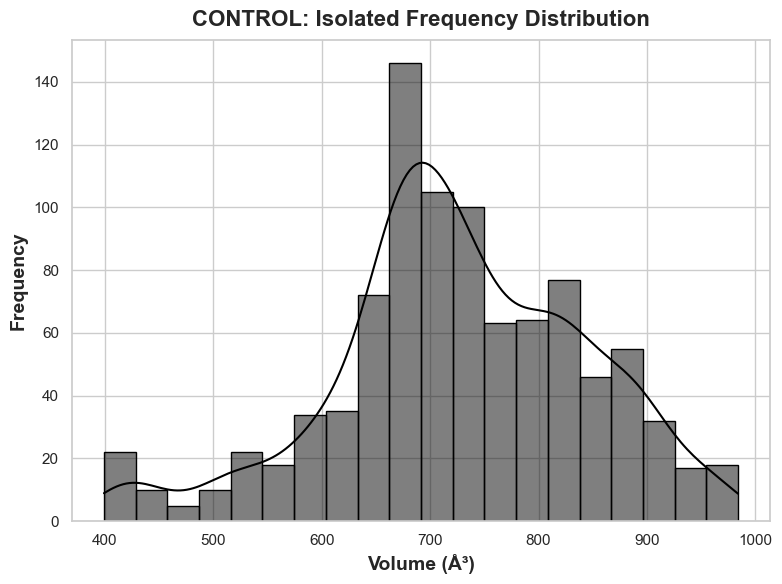

 -> Saved: Volume_Isolated_Box_CONTROL.png


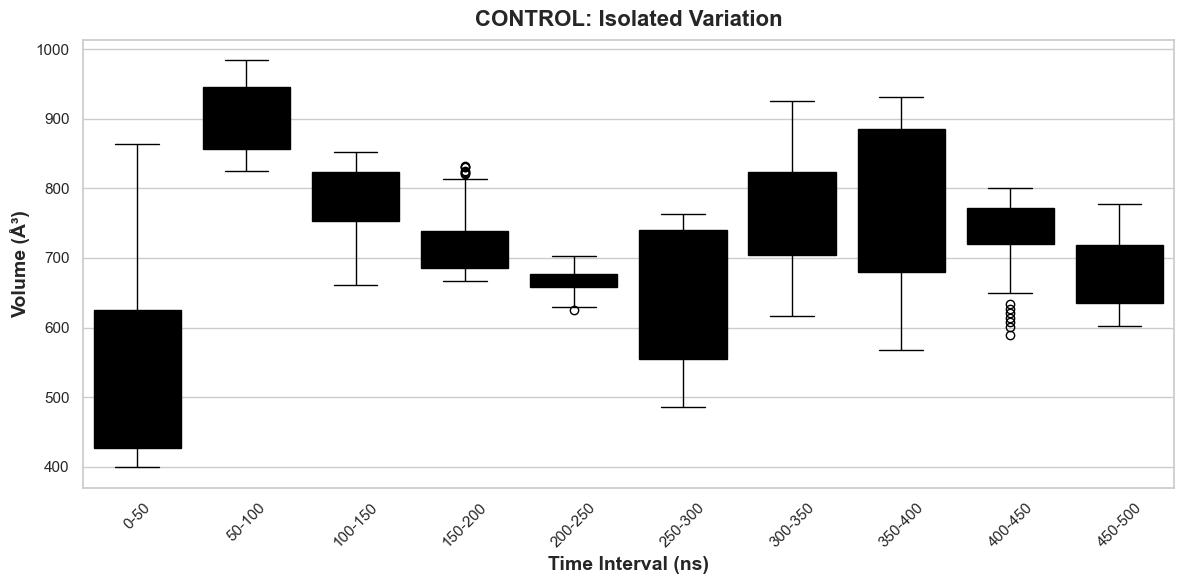

 -> Saved: Volume_Composite_A18.png


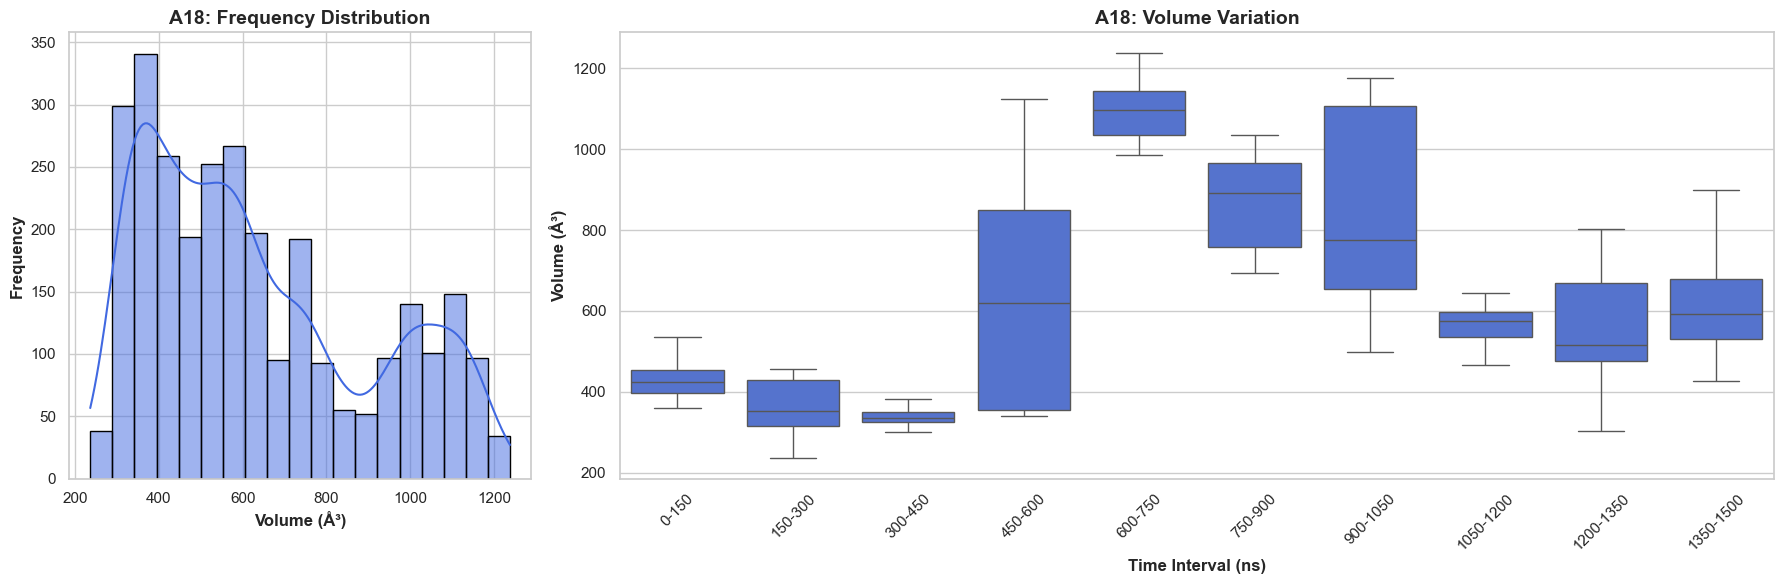

 -> Saved: Volume_Isolated_Hist_A18.png


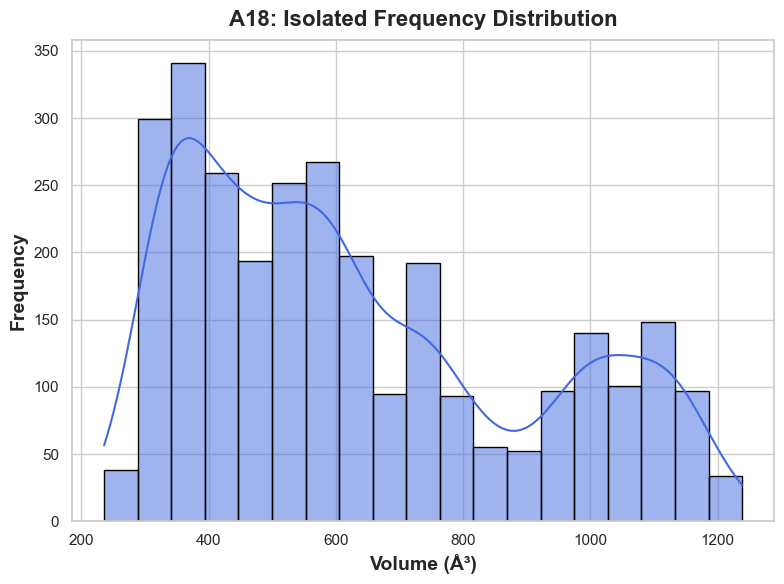

 -> Saved: Volume_Isolated_Box_A18.png


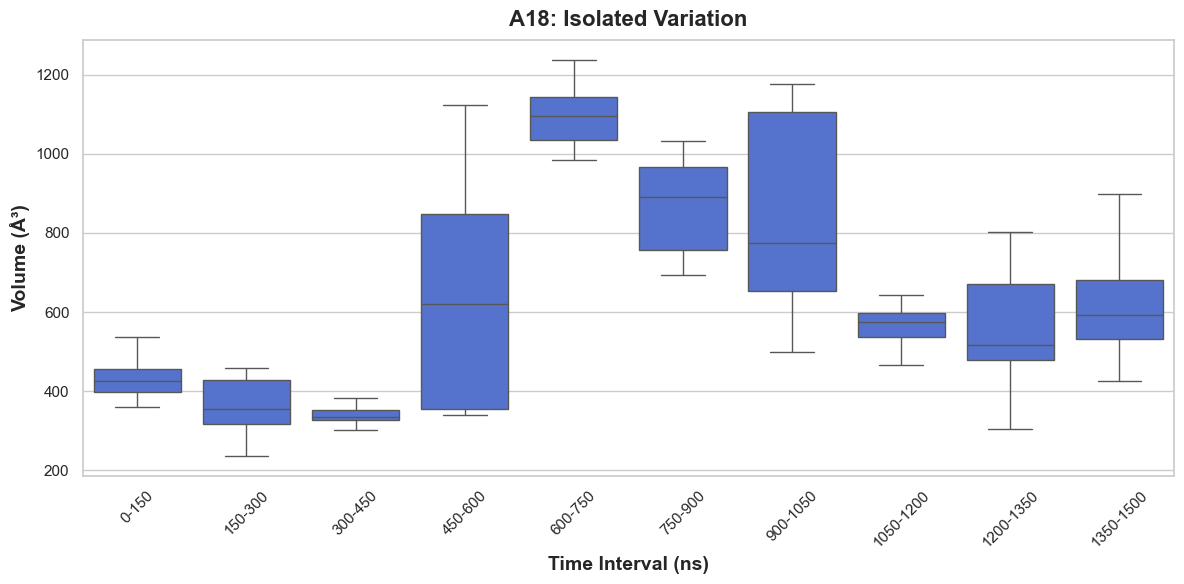

 -> Saved: Volume_Composite_A19.png


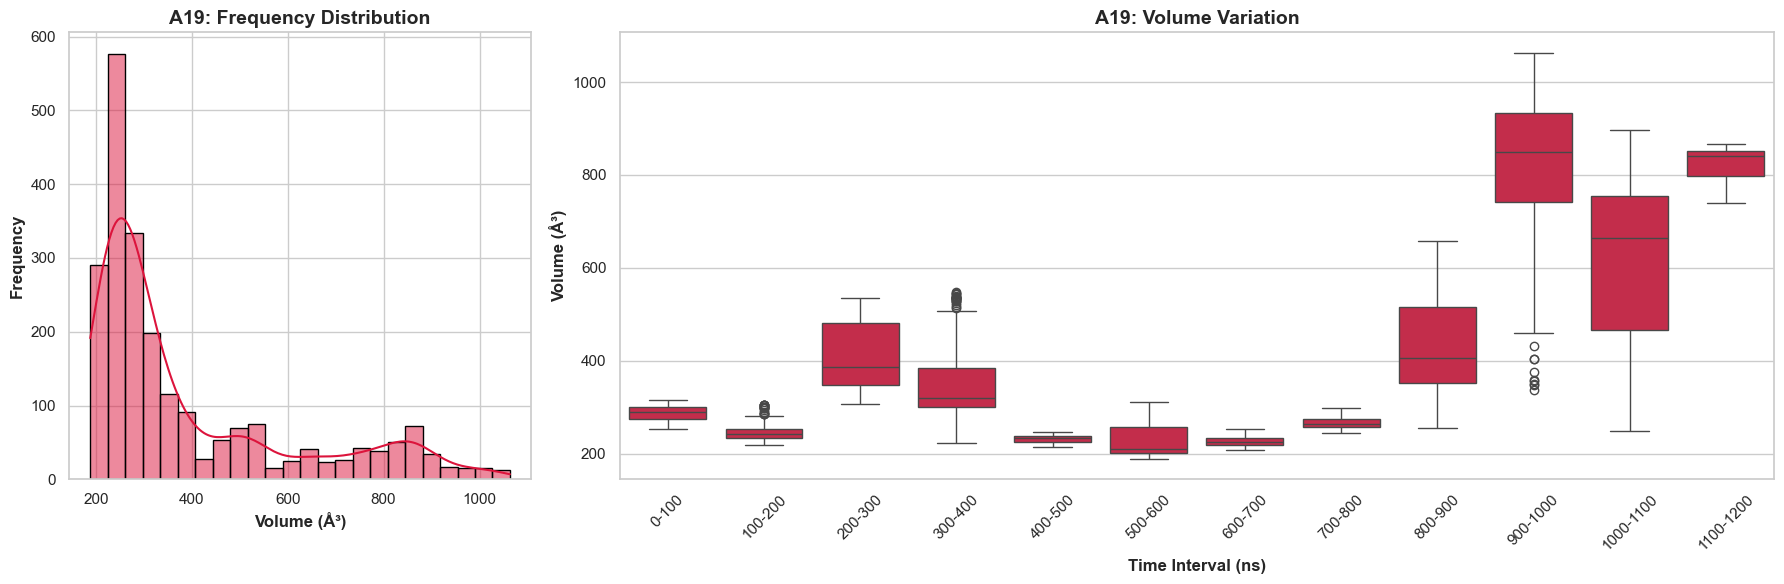

 -> Saved: Volume_Isolated_Hist_A19.png


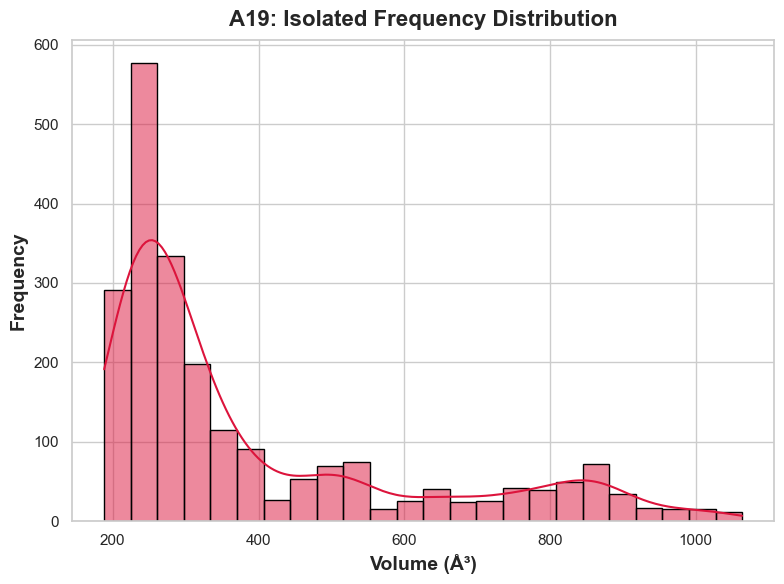

 -> Saved: Volume_Isolated_Box_A19.png


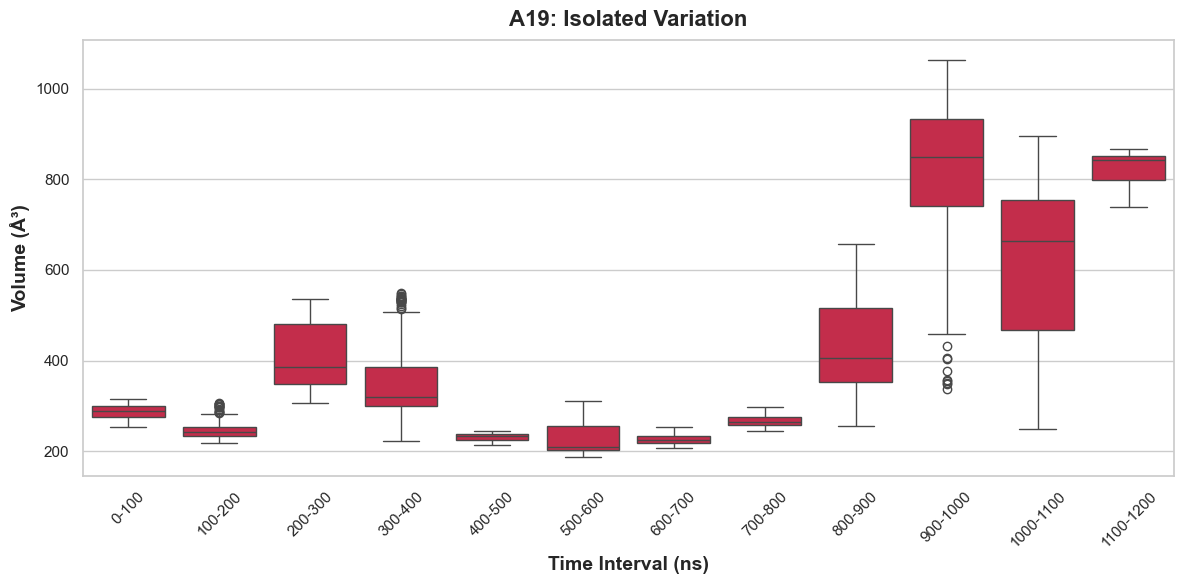

 -> Saved: Volume_Composite_R16.png


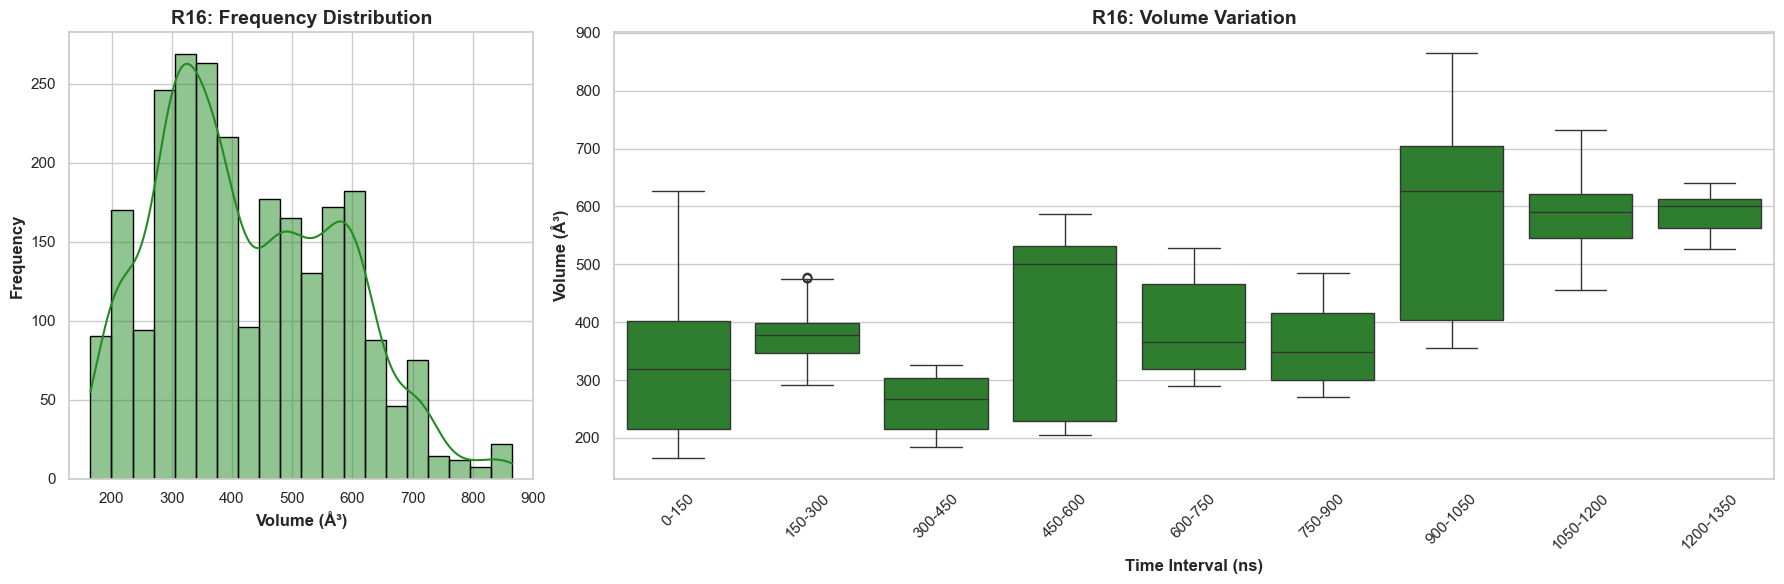

 -> Saved: Volume_Isolated_Hist_R16.png


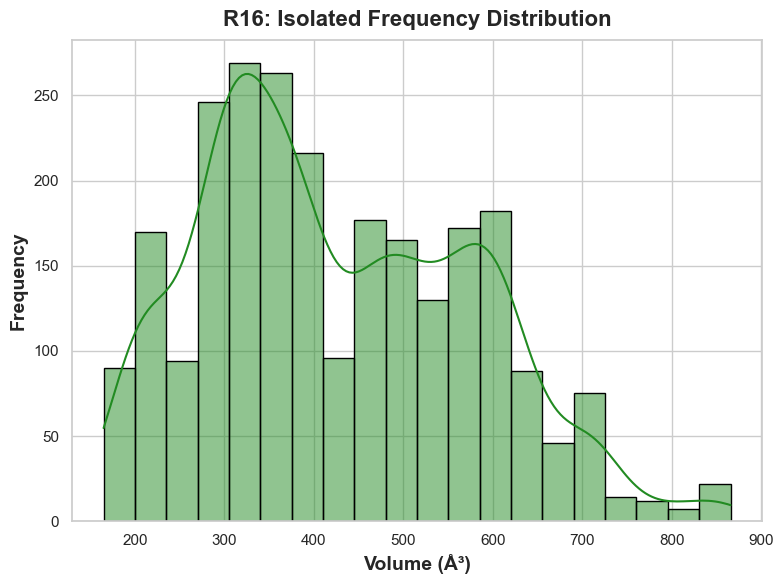

 -> Saved: Volume_Isolated_Box_R16.png


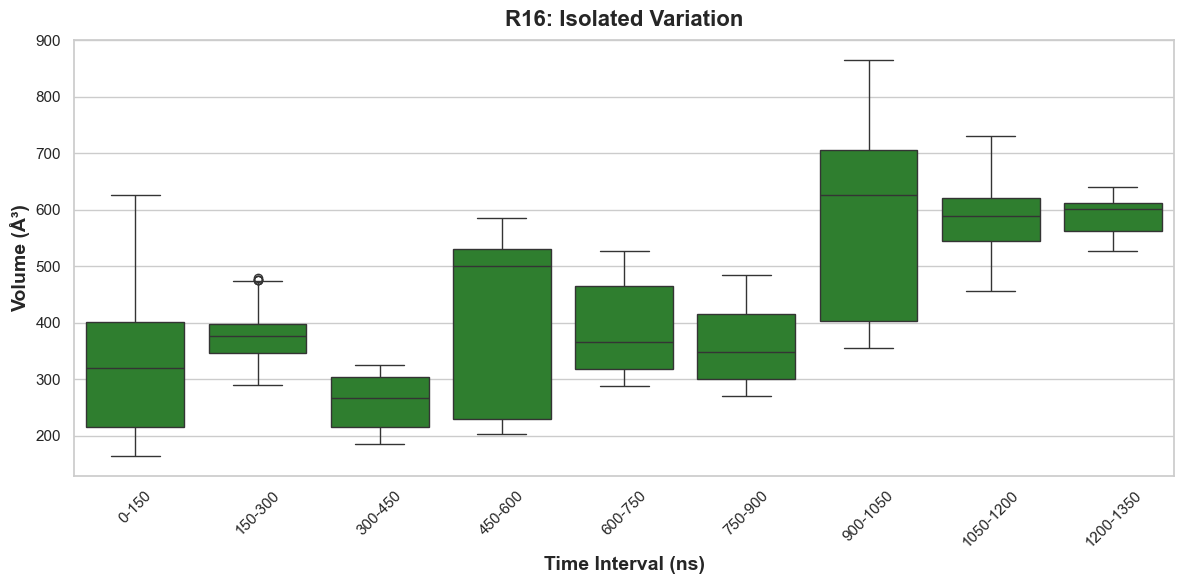

 -> Saved: Volume_Composite_A17.png


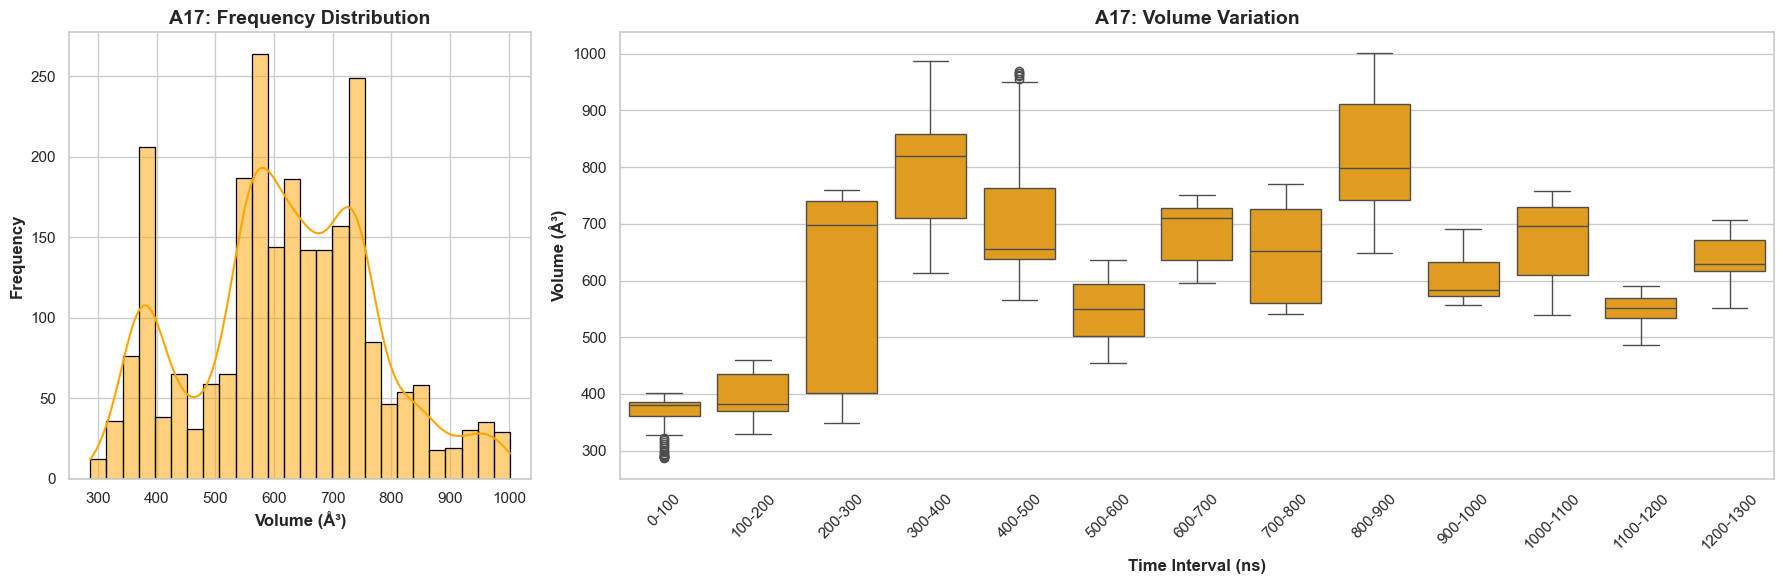

 -> Saved: Volume_Isolated_Hist_A17.png


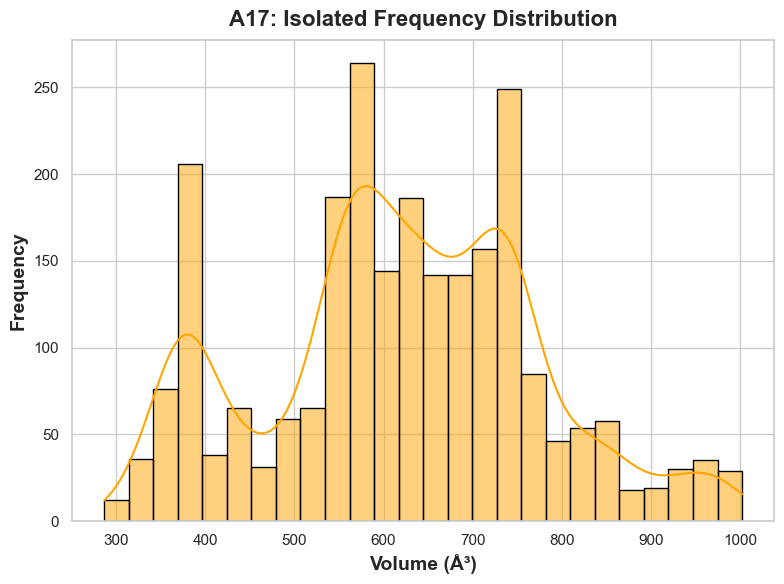

 -> Saved: Volume_Isolated_Box_A17.png


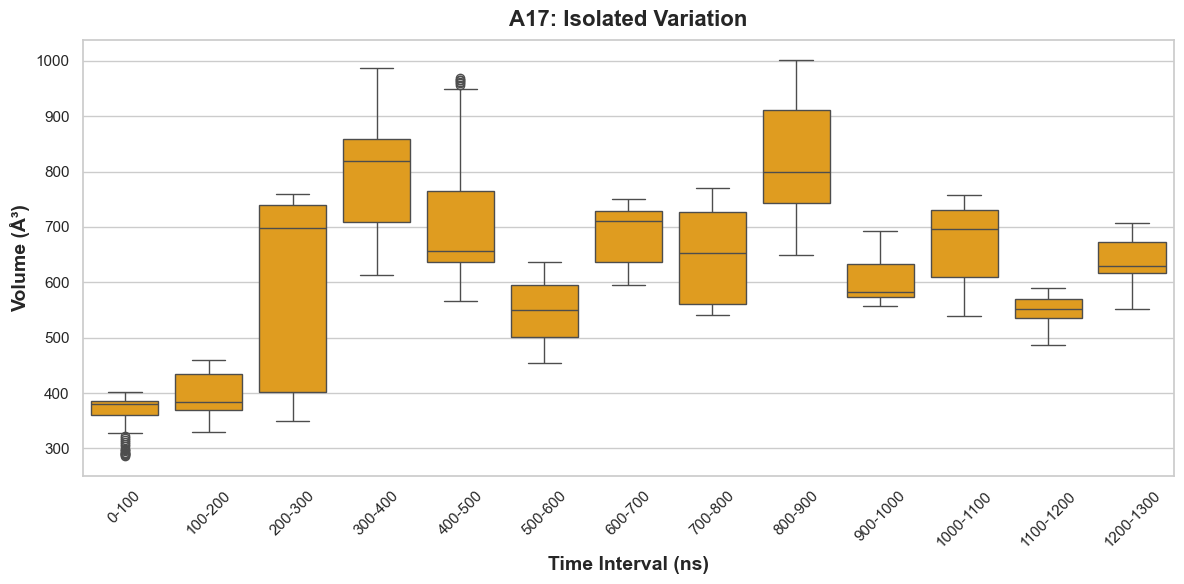

 -> Saved: Volume_Grid_Boxplots.png


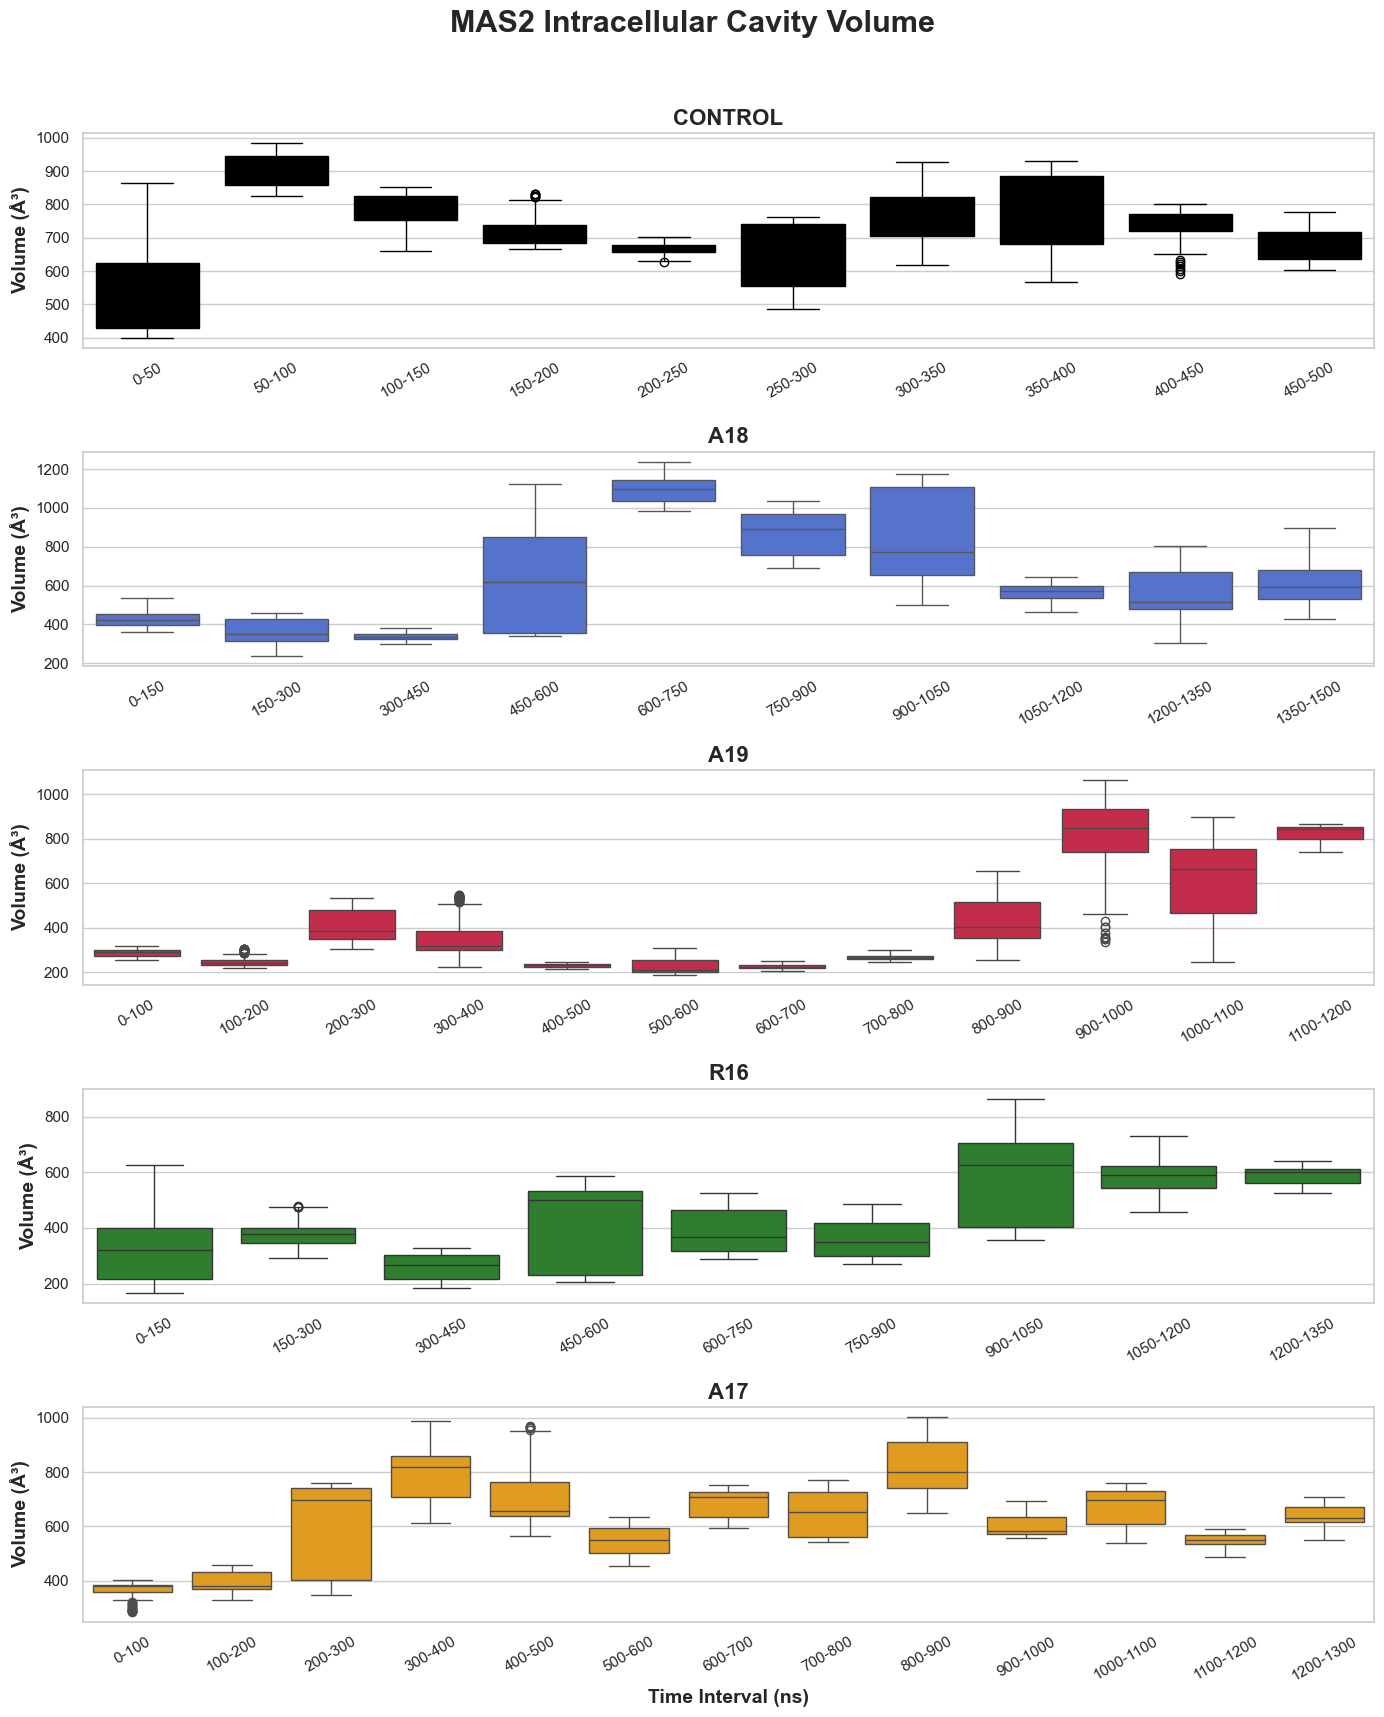

 -> Saved: Volume_Grid_Histograms.png


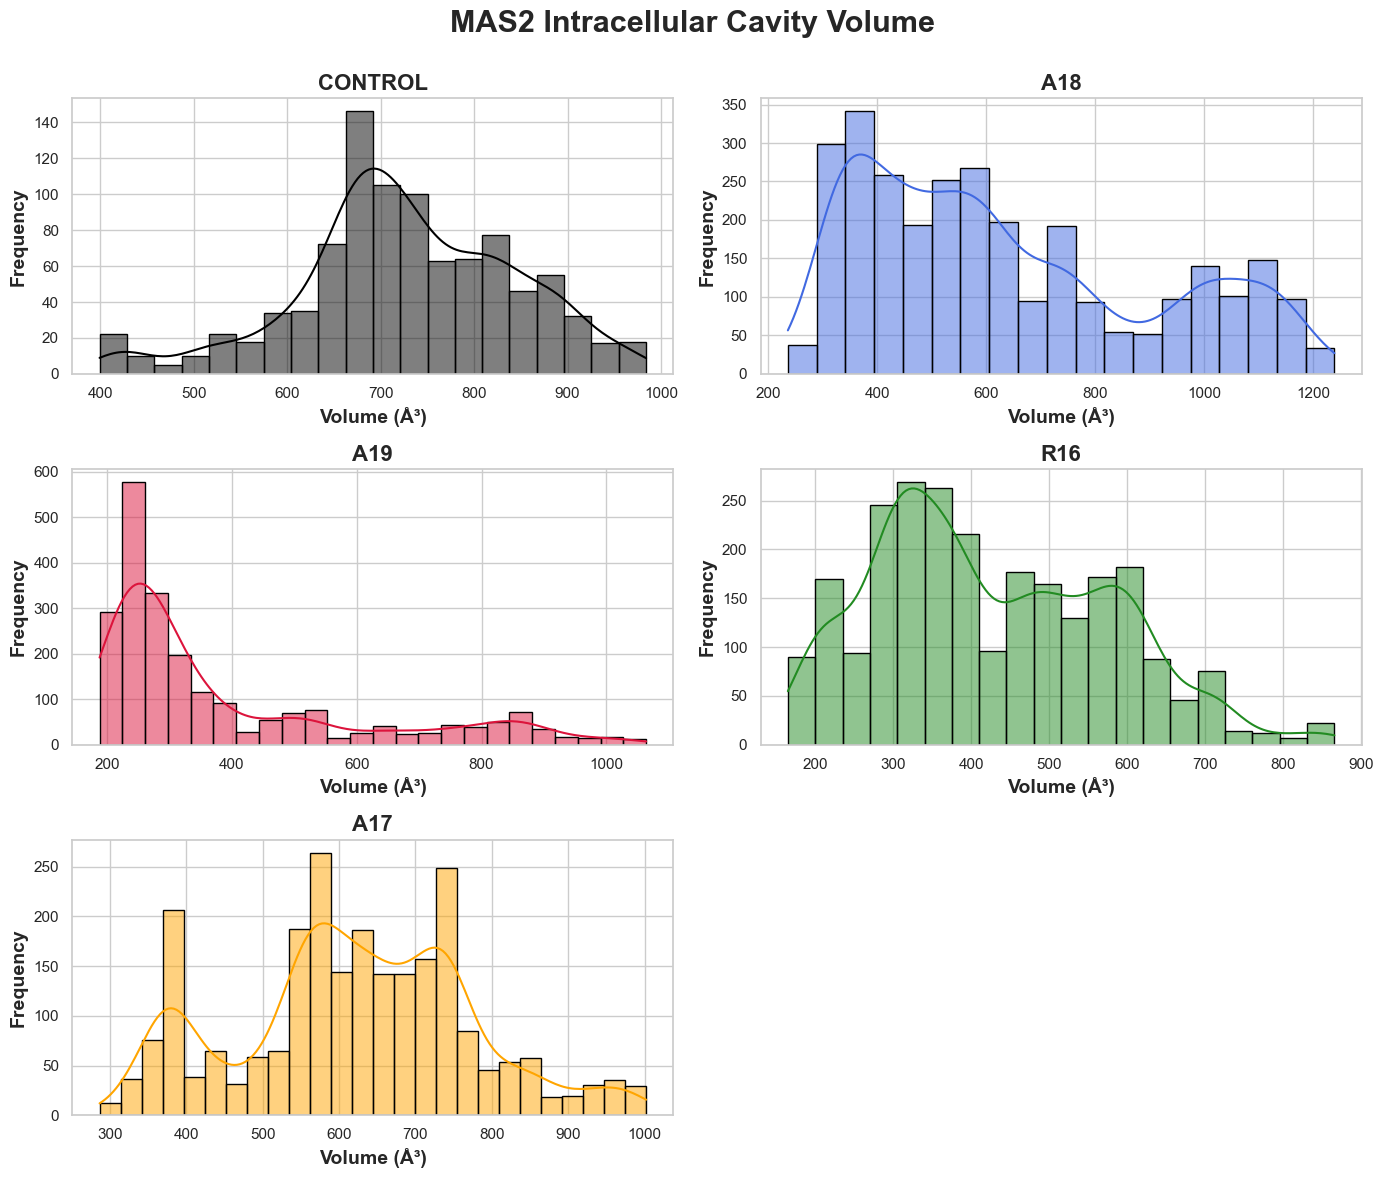


All Volume analysis grids and plots generated successfully.


In [47]:
# Cell 7: Volume Distributions, Isolated Plots, and Dynamic Composite Grids
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Generating Volume Distributions and Grids...\n")

target_bins = 10  # Optimal readability
n_systems = len(systems_to_show)

# Prep data for global plotting
df_melted = df_vol_master.melt(
    id_vars='Time_ns', 
    value_vars=[s for s in systems_to_show if s in df_vol_master.columns], 
    var_name='System', 
    value_name='Volume'
).dropna()

# ==============================================================================
# --- 1. Global Boxplot ---
# ==============================================================================
fig_comp, ax_comp = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df_melted, x='System', y='Volume', palette=system_colors, ax=ax_comp)

ax_comp.set_title("Overall Intracellular Cavity Volume Distribution", fontsize=16, fontweight='bold', pad=15)
ax_comp.set_xlabel("System", fontsize=14, fontweight='bold')
ax_comp.set_ylabel("Volume (Å³)", fontsize=14, fontweight='bold')
plt.tight_layout()
save_and_show(fig_comp, out_base_vol_global_box)

# ==============================================================================
# --- 2. Per-System Plots (Composite 1x2 and Isolated) ---
# ==============================================================================
for system in systems_to_show:
    if system not in df_vol_master.columns: continue
    
    sys_data = df_vol_master[['Time_ns', system]].dropna().copy()
    if sys_data.empty: continue

    # Dynamic Interval Calculation
    max_time = sys_data['Time_ns'].max()
    raw_interval = max_time / target_bins
    time_interval_ns = max(50, int(round(raw_interval / 50.0) * 50.0))
    
    bins = np.arange(0, max_time + time_interval_ns, time_interval_ns)
    labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]
    sys_data['Time_Bin'] = pd.cut(sys_data['Time_ns'], bins=bins, labels=labels, include_lowest=True)
    
    # PLOT A: Composite Figure (1x2)
    fig_sys, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(18, 6), gridspec_kw={'width_ratios': [1, 2.5]})
    sns.histplot(sys_data[system], kde=True, color=system_colors[system], ax=ax_hist, edgecolor='black')
    ax_hist.set_title(f"{system}: Frequency Distribution", fontsize=14, fontweight='bold')
    ax_hist.set_xlabel("Volume (Å³)", fontsize=12, fontweight='bold')
    ax_hist.set_ylabel("Frequency", fontsize=12, fontweight='bold')
    
    sns.boxplot(data=sys_data, x='Time_Bin', y=system, color=system_colors[system], ax=ax_box)
    ax_box.set_title(f"{system}: Volume Variation", fontsize=14, fontweight='bold')
    ax_box.set_xlabel("Time Interval (ns)", fontsize=12, fontweight='bold')
    ax_box.set_ylabel("Volume (Å³)", fontsize=12, fontweight='bold')
    ax_box.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    save_and_show(fig_sys, out_base_vol_composite[system])

    # PLOT B: Isolated Histogram
    fig_iso_h, ax_iso_h = plt.subplots(figsize=(8, 6))
    sns.histplot(sys_data[system], kde=True, color=system_colors[system], ax=ax_iso_h, edgecolor='black')
    ax_iso_h.set_title(f"{system}: Isolated Frequency Distribution", fontsize=16, fontweight='bold', pad=10)
    ax_iso_h.set_xlabel("Volume (Å³)", fontsize=14, fontweight='bold')
    ax_iso_h.set_ylabel("Frequency", fontsize=14, fontweight='bold')
    plt.tight_layout()
    save_and_show(fig_iso_h, out_base_vol_hist_iso[system])

    # PLOT C: Isolated Time-Binned Boxplot
    fig_iso_b, ax_iso_b = plt.subplots(figsize=(12, 6))
    sns.boxplot(data=sys_data, x='Time_Bin', y=system, color=system_colors[system], ax=ax_iso_b)
    ax_iso_b.set_title(f"{system}: Isolated Variation", fontsize=16, fontweight='bold', pad=10)
    ax_iso_b.set_xlabel("Time Interval (ns)", fontsize=14, fontweight='bold')
    ax_iso_b.set_ylabel("Volume (Å³)", fontsize=14, fontweight='bold')
    ax_iso_b.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    save_and_show(fig_iso_b, out_base_vol_box_iso[system])

# ==============================================================================
# --- 3. Dynamic Interval Boxplot Grid ---
# ==============================================================================
box_fig_height = max(10, n_systems * 3.5)
fig_grid_box, axes_box = plt.subplots(nrows=n_systems, ncols=1, figsize=(14, box_fig_height))
fig_grid_box.suptitle(f'{systemid} Intracellular Cavity Volume', fontsize=22, fontweight='bold', y=0.98)

# Ensure axes_box is iterable even if there's only 1 system
if n_systems == 1:
    axes_box = [axes_box]

for idx, system in enumerate(systems_to_show):
    ax = axes_box[idx]
    if system not in df_vol_master.columns:
        ax.set_visible(False)
        continue
        
    sys_data = df_vol_master[['Time_ns', system]].dropna().copy()
    if sys_data.empty:
        ax.set_visible(False)
        continue

    max_time = sys_data['Time_ns'].max()
    raw_interval = max_time / target_bins
    time_interval_ns = max(50, int(round(raw_interval / 50.0) * 50.0))
    
    bins = np.arange(0, max_time + time_interval_ns, time_interval_ns)
    labels = [f"{int(bins[i])}-{int(bins[i+1])}" for i in range(len(bins)-1)]
    sys_data['Time_Bin'] = pd.cut(sys_data['Time_ns'], bins=bins, labels=labels, include_lowest=True)
    
    sns.boxplot(data=sys_data, x='Time_Bin', y=system, color=system_colors[system], ax=ax)
    
    ax.set_title(system, fontsize=16, fontweight='bold')
    ax.set_ylabel("Volume (Å³)", fontsize=14, fontweight='bold')
    
    is_last_plot = (idx == n_systems - 1)
    ax.set_xlabel("Time Interval (ns)" if is_last_plot else "", fontsize=14, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout(rect=[0, 0, 1, 0.96])
save_and_show(fig_grid_box, out_base_vol_grid_box)

# ==============================================================================
# --- 4. Dynamic Histogram Grid ---
# ==============================================================================
n_cols = 2
n_rows = math.ceil(n_systems / n_cols)
hist_fig_height = max(6, n_rows * 4)

fig_grid_hist, axes_hist = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(14, hist_fig_height))
fig_grid_hist.suptitle(f'{systemid} Intracellular Cavity Volume', fontsize=22, fontweight='bold', y=0.98)

axes_hist_flat = axes_hist.flatten() if n_systems > 1 else [axes_hist]

for idx, ax in enumerate(axes_hist_flat):
    if idx >= n_systems:
        ax.set_visible(False)
        continue
        
    system = systems_to_show[idx]
    if system not in df_vol_master.columns:
        ax.set_visible(False)
        continue
        
    sys_data = df_vol_master[['Time_ns', system]].dropna().copy()
    if sys_data.empty:
        ax.set_visible(False)
        continue
        
    sns.histplot(sys_data[system], kde=True, color=system_colors[system], ax=ax, edgecolor='black')
    
    ax.set_title(system, fontsize=16, fontweight='bold')
    ax.set_xlabel("Volume (Å³)", fontsize=14, fontweight='bold')
    ax.set_ylabel("Frequency", fontsize=14, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.98])
save_and_show(fig_grid_hist, out_base_vol_grid_hist)

print("\nAll Volume analysis grids and plots generated successfully.")

# Interactions

## Bar plots

In [19]:
# Cell 1: Aggregate Intramolecular Interaction Data
general_folder_path = f'{systemid}/DATA'

system_colors = {
    "CONTROL": "black",
    "A18": "royalblue",
    "A19": "crimson",
    "R16": "forestgreen",
    "A17": "orange"
}

sys_cols = list(system_colors.keys())
intra_files = {}

print(f"Scanning '{general_folder_path}' for Detailed Intra Edges...\n")

for system in sys_cols:
    # Dynamically search for the Detailed Intra Edges CSV
    search_pattern = os.path.join(general_folder_path, system, "*_Detailed_Intra_Edges*.csv")
    found_files = glob.glob(search_pattern)
    
    if found_files:
        intra_files[system] = found_files[0]
        print(f" [Found] {system}: '{os.path.basename(found_files[0])}'")
    else:
        print(f" [Missing] {system}: No file found.")

# --- Aggregate the Data ---
agg_data_list = []

for sys, filepath in intra_files.items():
    df = pd.read_csv(filepath)
    
    if 'Interaction_Type' in df.columns and 'Frequency_%' in df.columns:
        # Group by Interaction Type and sum the frequencies
        summary = df.groupby('Interaction_Type')['Frequency_%'].sum().reset_index()
        
        # Divide by 100 to get the actual "Average Number of Concurrent Bonds"
        summary['Avg_Concurrent_Bonds'] = summary['Frequency_%'] / 100.0
        summary['System'] = sys
        
        agg_data_list.append(summary[['System', 'Interaction_Type', 'Avg_Concurrent_Bonds']])

# Create master dataframe and pivot it for the stacked bar chart
df_intra_agg = pd.concat(agg_data_list, ignore_index=True)

# Pivot: Rows = Systems, Columns = Interaction Types
df_pivot_intra = df_intra_agg.pivot(index='System', columns='Interaction_Type', values='Avg_Concurrent_Bonds').fillna(0)

# Reorder the rows so they perfectly match your preferred CONTROL -> Mutants order
df_pivot_intra = df_pivot_intra.reindex([s for s in sys_cols if s in df_pivot_intra.index])

print("\n--- Aggregated Interaction Data (Average Concurrent Bonds) ---")
display(df_pivot_intra.round(1))

Scanning 'AT1R/DATA' for Detailed Intra Edges...

 [Found] CONTROL: 'CONTROL_Detailed_Intra_Edges.csv'
 [Found] A18: 'A18_Detailed_Intra_Edges.csv'
 [Found] A19: 'A19_Detailed_Intra_Edges.csv'
 [Found] R16: 'R16_Detailed_Intra_Edges.csv'

--- Aggregated Interaction Data (Average Concurrent Bonds) ---


Interaction_Type,Anionic,CationPi,Cationic,EdgeToFace,FaceToFace,HBAcceptor,HBDonor,PiStacking,VdWContact
System,,,,,,,,,
CONTROL,7.1,1.2,7.1,7.9,2.0,265.6,265.6,9.9,1646.2
A18,7.1,1.4,7.1,6.8,2.1,264.3,264.3,8.9,1639.2
A19,7.7,1.1,7.7,7.8,1.0,260.4,260.4,8.8,1639.8
R16,7.3,1.1,7.3,7.9,2.6,265.0,265.0,10.6,1637.5


Generating Intramolecular Interactions Stacked Bar Chart...

 -> Table Saved: AT1R/DATA/Intra_Interactions_Stacked_Data.csv
 -> Plots Saved: AT1R/DATA/Intra_Interactions_StackedBar.png | .pdf


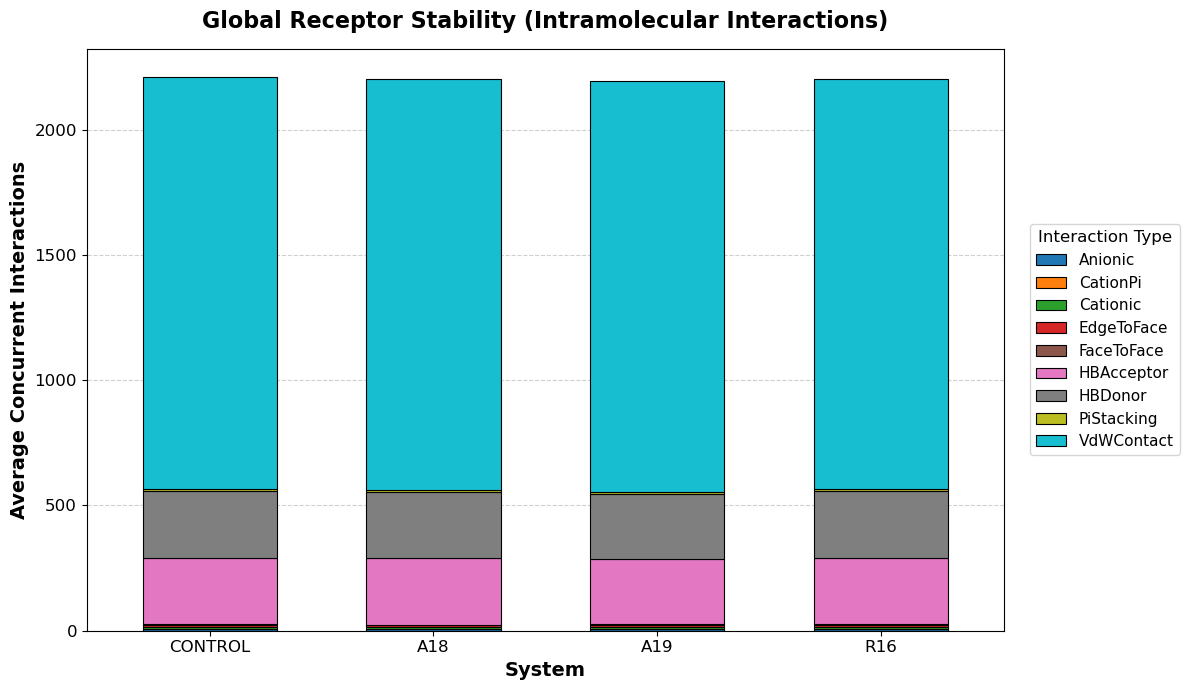

In [20]:
# Cell 2: Plotting and Exporting Intramolecular Stacked Bar Chart
import matplotlib.pyplot as plt
import os

print("Generating Intramolecular Interactions Stacked Bar Chart...")

# Define distinct, professional colors for the interactions using Matplotlib's 'tab20' colormap
fig_intra, ax_intra = plt.subplots(figsize=(12, 7))

# Plot the stacked bar chart
df_pivot_intra.plot(kind='bar', stacked=True, ax=ax_intra, colormap='tab10', width=0.6, edgecolor='black', linewidth=0.8)

# --- Styling and Formatting ---
ax_intra.set_title("Global Receptor Stability (Intramolecular Interactions)", fontsize=16, fontweight='bold', pad=15)
ax_intra.set_xlabel("System", fontsize=14, fontweight='bold')
ax_intra.set_ylabel("Average Concurrent Interactions", fontsize=14, fontweight='bold')

# Keep system names horizontal for readability
ax_intra.tick_params(axis='x', labelrotation=0, labelsize=12)
ax_intra.tick_params(axis='y', labelsize=12)

# Move the legend outside the plot so it doesn't cover any bars
ax_intra.legend(title="Interaction Type", title_fontsize='12', fontsize='11', 
                loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True)

# Add a subtle background grid for the y-axis
ax_intra.yaxis.grid(True, linestyle='--', alpha=0.6)
ax_intra.set_axisbelow(True)

plt.tight_layout()

# --- Saving the Outputs ---
fn_intra_agg_csv = os.path.join(general_folder_path, "Intra_Interactions_Stacked_Data.csv")
fn_intra_bar_png = os.path.join(general_folder_path, "Intra_Interactions_StackedBar.png")
fn_intra_bar_pdf = os.path.join(general_folder_path, "Intra_Interactions_StackedBar.pdf")

df_pivot_intra.to_csv(fn_intra_agg_csv)
fig_intra.savefig(fn_intra_bar_png, dpi=600, bbox_inches='tight')
fig_intra.savefig(fn_intra_bar_pdf, bbox_inches='tight')

print(f"\n -> Table Saved: {fn_intra_agg_csv}")
print(f" -> Plots Saved: {fn_intra_bar_png} | .pdf")

Generating detailed 100% relative per-residue interaction profiles...



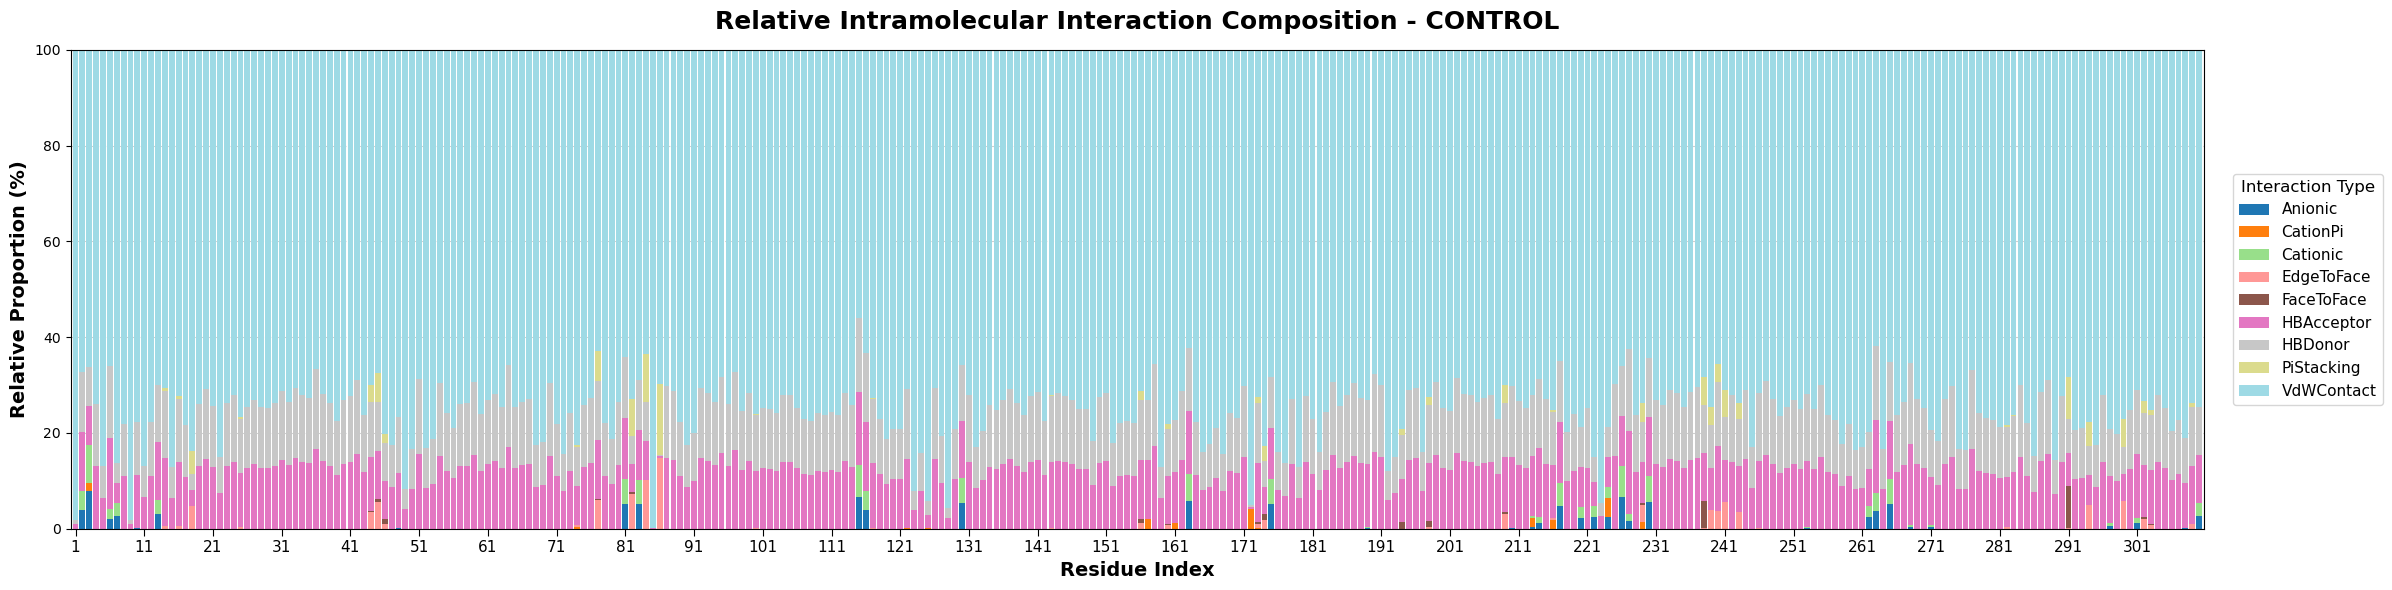

 -> Processed CONTROL successfully. Saved inside CONTROL/ folder.


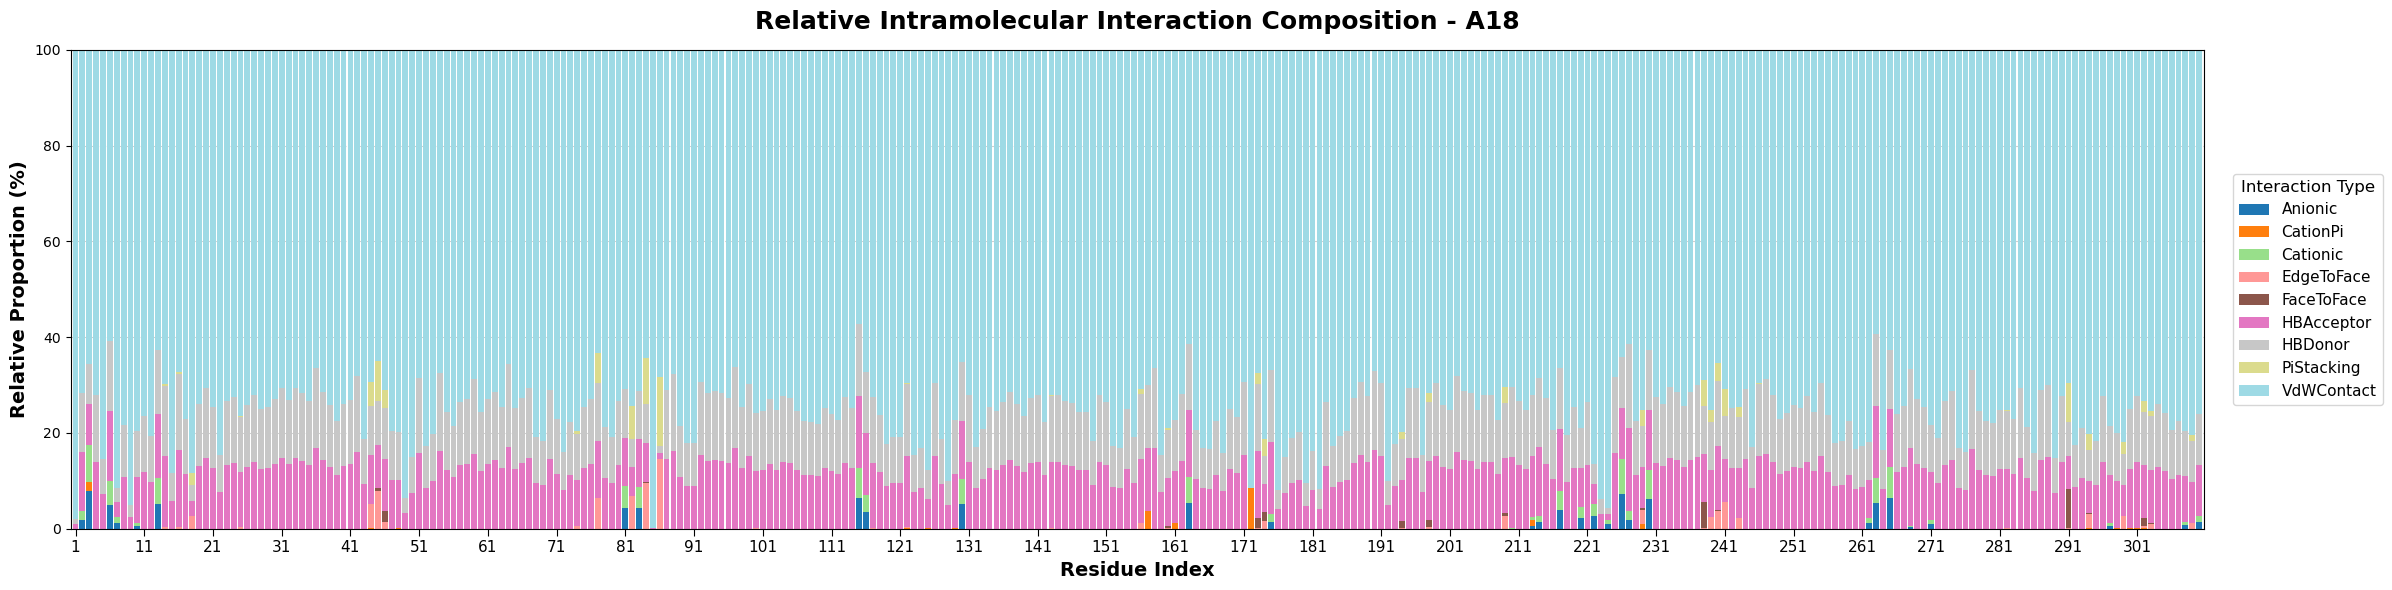

 -> Processed A18 successfully. Saved inside A18/ folder.


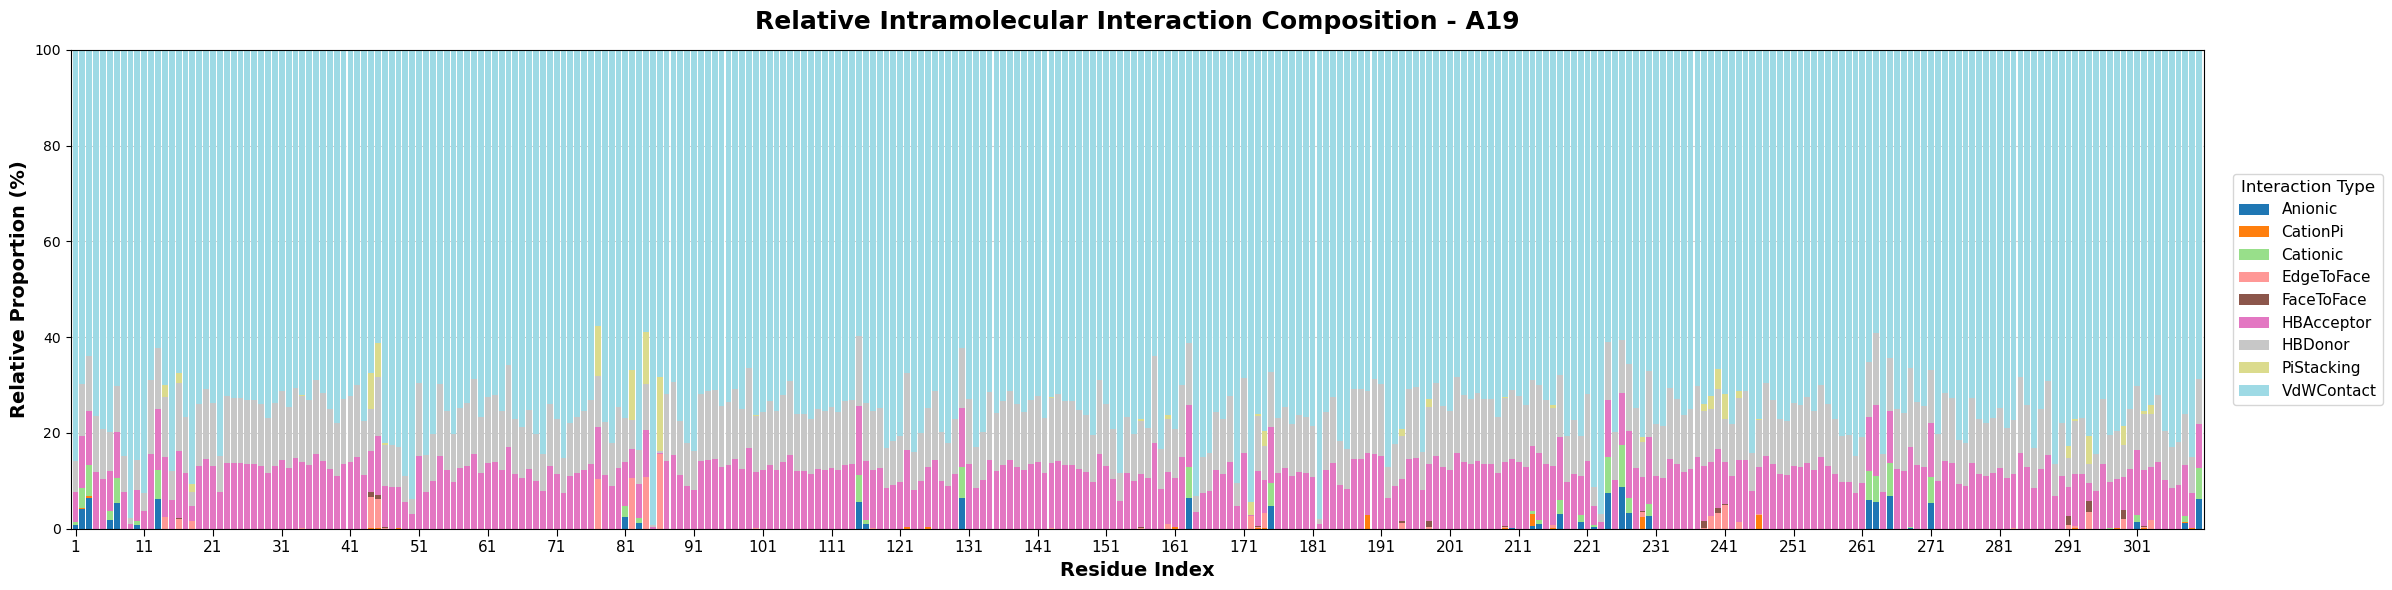

 -> Processed A19 successfully. Saved inside A19/ folder.


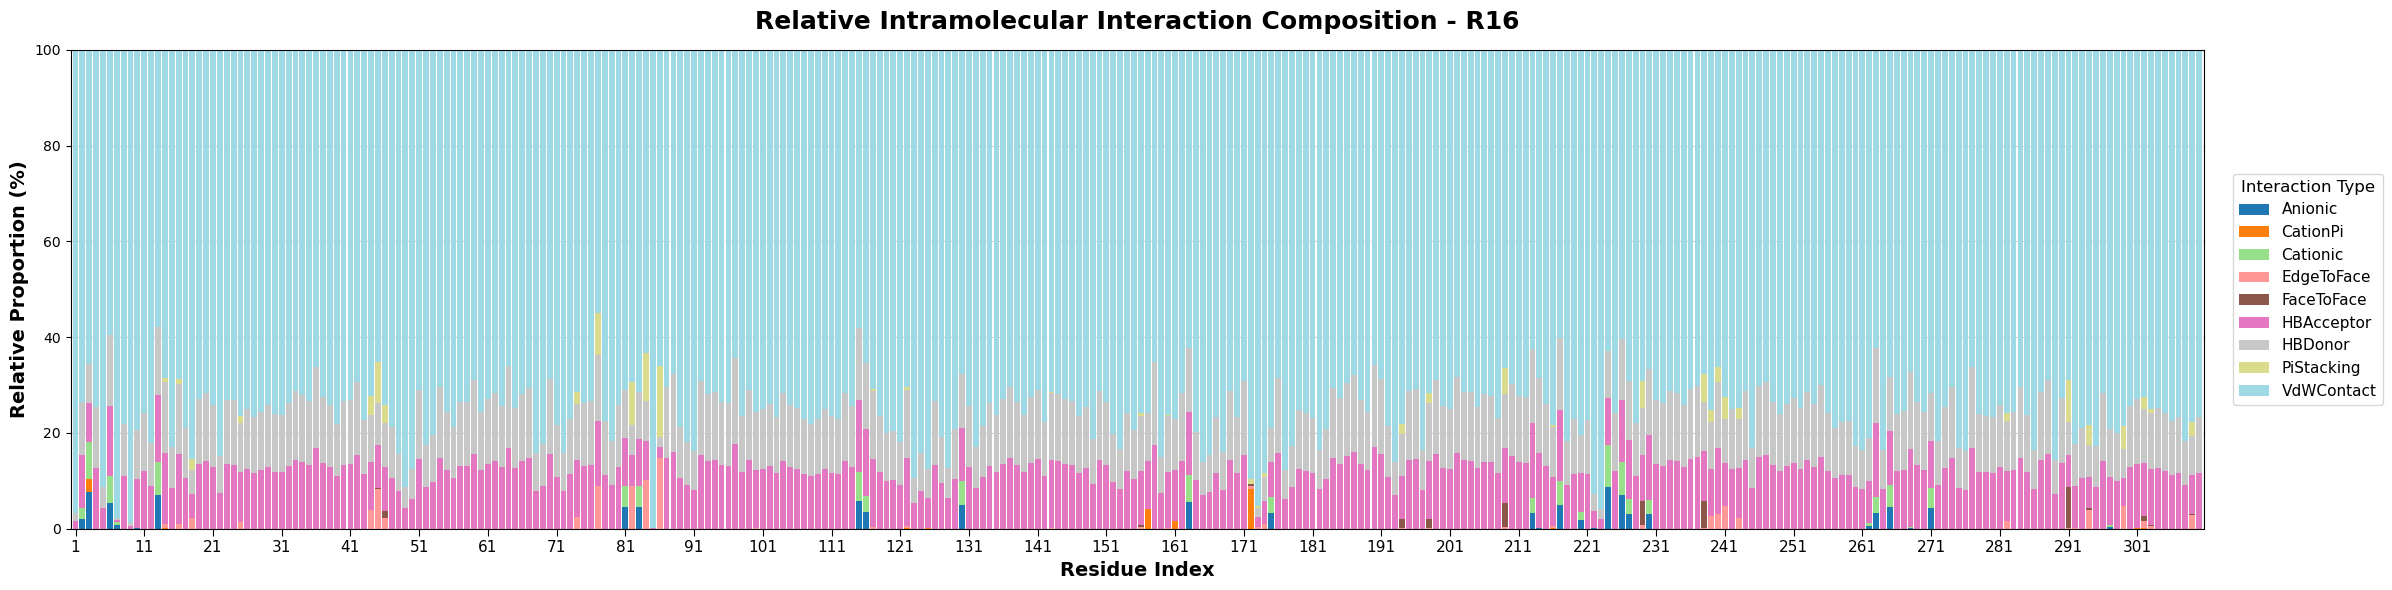

 -> Processed R16 successfully. Saved inside R16/ folder.

All 100% relative per-residue profiles generated and saved!


In [23]:
# Cell 3: Per-Residue Interaction Profiling (100% Stacked Relative Composition)
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

general_folder_path = f'{systemid}/DATA'
sys_cols = ["CONTROL", "A18", "A19", "R16"]

print("Generating detailed 100% relative per-residue interaction profiles...\n")

for system in sys_cols:
    search_pattern = os.path.join(general_folder_path, system, "*_Detailed_Intra_Edges*.csv")
    found_files = glob.glob(search_pattern)
    
    if not found_files:
        print(f" [Missing] No detailed edge file found for {system}. Skipping.")
        continue
        
    filepath = found_files[0]
    df = pd.read_csv(filepath)
    
    if 'Interaction_Type' not in df.columns or 'Frequency_%' not in df.columns:
        print(f" [Error] Missing required columns in {system} file. Skipping.")
        continue

    # --- 1. Data Processing ---
    # Since an edge connects two residues, both residues receive the interaction frequency
    df_res1 = df[['Res1_Num', 'Interaction_Type', 'Frequency_%']].rename(columns={'Res1_Num': 'Residue'})
    df_res2 = df[['Res2_Num', 'Interaction_Type', 'Frequency_%']].rename(columns={'Res2_Num': 'Residue'})
    
    # Combine them into a single long list of interactions
    df_combined = pd.concat([df_res1, df_res2])
    
    # Clean up residue IDs to ensure they are strict integers
    df_combined['Residue'] = pd.to_numeric(df_combined['Residue'], errors='coerce')
    df_combined = df_combined.dropna(subset=['Residue'])
    df_combined['Residue'] = df_combined['Residue'].astype(int)
    
    # Sum the absolute frequencies for each Interaction Type, per Residue
    df_grouped = df_combined.groupby(['Residue', 'Interaction_Type'])['Frequency_%'].sum().reset_index()
    
    # Pivot the table so Interaction Types become the columns
    df_pivot = df_grouped.pivot(index='Residue', columns='Interaction_Type', values='Frequency_%').fillna(0)
    
    # Force the X-axis to include every residue from 1 to 310
    max_res = int(df_combined['Residue'].max())
    full_range = range(1, max(311, max_res + 1))
    df_pivot = df_pivot.reindex(full_range, fill_value=0)

    # --- NEW: Convert to 100% Relative Composition ---
    # Calculate the total interaction frequency for each residue
    total_freq = df_pivot.sum(axis=1)
    
    # Divide each row by its total. If total is 0, it results in NaN, so we fillna(0)
    df_pivot_100 = df_pivot.div(total_freq, axis=0).fillna(0) * 100

    # --- 2. Plotting ---
    # Using a very wide figure so all 310 bars are clear and readable
    fig, ax = plt.subplots(figsize=(24, 6))
    
    # Draw the 100% stacked bars
    df_pivot_100.plot(kind='bar', stacked=True, ax=ax, colormap='tab20', width=0.85, edgecolor='none')

    # Formatting axes
    ax.set_title(f"Relative Intramolecular Interaction Composition - {system}", fontsize=18, fontweight='bold', pad=15)
    ax.set_xlabel("Residue Index", fontsize=14, fontweight='bold')
    ax.set_ylabel("Relative Proportion (%)", fontsize=14, fontweight='bold')

    # Strictly lock the Y-axis to 100% for perfect visual alignment
    ax.set_ylim(0, 100)

    # Fix the X-axis ticks (Show a label every 10 residues)
    tick_positions = np.arange(0, len(full_range), 10)
    tick_labels = [full_range[i] for i in tick_positions]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=0, fontsize=11)
    ax.tick_params(axis='x', which='major', bottom=True, length=5, color='black')

    # Move legend outside the plot area
    ax.legend(title="Interaction Type", fontsize='11', title_fontsize='12', 
              loc='center left', bbox_to_anchor=(1.01, 0.5), frameon=True)

    # Add a horizontal grid (at 20%, 40%, etc. due to the 0-100 limit)
    ax.yaxis.grid(True, linestyle='--', alpha=0.6)
    ax.set_axisbelow(True)

    plt.tight_layout()

    # --- 3. Save to System Folders ---
    out_csv = os.path.join(general_folder_path, system, f"{system}_PerResidue_Relative_Interactions.csv")
    out_png = os.path.join(general_folder_path, system, f"{system}_PerResidue_Relative_Interactions.png")
    out_pdf = os.path.join(general_folder_path, system, f"{system}_PerResidue_Relative_Interactions.pdf")
    
    os.makedirs(os.path.dirname(out_csv), exist_ok=True)
    
    df_pivot_100.to_csv(out_csv)
    fig.savefig(out_png, dpi=600, bbox_inches='tight')
    fig.savefig(out_pdf, bbox_inches='tight')
    
    # Close the figure after saving to prevent memory leaks
    plt.show()
    print(f" -> Processed {system} successfully. Saved inside {system}/ folder.")

print("\nAll 100% relative per-residue profiles generated and saved!")

Processing grouped interaction data and calculating differentials vs CONTROL...



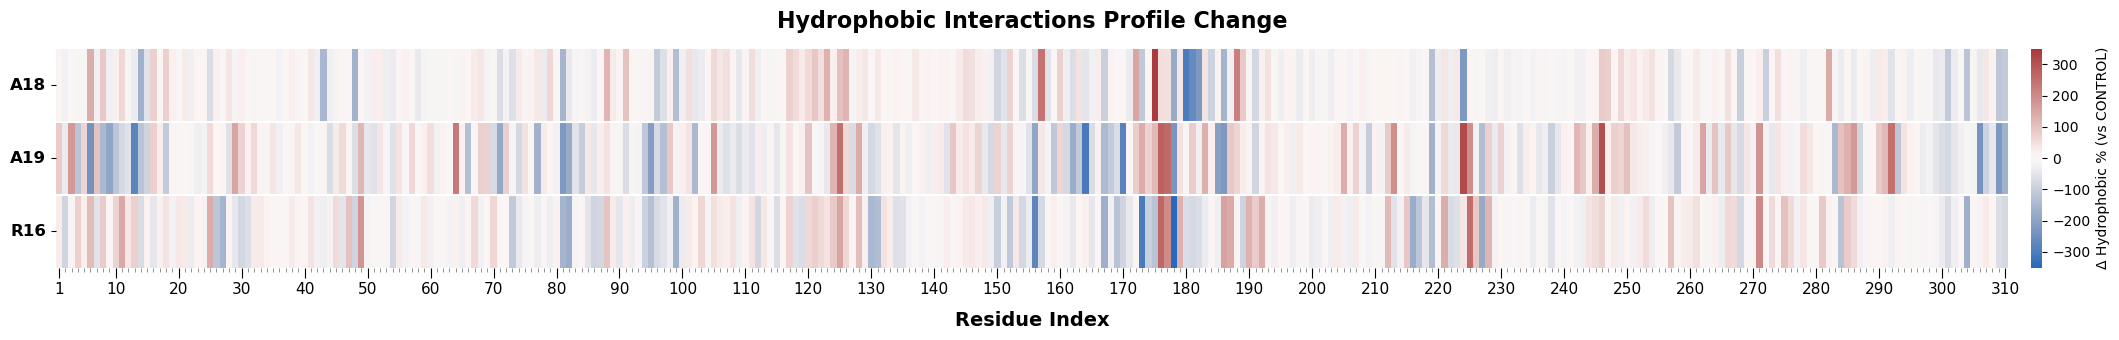

 -> Generated and saved: AT1R/DATA/Diff_Hydrophobic_Heatmap_Full.png



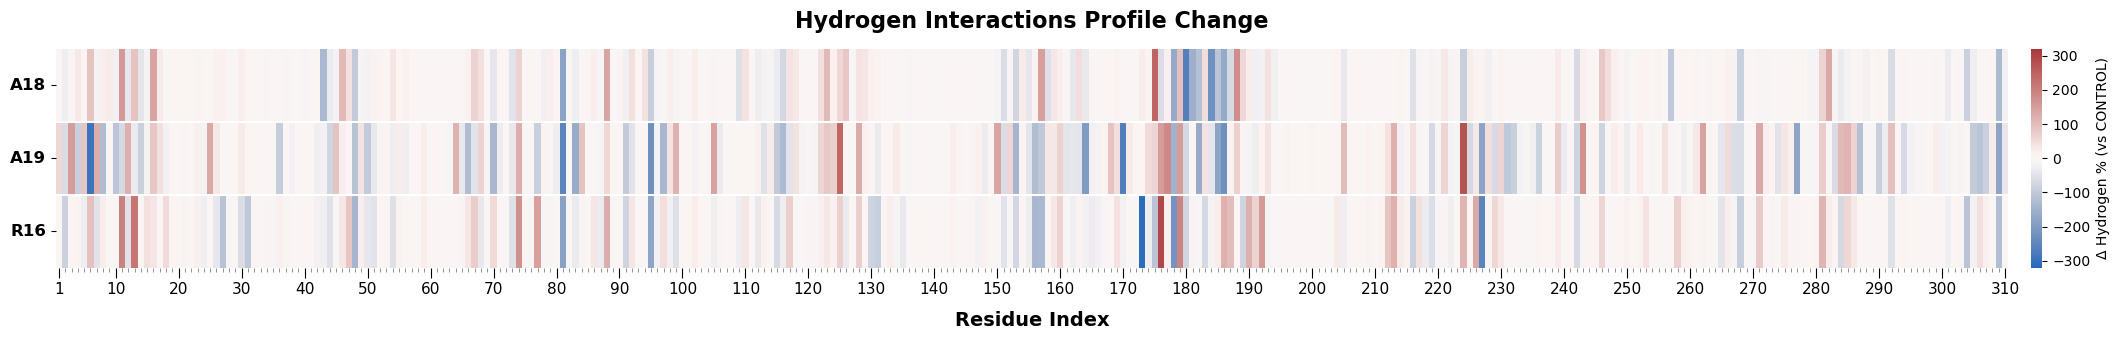

 -> Generated and saved: AT1R/DATA/Diff_Hydrogen_Heatmap_Full.png

No data found for Salt Bridges interactions. Skipping.


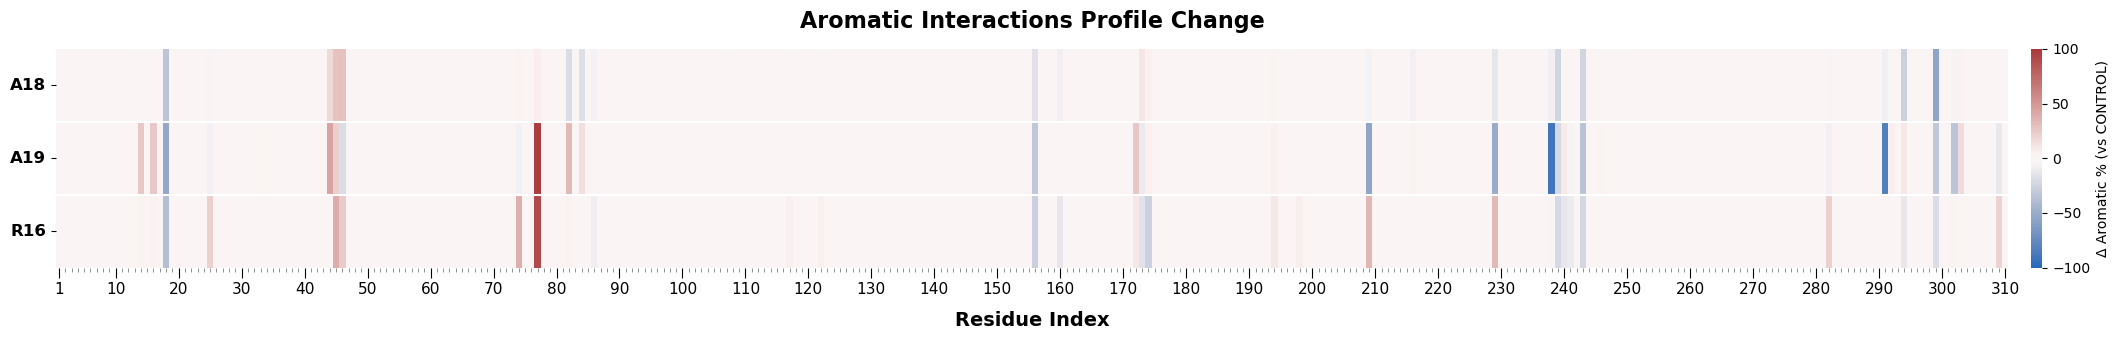

 -> Generated and saved: AT1R/DATA/Diff_Aromatic_Heatmap_Full.png

All grouped interaction differentials completed successfully!


In [29]:
# Cell 4: Grouped Interaction Differential Heatmaps (Full Sequence vs CONTROL)
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

general_folder_path = f'{systemid}/DATA'
sys_cols = ["CONTROL", "A18", "A19", "R16"]
mutants = [sys for sys in sys_cols if sys != "CONTROL"]

# --- 1. Define the Interaction Grouping Mapping ---
interaction_mapping = {
    'VdWContact': 'Hydrophobic',
    'Hydrophobic': 'Hydrophobic',
    'HBDonor': 'Hydrogen',
    'HBAcceptor': 'Hydrogen',
    'HydrogenBond': 'Hydrogen',
    'SaltBridge': 'Salt Bridges',
    'FaceToFace': 'Aromatic',
    'EdgeToFace': 'Aromatic',
    'pi-Stacking': 'Aromatic',
    'pi-Cation': 'Aromatic',
    'Cation-pi': 'Aromatic'
}
groups = ["Hydrophobic", "Hydrogen", "Salt Bridges", "Aromatic"]

print("Processing grouped interaction data and calculating differentials vs CONTROL...\n")

res_data = {g: {s: pd.Series(dtype=float) for s in sys_cols} for g in groups}

# --- 2. Load, Process, and Group Data ---
for system in sys_cols:
    search_pattern = os.path.join(general_folder_path, system, "*_Detailed_Intra_Edges*.csv")
    found_files = glob.glob(search_pattern)
    if not found_files: continue
    
    df = pd.read_csv(found_files[0])
    if 'Interaction_Type' not in df.columns or 'Frequency_%' not in df.columns: continue
    
    df_res1 = df[['Res1_Num', 'Interaction_Type', 'Frequency_%']].rename(columns={'Res1_Num': 'Residue'})
    df_res2 = df[['Res2_Num', 'Interaction_Type', 'Frequency_%']].rename(columns={'Res2_Num': 'Residue'})
    df_combined = pd.concat([df_res1, df_res2])
    
    df_combined['Residue'] = pd.to_numeric(df_combined['Residue'], errors='coerce')
    df_combined = df_combined.dropna(subset=['Residue'])
    df_combined['Residue'] = df_combined['Residue'].astype(int)
    
    df_combined['Group'] = df_combined['Interaction_Type'].map(interaction_mapping).fillna('Other')
    df_filtered = df_combined[df_combined['Group'].isin(groups)]
    
    grouped = df_filtered.groupby(['Residue', 'Group'])['Frequency_%'].sum().reset_index()
    
    for g in groups:
        g_data = grouped[grouped['Group'] == g].set_index('Residue')['Frequency_%']
        res_data[g][system] = g_data

# --- 3. Calculate Differentials and Plot ---
for g in groups:
    df_g = pd.DataFrame(res_data[g]).fillna(0)
    if df_g.empty:
        print(f"No data found for {g} interactions. Skipping.")
        continue
        
    # Force the data to span from Residue 1 to 310 (or whatever the max is)
    max_res = max(310, int(df_g.index.max()) if not df_g.empty else 310)
    df_g = df_g.reindex(range(1, max_res + 1), fill_value=0)
    
    df_diff = pd.DataFrame(index=df_g.index)
    for mut in mutants:
        if mut in df_g.columns and "CONTROL" in df_g.columns:
            df_diff[mut] = df_g[mut] - df_g["CONTROL"]
            
    diff_heat = df_diff.T
    
    # Verify if there is ANY difference at all before plotting
    if diff_heat.abs().max().max() < 0.1:
        print(f"No significant structural shifts found for {g}. Skipping heatmap.\n")
        continue

    # ==========================================================
    # >> EDIT THESE VARIABLES TO CUSTOMIZE YOUR X-AXIS TICKS <<
    major_tick_interval = 10  # Numbers appear every 10 residues
    minor_tick_interval = 1   # Small tick lines every 1 residue
    # ==========================================================

    # Make the figure wide enough to cleanly display 310 columns
    fig, ax = plt.subplots(figsize=(24, 3.5))
    
    vmax_val = np.ceil(diff_heat.abs().max().max() / 10) * 10
    if vmax_val == 0: vmax_val = 10 
    
    # Draw Heatmap
    sns.heatmap(diff_heat, cmap='vlag', vmin=-vmax_val, vmax=vmax_val, center=0, 
                ax=ax, cbar_kws={'label': f'Δ {g} % (vs CONTROL)', 'pad': 0.01})
                
    for y in range(1, len(mutants)):
        ax.axhline(y=y, color='white', linewidth=1.5)
        
    # --- Apply Custom Ticks ---
    major_tick_positions, major_tick_labels, minor_tick_positions = [], [], []
    for i, res in enumerate(diff_heat.columns):
        center_pos = i + 0.5
        
        # Add minor ticks
        if res == 1 or res % minor_tick_interval == 0 or res == max_res:
            minor_tick_positions.append(center_pos)
            
        # Add major ticks and their labels
        if res == 1 or res % major_tick_interval == 0 or res == max_res:
            major_tick_positions.append(center_pos)
            major_tick_labels.append(int(res))
            
    ax.set_xticks(major_tick_positions)
    ax.set_xticklabels(major_tick_labels, rotation=0, fontsize=11)
    ax.tick_params(axis='x', which='major', bottom=True, length=7, color='black')
    
    ax.set_xticks(minor_tick_positions, minor=True)
    ax.tick_params(axis='x', which='minor', bottom=True, length=3, color='gray')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontweight='bold', fontsize=12)
    
    ax.set_title(f"{g} Interactions Profile Change", fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel("Residue Index", fontsize=14, fontweight='bold', labelpad=10)
    ax.set_ylabel("")
    
    plt.tight_layout()
    
    # --- Save outputs securely ---
    safe_name = g.replace(' ', '')
    out_png = os.path.join(general_folder_path, f"Diff_{safe_name}_Heatmap_Full.png")
    out_pdf = os.path.join(general_folder_path, f"Diff_{safe_name}_Heatmap_Full.pdf")
    fig.savefig(out_png, dpi=600, bbox_inches='tight')
    fig.savefig(out_pdf, bbox_inches='tight')
    
    plt.show()
    print(f" -> Generated and saved: {out_png}\n")

print("All grouped interaction differentials completed successfully!")

Scanning for highly localized changes in Aromatic interactions...



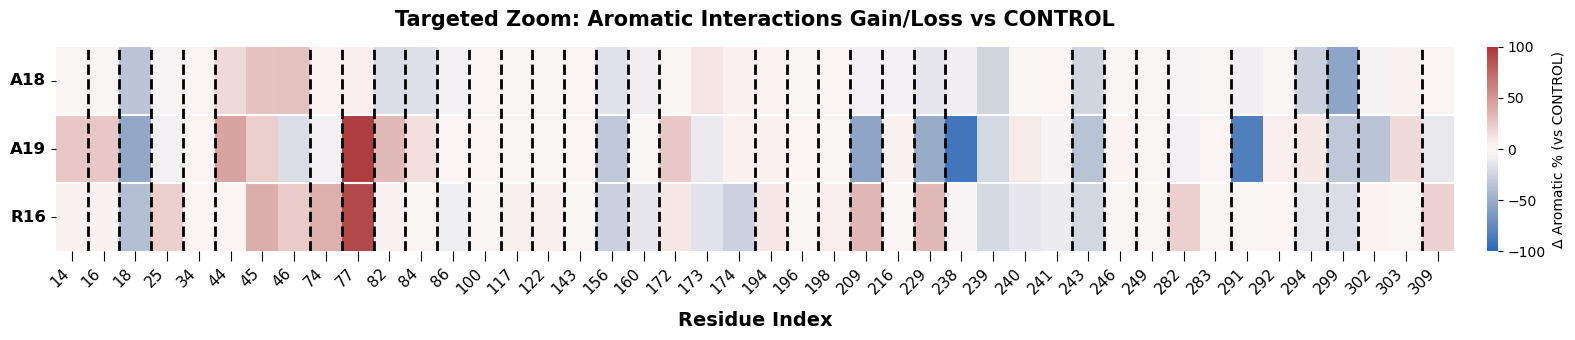

 -> Targeted plot saved to: AT1R/DATA/Diff_Aromatic_Targeted_Zoom.png


In [32]:
# Cell 5: Targeted Auto-Zoom Differential Heatmap
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# >> CUSTOMIZATION BLOCK <<
# Choose ONE group to analyze: "Hydrophobic", "Hydrogen", "Salt Bridges", or "Aromatic"
target_group = "Aromatic"

# How much difference (%) must exist to trigger the zoom? (Lower = More sensitive)
min_difference_threshold = 1.0  
# How many empty residues to show on either side of the active site for context?
buffer_size = 3                 
# How often to place a number on the X-axis? (1 = every residue, 5 = every 5th residue)
label_interval = 1              
# ==============================================================================

general_folder_path = f'{systemid}/DATA'
sys_cols = ["CONTROL", "A18", "A19", "R16"]
mutants = [sys for sys in sys_cols if sys != "CONTROL"]

interaction_mapping = {
    'VdWContact': 'Hydrophobic', 'Hydrophobic': 'Hydrophobic',
    'HBDonor': 'Hydrogen', 'HBAcceptor': 'Hydrogen', 'HydrogenBond': 'Hydrogen',
    'SaltBridge': 'Salt Bridges',
    'FaceToFace': 'Aromatic', 'EdgeToFace': 'Aromatic', 
    'pi-Stacking': 'Aromatic', 'pi-Cation': 'Aromatic', 'Cation-pi': 'Aromatic'
}

print(f"Scanning for highly localized changes in {target_group} interactions...\n")

target_data = {s: pd.Series(dtype=float) for s in sys_cols}

# --- 1. Load and Process Data ---
for system in sys_cols:
    search_pattern = os.path.join(general_folder_path, system, "*_Detailed_Intra_Edges*.csv")
    found_files = glob.glob(search_pattern)
    if not found_files: continue
    
    df = pd.read_csv(found_files[0])
    if 'Interaction_Type' not in df.columns or 'Frequency_%' not in df.columns: continue
    
    df_res1 = df[['Res1_Num', 'Interaction_Type', 'Frequency_%']].rename(columns={'Res1_Num': 'Residue'})
    df_res2 = df[['Res2_Num', 'Interaction_Type', 'Frequency_%']].rename(columns={'Res2_Num': 'Residue'})
    df_combined = pd.concat([df_res1, df_res2])
    
    df_combined['Residue'] = pd.to_numeric(df_combined['Residue'], errors='coerce')
    df_combined = df_combined.dropna(subset=['Residue']).copy()
    df_combined['Residue'] = df_combined['Residue'].astype(int)
    
    df_combined['Group'] = df_combined['Interaction_Type'].map(interaction_mapping).fillna('Other')
    
    # Filter ONLY for the target group
    df_filtered = df_combined[df_combined['Group'] == target_group]
    grouped = df_filtered.groupby('Residue')['Frequency_%'].sum()
    target_data[system] = grouped

# --- 2. Calculate Differentials ---
df_g = pd.DataFrame(target_data).fillna(0)
if df_g.empty:
    print(f"No {target_group} interactions found in any system. Cannot generate plot.")
else:
    df_diff = pd.DataFrame(index=df_g.index)
    for mut in mutants:
        if mut in df_g.columns and "CONTROL" in df_g.columns:
            df_diff[mut] = df_g[mut] - df_g["CONTROL"]
            
    diff_heat = df_diff.T

    # --- 3. AUTO-ZOOM LOGIC ---
    active_residues = diff_heat.columns[(diff_heat.abs() >= min_difference_threshold).any()].tolist()
    
    keep_residues = set()
    for res in active_residues:
        for r in range(int(res) - buffer_size, int(res) + buffer_size + 1):
            if r in diff_heat.columns:
                keep_residues.add(r)
                
    zoomed_residues = sorted(list(keep_residues))
    
    if not zoomed_residues:
        print(f"No significant changes (>= {min_difference_threshold}%) found for {target_group}.")
    else:
        diff_heat_zoomed = diff_heat[zoomed_residues]
        
        # Dynamically scale width based on the number of zoomed residues to prevent squishing
        fig_width = min(22, max(6, len(zoomed_residues) * 0.4))
        fig, ax = plt.subplots(figsize=(fig_width, 3.5))
        
        vmax_val = np.ceil(diff_heat_zoomed.abs().max().max() / 5) * 5
        if vmax_val == 0: vmax_val = 5 
        
        sns.heatmap(diff_heat_zoomed, cmap='vlag', vmin=-vmax_val, vmax=vmax_val, center=0, 
                    ax=ax, cbar_kws={'label': f'Δ {target_group} % (vs CONTROL)', 'pad': 0.02})
                    
        for y in range(1, len(mutants)):
            ax.axhline(y=y, color='white', linewidth=1.5)
            
        # --- Dynamic Tick Formatting ---
        major_tick_positions, major_tick_labels, minor_tick_positions = [], [], []
        for i, res in enumerate(diff_heat_zoomed.columns):
            center_pos = i + 0.5
            minor_tick_positions.append(center_pos)
            
            # Apply the user's custom label interval
            if i == 0 or i == len(diff_heat_zoomed.columns) - 1 or res % label_interval == 0:
                if center_pos not in major_tick_positions: # Prevent duplicates on edges
                    major_tick_positions.append(center_pos)
                    major_tick_labels.append(int(res))
                
            # Draw dashed line on sequence breaks (when it jumps across the protein)
            if i > 0 and res - diff_heat_zoomed.columns[i-1] > 1:
                ax.axvline(x=i, color='black', linewidth=2.0, linestyle='--')
                
        ax.set_xticks(major_tick_positions)
        # Angled at 45 degrees so every residue can fit perfectly without overlapping!
        ax.set_xticklabels(major_tick_labels, rotation=45, ha='right', fontsize=11)
        ax.tick_params(axis='x', which='major', bottom=True, length=7, color='black')
        
        ax.set_xticks(minor_tick_positions, minor=True)
        ax.tick_params(axis='x', which='minor', bottom=True, length=3, color='gray')
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontweight='bold', fontsize=12)
        
        ax.set_title(f"Targeted Zoom: {target_group} Interactions Gain/Loss vs CONTROL", fontsize=15, fontweight='bold', pad=15)
        ax.set_xlabel("Residue Index", fontsize=14, fontweight='bold', labelpad=10)
        ax.set_ylabel("")
        
        plt.tight_layout()
        
        safe_name = target_group.replace(' ', '')
        out_png = os.path.join(general_folder_path, f"Diff_{safe_name}_Targeted_Zoom.png")
        out_pdf = os.path.join(general_folder_path, f"Diff_{safe_name}_Targeted_Zoom.pdf")
        fig.savefig(out_png, dpi=600, bbox_inches='tight')
        fig.savefig(out_pdf, bbox_inches='tight')
        
        plt.show()
        print(f" -> Targeted plot saved to: {out_png}")

## Heatmaps

# MMGBSA

In [48]:
# Cell 1: Dependencies
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from pathlib import Path
from IPython.display import display

In [53]:
# Cell 2: Paths, Configuration, and Output Registry
print("Configuring global parameters...")

# --- 1. Path Definitions ---
# NOTE: 'systemid' is the only variable you need to set beforehand (e.g., systemid = "AT1R")
base_path = Path(systemid)
global_out_path = base_path / "DATA" / "GLOBAL_MMGBSA"
global_out_path.mkdir(parents=True, exist_ok=True)

# --- 2. Shared Configuration ---
file_extension = "*eo*"
ligand_folders = ["A18", "A19", "R16", "A17"] # The loop will target these folders automatically
histogram_bins = 30
number_of_blocks = 5

base_color = "#d62728"
combined_palette = "Set2"
global_palette = {"A18": "royalblue", "A19": "crimson", "R16": "forestgreen", "A17": "orange"}

# Axis Limits & Ticks (Set to None for Auto)
ind_energy_limits = None  
ind_major_tick = 10.0
ind_minor_tick = 2.0

comp_y_limits = None
comp_major_tick = 10.0
comp_minor_tick = 2.0

# --- 3. Output Registries ---
fn_global_csv = global_out_path / "Master_MMGBSA_Data.csv"

# Global dictionary to queue all generated figures for the final export cell
figures_to_export = {}

print(f"Targeting System: {systemid}")
print(f"Targeting Ligands: {ligand_folders}")
print("\nConfiguration complete.")

Configuring global parameters...
Targeting System: MAS2
Targeting Ligands: ['A18', 'A19', 'R16', 'A17']

Configuration complete.


In [50]:
# Cell 3: Unified Data Parsing and Plotting Functions
def format_axis(ax, axis='x', limits=None, maj_tick=None, min_tick=None):
    """Helper function to apply limits and ticks dynamically."""
    ax_obj = getattr(ax, f"{axis}axis")
    if limits:
        getattr(ax, f"set_{axis}lim")(limits)
    if maj_tick:
        ax_obj.set_major_locator(ticker.MultipleLocator(maj_tick))
    if min_tick:
        ax_obj.set_minor_locator(ticker.MultipleLocator(min_tick))

def parse_mmgbsa_to_df(file_path, ligand_name):
    """Unified parser that extracts data and applies Ligand tags automatically."""
    file_path = Path(file_path)
    parts = file_path.stem.split("_")
    short_id = "_".join(parts[-2:]) if len(parts) >= 2 else file_path.stem
    
    sections = ["Complex", "Receptor", "Ligand", "Delta"]
    times, delta_energies = [], []
    current_sec = "Complex" 
    
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith("Frame"): continue  
            
            matched = next((sec for sec in sections if sec.lower() in line.lower()), None)
            if matched:
                current_sec = matched
                continue
                
            if current_sec == "Delta":
                try:
                    parts = line.split(',')
                    times.append(int(parts[0]) * 0.5)
                    delta_energies.append(float(parts[-1]))
                except (ValueError, IndexError): continue
                
    return pd.DataFrame({
        "Time (ns)": times, 
        "Delta Energy": delta_energies, 
        "System": short_id,
        "Replicate": short_id,
        "Ligand": ligand_name,
        "Global_ID": f"{ligand_name}_{short_id}"
    })

def plot_individual_analysis(df, sys_id, lig_id, bins, color, n_blocks, e_lim, maj_t, min_t):
    """Generates Histogram and Interval Boxplot per file. Returns figure objects."""
    short_name = df['System'].iloc[0]
    energy = df['Delta Energy'].values
    sns.set_theme(style="whitegrid")
    
    # 1. Histogram
    fig_h, ax_h = plt.subplots(figsize=(10, 6))
    sns.histplot(x=energy, ax=ax_h, color=color, bins=bins, kde=True, edgecolor="black", alpha=0.6)
    ax_h.set_title(f"[{sys_id} | {lig_id} | {short_name}] \u0394G Distribution", fontsize=16, fontweight='bold')
    ax_h.set_xlabel("\u0394G Energy (kcal/mol)")
    format_axis(ax_h, 'x', e_lim, maj_t, min_t)
    fig_h.tight_layout()

    # 2. Interval Boxplot
    fig_b, ax_b = plt.subplots(figsize=(10, 6))
    df_copy = df.copy()
    df_copy['Interval'] = pd.cut(df_copy['Time (ns)'], bins=n_blocks)
    df_copy['Interval_Label'] = df_copy['Interval'].apply(lambda x: f"{int(x.left)}-{int(x.right)} ns")
    
    sns.boxplot(x='Interval_Label', y='Delta Energy', data=df_copy, color=color, width=0.6, fliersize=3)
    ax_b.set_title(f"[{sys_id} | {lig_id} | {short_name}] \u0394G Convergence", fontsize=16, fontweight='bold')
    ax_b.set_ylabel("\u0394G Energy (kcal/mol)")
    ax_b.set_xlabel("Time interval", fontsize=14) 
    format_axis(ax_b, 'y', e_lim, maj_t, min_t)
    fig_b.tight_layout()

    return fig_h, fig_b

def plot_final_comparison(df_all, sys_id, lig_id, palette, y_lim, y_maj, y_min):
    """Generates the intra-ligand boxplot comparing its replicates. Returns figure object."""
    fig_c, ax_c = plt.subplots(figsize=(12, 6))
    sns.set_theme(style="whitegrid")
    df_all = df_all.sort_values("System")
    
    sns.boxplot(x='System', y='Delta Energy', data=df_all, palette=palette, width=0.6, ax=ax_c)
    ax_c.set_title(f"[{sys_id}-{lig_id}] Intra-Ligand Replicate Comparison", fontsize=16, fontweight='bold')
    ax_c.set_ylabel("\u0394G Energy (kcal/mol)")
    ax_c.set_xlabel("Trajectory segment")
    
    format_axis(ax_c, 'y', y_lim, y_maj, y_min)
    fig_c.tight_layout()
    return fig_c

Executing Autonomous Master Extraction Loop...

 Processing Ligand System: A18
 -> Detected 3 files.



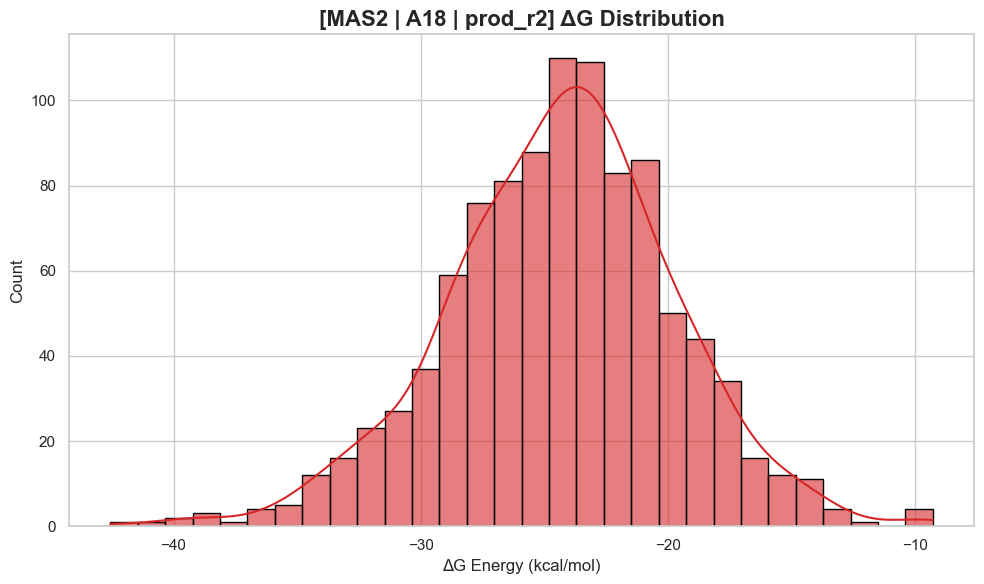

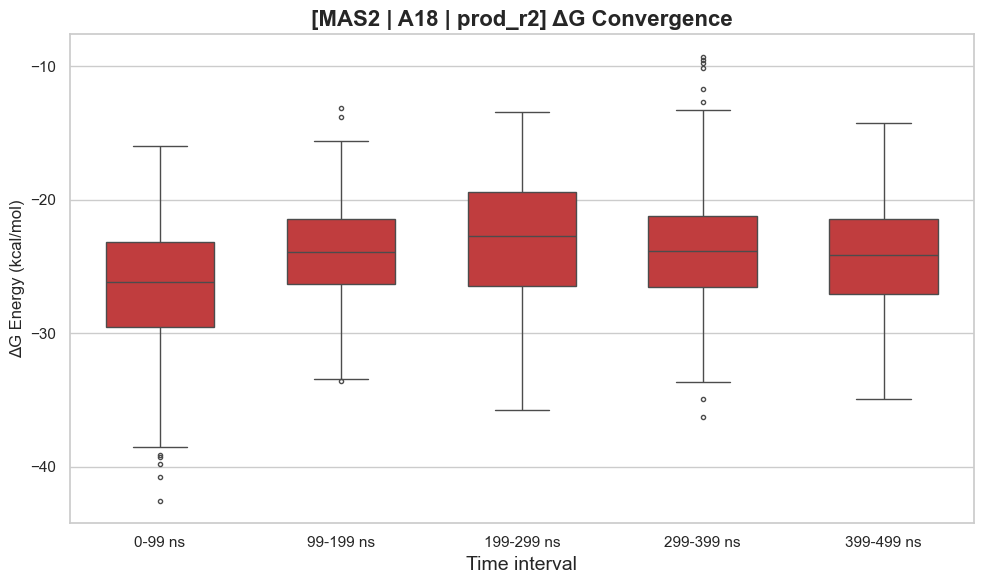

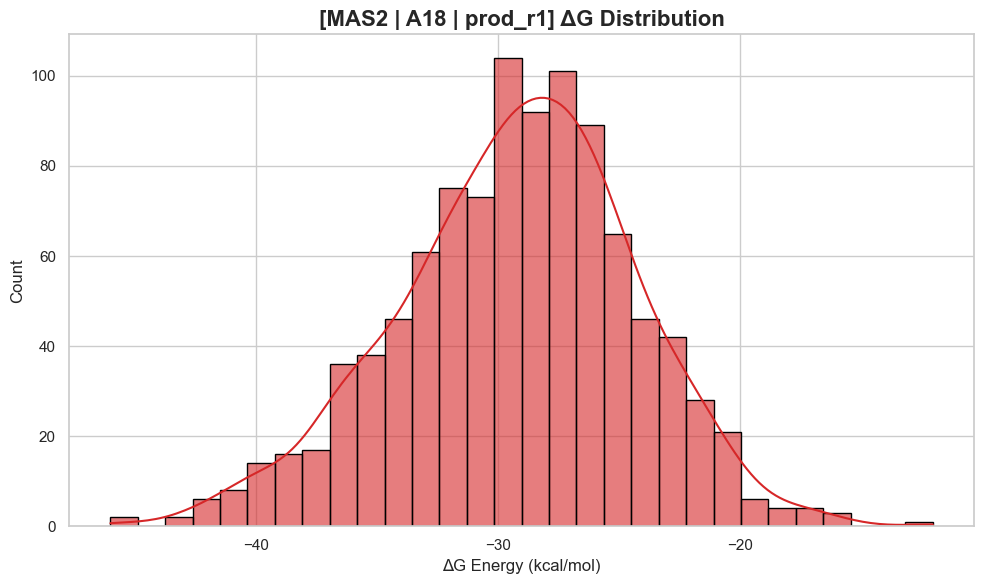

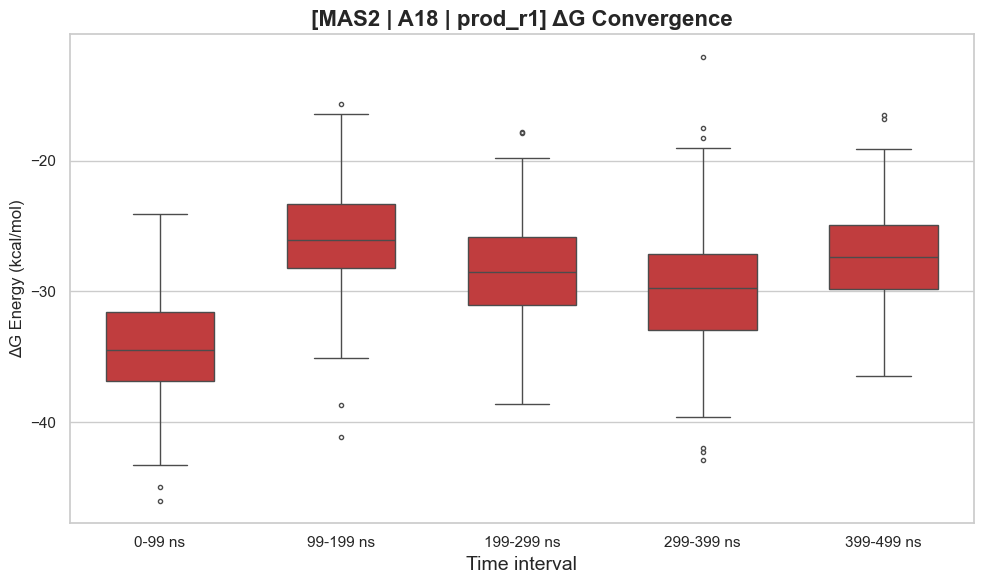

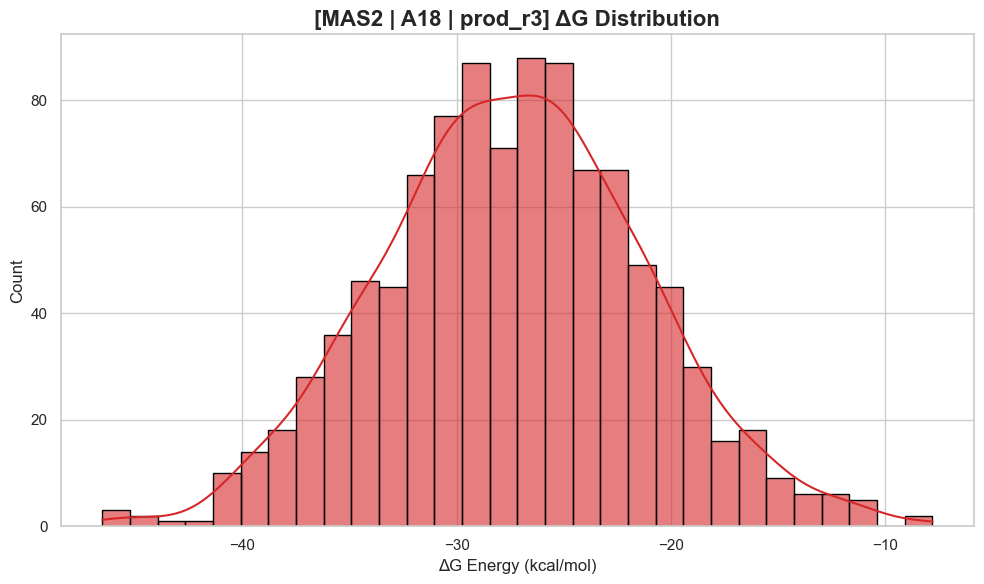

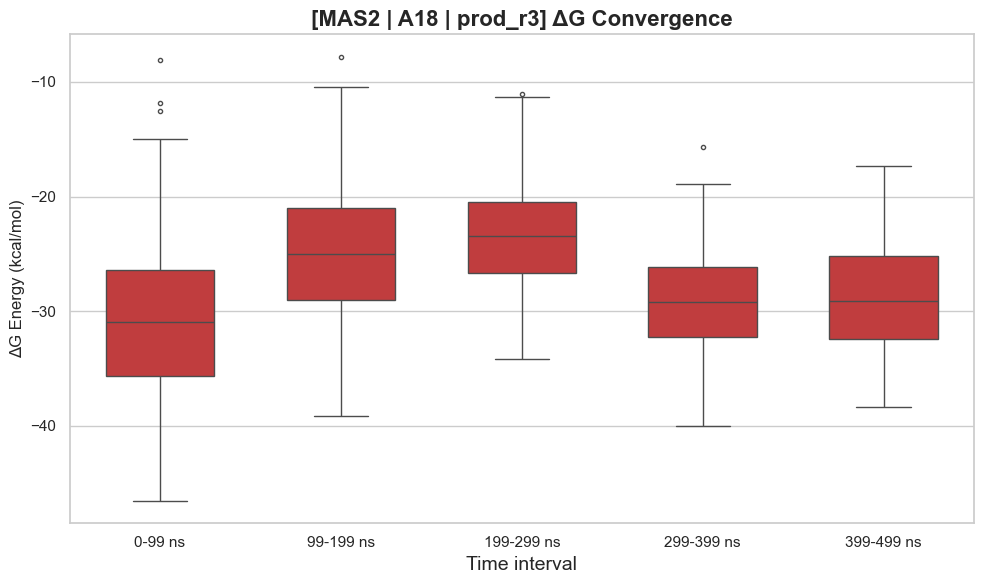

/tmp/ipykernel_6626/4218941446.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='System', y='Delta Energy', data=df_all, palette=palette, width=0.6, ax=ax_c)


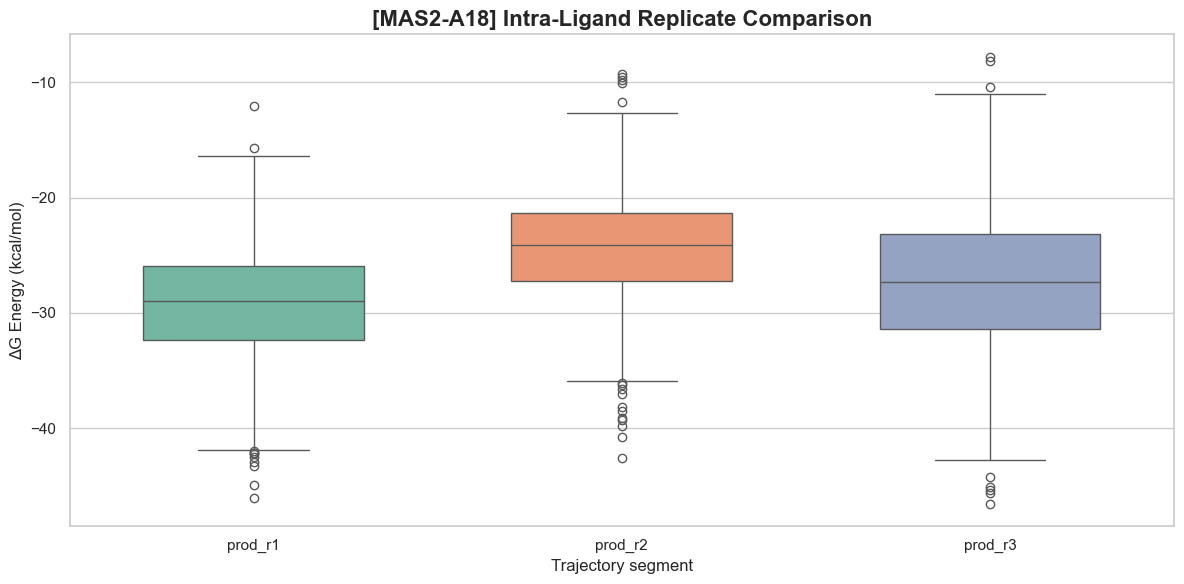

 -> Finished processing A18.

 Processing Ligand System: A19
 -> Detected 3 files.



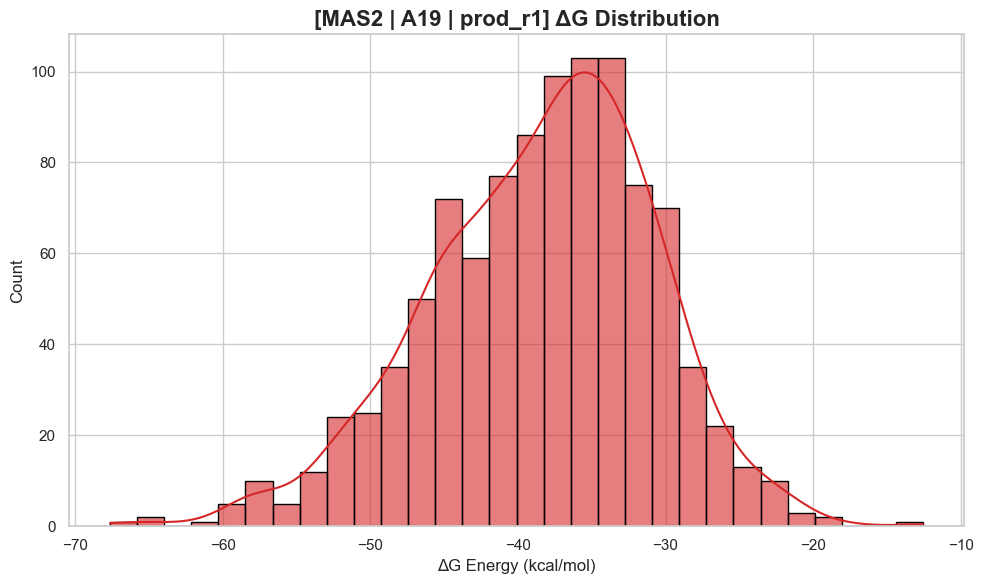

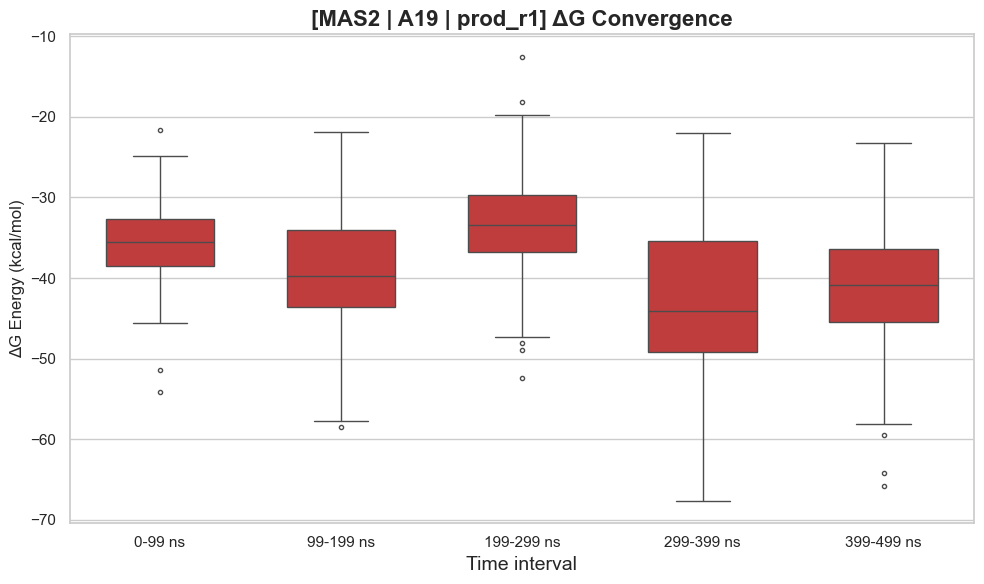

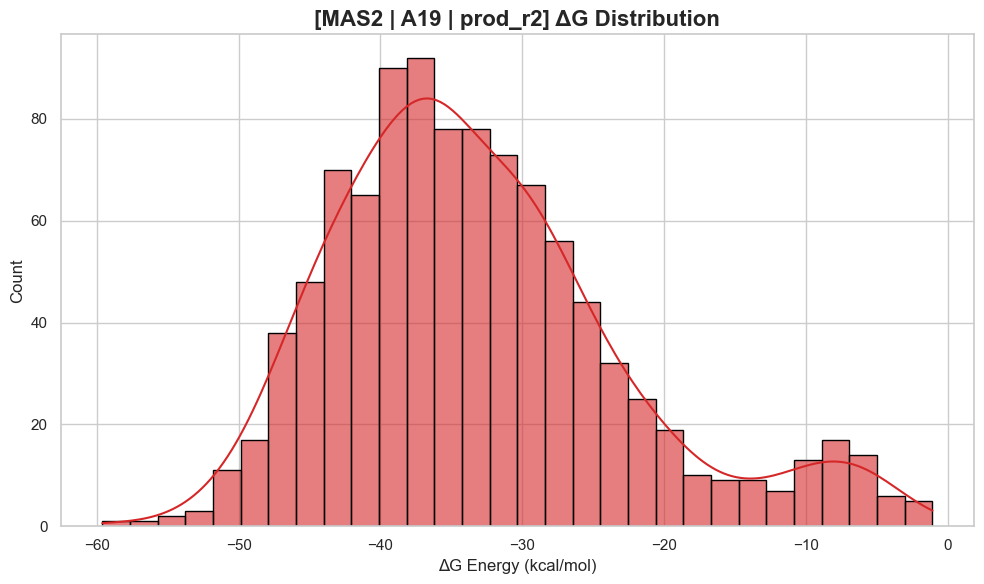

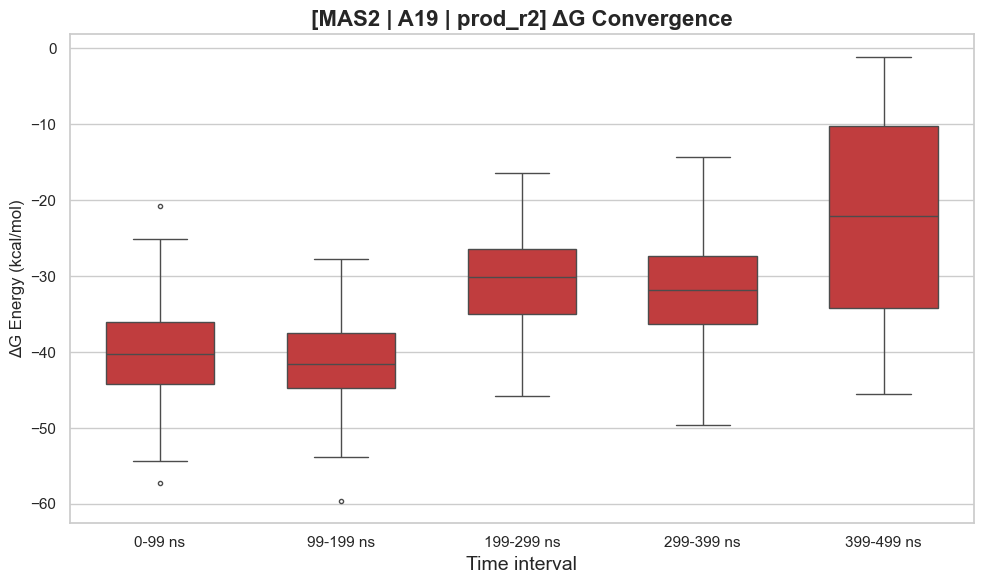

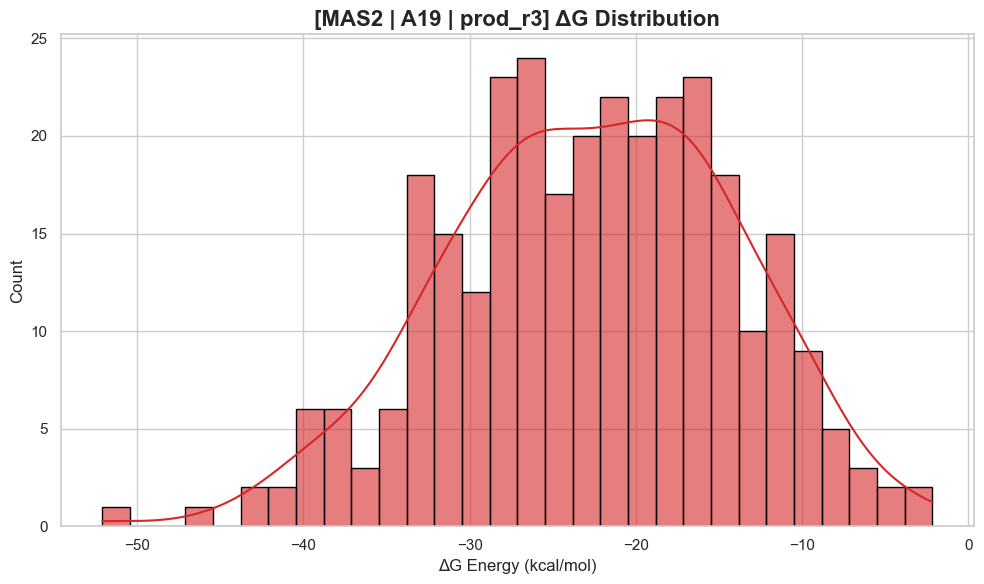

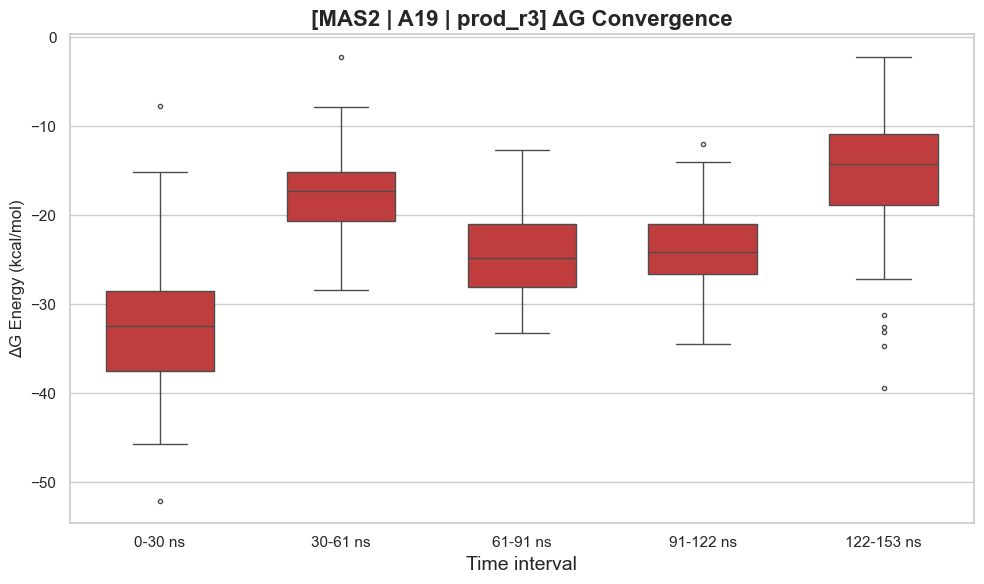

/tmp/ipykernel_6626/4218941446.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='System', y='Delta Energy', data=df_all, palette=palette, width=0.6, ax=ax_c)


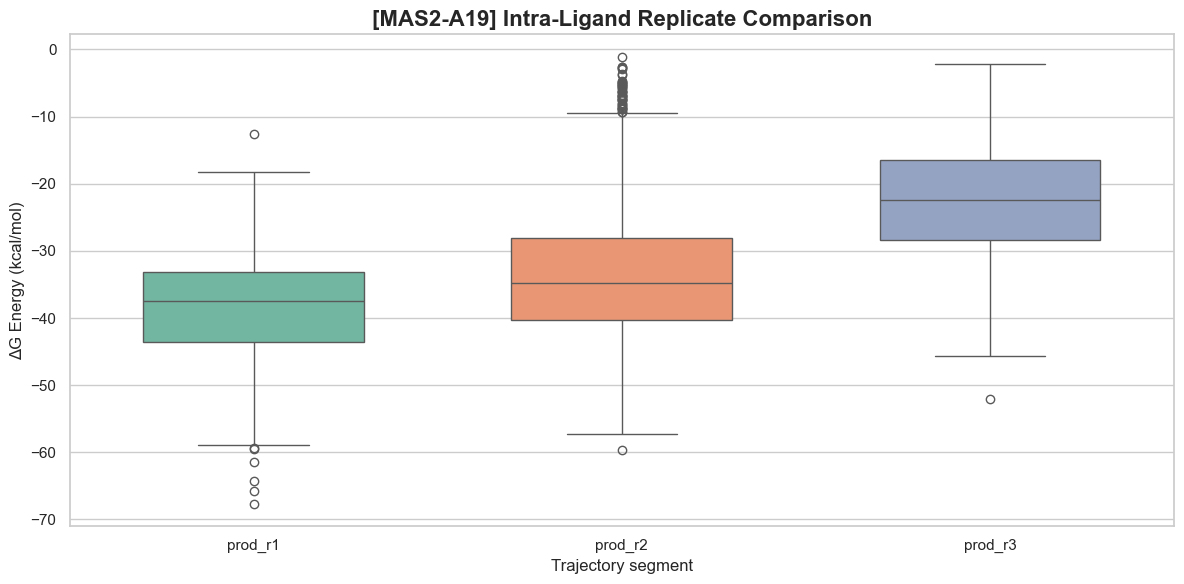

 -> Finished processing A19.

 Processing Ligand System: R16
 -> Detected 0 files.

 Processing Ligand System: A17
 -> Detected 3 files.



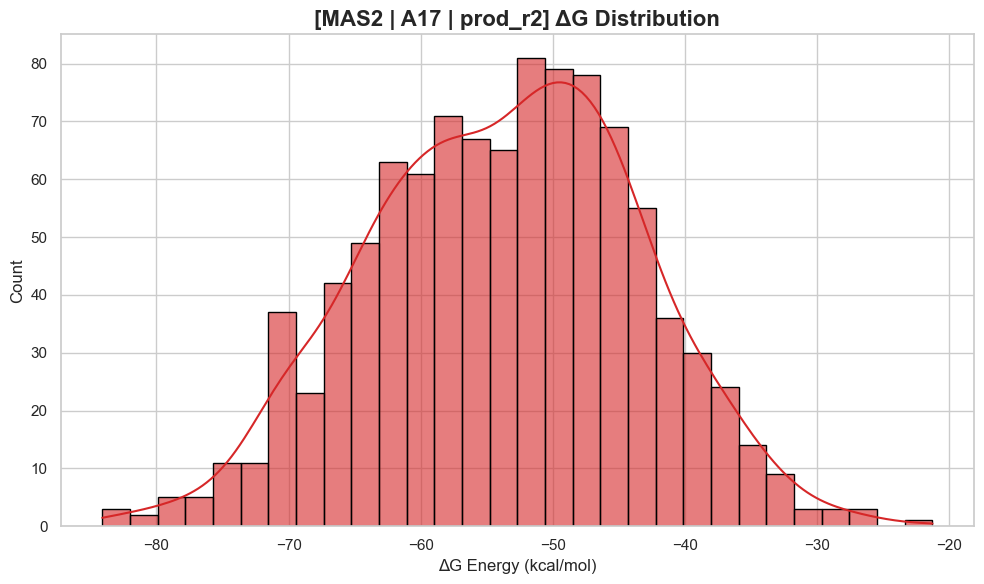

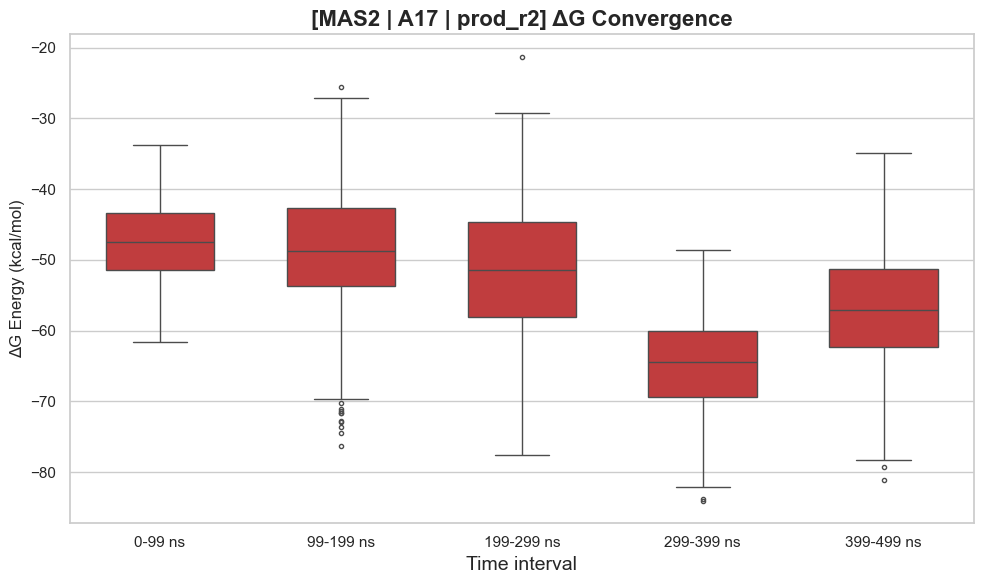

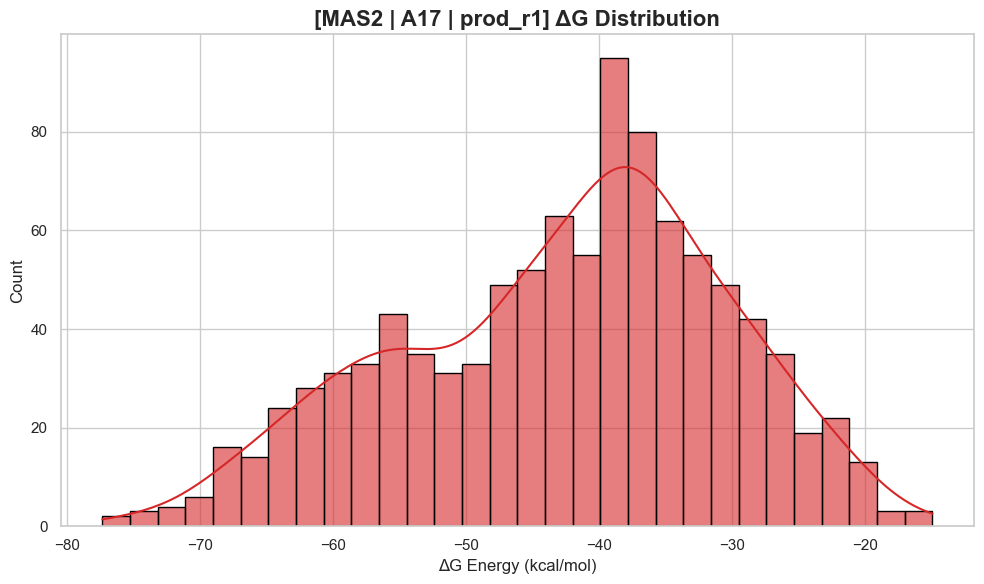

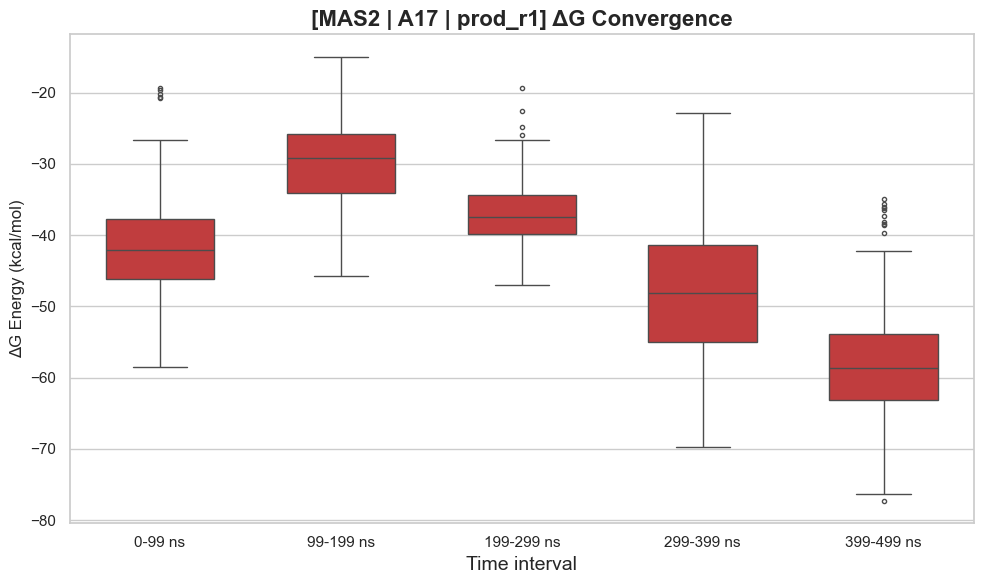

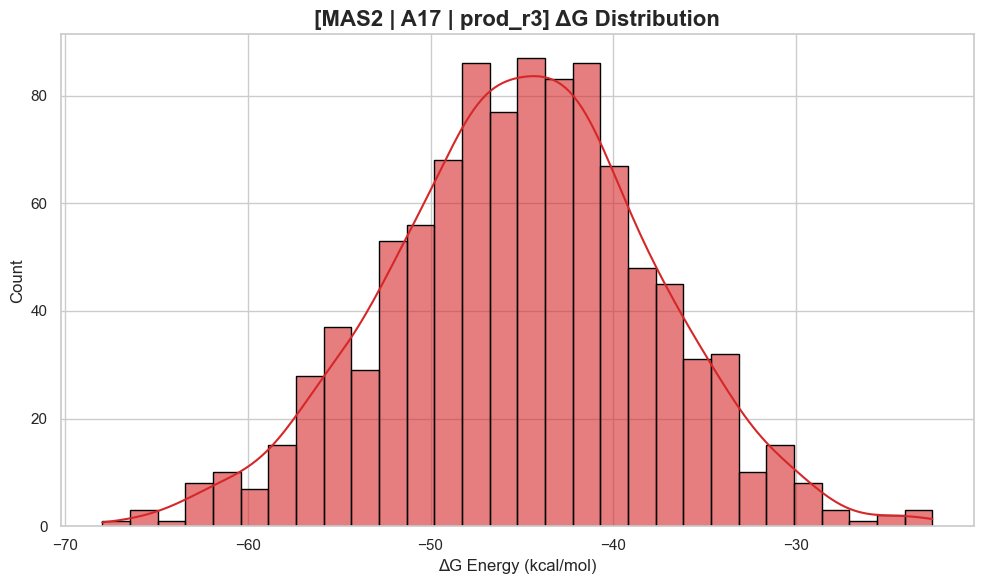

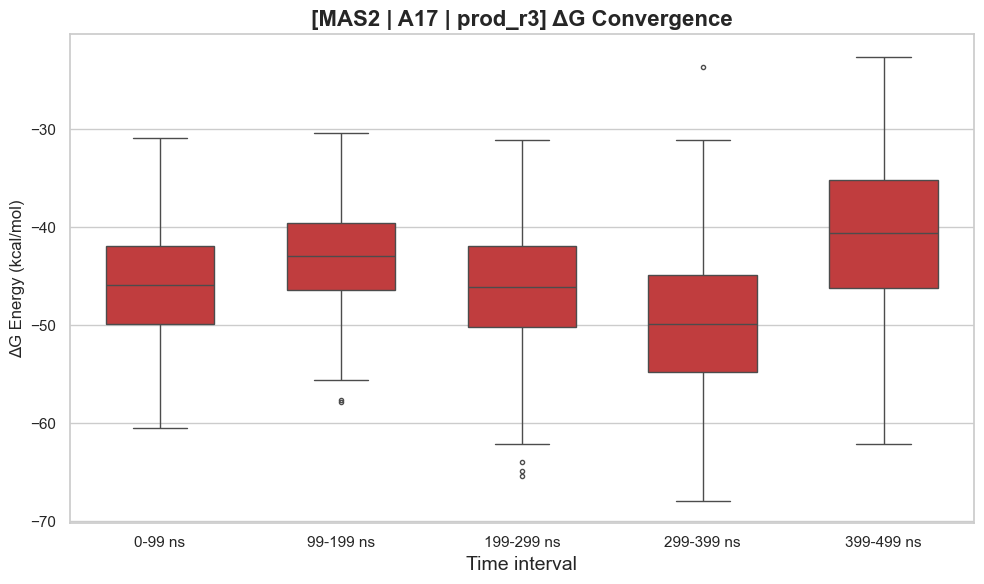

/tmp/ipykernel_6626/4218941446.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='System', y='Delta Energy', data=df_all, palette=palette, width=0.6, ax=ax_c)


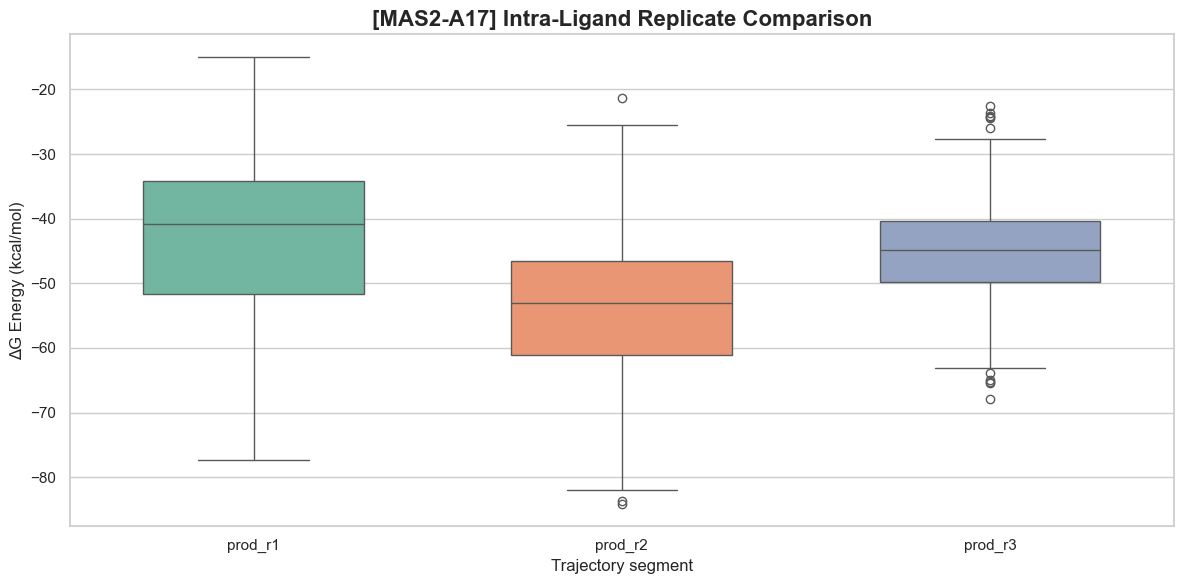

 -> Finished processing A17.

Master Loop Complete. Data ready for Global Visualization.


In [51]:
# Cell 4: Autonomous Master Loop (Parses and Generates Individual/Intra-Ligand Plots)
print("Executing Autonomous Master Extraction Loop...\n")

all_global_list = [] # Will hold EVERYTHING for Cell 5

for lig in ligand_folders:
    print(f"==================================================")
    print(f" Processing Ligand System: {lig}")
    print(f"==================================================")
    
    lig_path = base_path / lig
    lig_out_path = base_path / "DATA" / lig
    lig_out_path.mkdir(parents=True, exist_ok=True)
    
    if not lig_path.exists():
        print(f" [Warning] Directory {lig_path} not found. Skipping.\n")
        continue
        
    data_files = list(lig_path.glob(file_extension))
    print(f" -> Detected {len(data_files)} files.\n")
    
    lig_specific_dfs = []
    
    for f in data_files:
        df = parse_mmgbsa_to_df(f, ligand_name=lig)
        if not df.empty:
            lig_specific_dfs.append(df)
            all_global_list.append(df) # Feed the global list simultaneously
            
            # Generate and queue Individual Plots
            fig_h, fig_b = plot_individual_analysis(df, systemid, lig, histogram_bins, base_color, number_of_blocks, ind_energy_limits, ind_major_tick, ind_minor_tick)
            
            display(fig_h)
            display(fig_b)
            
            # --- THE FIX: Prevent Jupyter from double-printing at the end of the cell ---
            plt.close(fig_h)
            plt.close(fig_b)
            # ----------------------------------------------------------------------------
            
            short_name = df['System'].iloc[0]
            figures_to_export[lig_out_path / f"{systemid}_{short_name}_histogram"] = fig_h
            figures_to_export[lig_out_path / f"{systemid}_{short_name}_intervals"] = fig_b
            
    # Generate and queue Intra-Ligand Final Comparison
    if lig_specific_dfs:
        combined_lig_df = pd.concat(lig_specific_dfs, ignore_index=True)
        fig_c = plot_final_comparison(combined_lig_df, systemid, lig, combined_palette, comp_y_limits, comp_major_tick, comp_minor_tick)
        
        display(fig_c)
        
        # --- THE FIX ---
        plt.close(fig_c)
        # ---------------
        
        figures_to_export[lig_out_path / f"{systemid}-{lig}_Final_Comparison"] = fig_c
        print(f" -> Finished processing {lig}.\n")

print("Master Loop Complete. Data ready for Global Visualization.")

Generating Global Composite Figures...

Successfully aggregated 8307 data points across all systems.


/tmp/ipykernel_6626/2079545993.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax_det.set_xticklabels(clean_labels, rotation=45, ha='right')


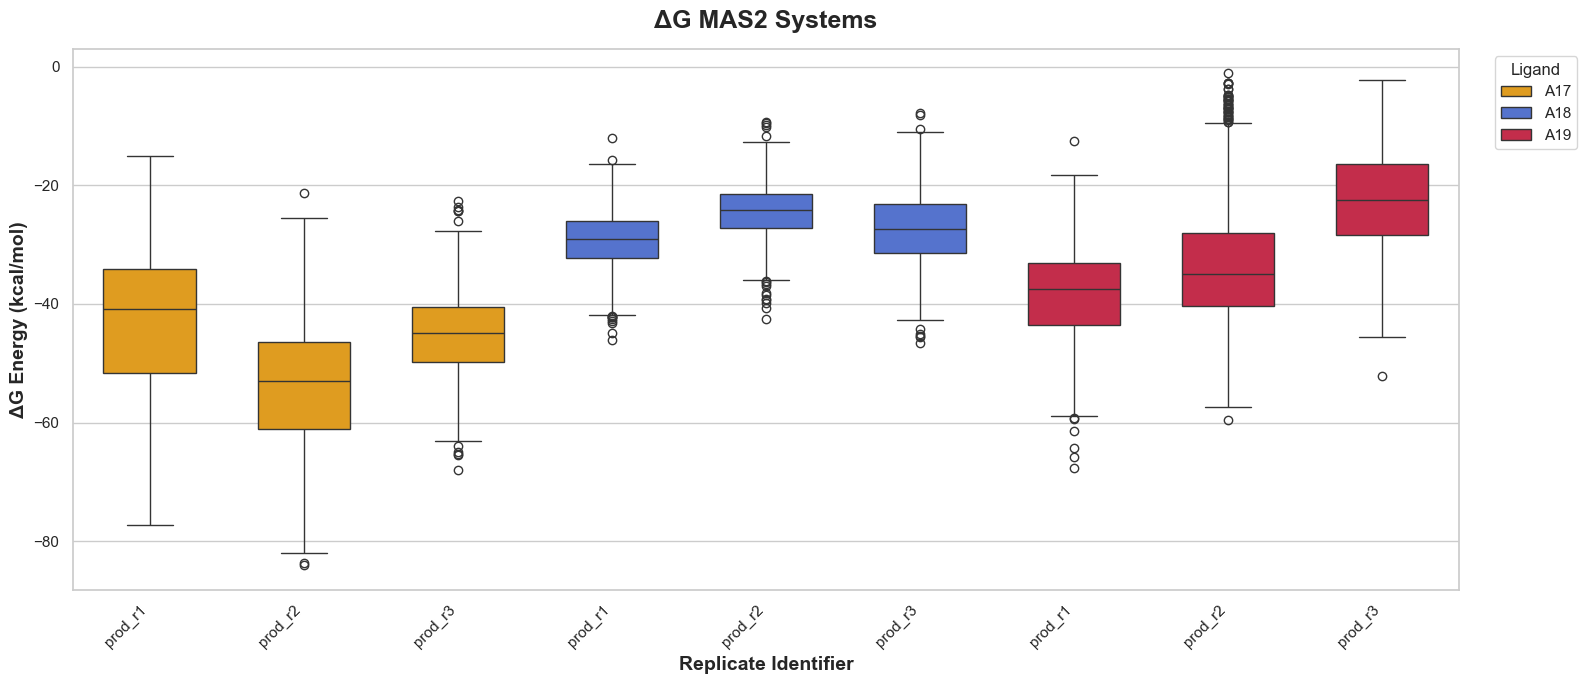

/tmp/ipykernel_6626/2079545993.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Ligand', y='Delta Energy', data=df_master_mmgbsa,


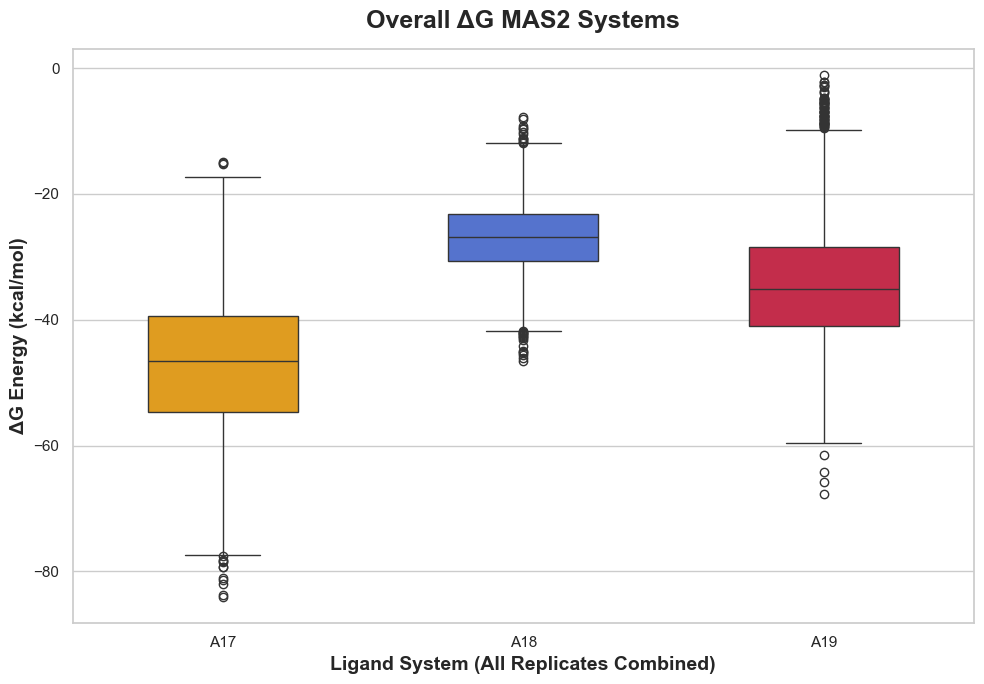

In [54]:
# Cell 5: Global Composite Visualization
print("Generating Global Composite Figures...\n")

sns.set_context("notebook")
sns.set_theme(style="whitegrid")

if all_global_list:
    df_master_mmgbsa = pd.concat(all_global_list, ignore_index=True)
    df_master_mmgbsa = df_master_mmgbsa.sort_values(by=["Ligand", "Replicate"])
    
    print(f"Successfully aggregated {len(df_master_mmgbsa)} data points across all systems.")

    # =====================================================================
    # Plot 1: Detailed Replicate Comparison
    # =====================================================================
    fig_det, ax_det = plt.subplots(figsize=(16, 7))
    sns.boxplot(x='Global_ID', y='Delta Energy', hue='Ligand', 
                data=df_master_mmgbsa, palette=global_palette, dodge=False, width=0.6, ax=ax_det)
    
    ax_det.set_title(f"\u0394G {systemid} Systems", fontsize=18, fontweight='bold', pad=15)
    ax_det.set_ylabel("\u0394G Energy (kcal/mol)", fontsize=14, fontweight='bold')
    ax_det.set_xlabel("Replicate Identifier", fontsize=14, fontweight='bold')
    
    current_labels = ax_det.get_xticklabels()
    clean_labels = [lbl.get_text().split('_', 1)[-1] for lbl in current_labels]
    ax_det.set_xticklabels(clean_labels, rotation=45, ha='right')

    ax_det.legend(title="Ligand", loc="upper left", bbox_to_anchor=(1.02, 1))
    fig_det.tight_layout()
    
    display(fig_det)
    # --- THE FIX ---
    plt.close(fig_det)
    # ---------------
    
    figures_to_export[global_out_path / "MMGBSA_Detailed_Replicates"] = fig_det

    # =====================================================================
    # Plot 2: Aggregated Ligand Comparison
    # =====================================================================
    fig_agg, ax_agg = plt.subplots(figsize=(10, 7))
    sns.boxplot(x='Ligand', y='Delta Energy', data=df_master_mmgbsa, 
                palette=global_palette, width=0.5, ax=ax_agg)
    
    ax_agg.set_title(f"Overall \u0394G {systemid} Systems", fontsize=18, fontweight='bold', pad=15)
    ax_agg.set_ylabel("\u0394G Energy (kcal/mol)", fontsize=14, fontweight='bold')
    ax_agg.set_xlabel("Ligand System (All Replicates Combined)", fontsize=14, fontweight='bold')
    
    fig_agg.tight_layout()
    
    display(fig_agg)
    # --- THE FIX ---
    plt.close(fig_agg)
    # ---------------
    
    figures_to_export[global_out_path / "MMGBSA_Aggregated_Ligands"] = fig_agg

else:
    print("No data found to aggregate.")

In [55]:
# Cell 6: Master File Export Node
print("Initiating Master File Export...\n")

# 1. Export Global CSV Table
if 'df_master_mmgbsa' in locals() and not df_master_mmgbsa.empty:
    df_master_mmgbsa.to_csv(fn_global_csv, index=False)
    print(f" [Saved CSV] -> {fn_global_csv}")

# 2. Export All Queued Figures Safely
if figures_to_export:
    exported_count = 0
    for base_path_obj, fig in figures_to_export.items():
        # Save figures using the objects stored in memory
        fig.savefig(f"{base_path_obj}.png", dpi=1200, bbox_inches="tight")
        fig.savefig(f"{base_path_obj}.pdf", bbox_inches="tight")
        exported_count += 1
        
        # Free memory by closing the figure now that it is written to disk
        plt.close(fig)
        
    print(f"\nSuccessfully exported {exported_count} plots to disk (.png and .pdf) and cleared memory!")
else:
    print("No figures found in the export queue.")

Initiating Master File Export...

 [Saved CSV] -> MAS2/DATA/GLOBAL_MMGBSA/Master_MMGBSA_Data.csv

Successfully exported 2 plots to disk (.png and .pdf) and cleared memory!


# Dihedrals

Initializing Global Dihedral Conformational Analysis...

Locating and aggregating Dihedral CSV files...
 -> Found data for CONTROL: CONTROL_Dihedral_Chi1.csv
 -> Found data for A18: A18_Dihedral_Chi1.csv
 -> Found data for A19: A19_Dihedral_Chi1.csv
 -> Found data for R16: R16_Dihedral_Chi1.csv
 -> Found data for A17: A17_Dihedral_Chi1.csv

Aggregation complete. Total frames loaded across all systems: 11372
Detected 2 Micro-Switch Motifs to compare: Ionic_Lock_R, NPxxY_Y



/tmp/ipykernel_4588/4143245447.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4588/4143245447.py:87: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


 -> Saved Global Comparison Boxplot: MAS2/DATA/Dihedral_Boxplot.png | .pdf


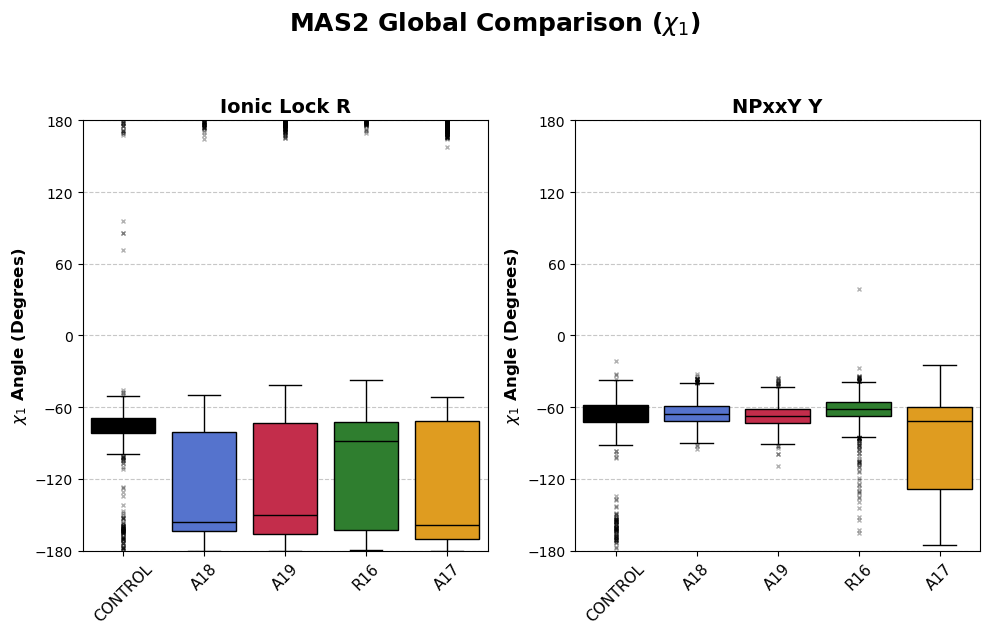

In [31]:
# Cell: Global Dihedral Comparison (Aggregation & Boxplot)
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

print("Initializing Global Dihedral Conformational Analysis...\n")

# --- 1. Configuration & Path Discovery ---
# Root directory where the DATA folders live
root_dir = f'{systemid}/' 
# Ensure this matches the exact names of the folders in your tree
target_systems = ["CONTROL", "A18", "A19", "R16", "A17"] 

# Keep colors consistent with your previous comparison plots
system_colors = {
    "CONTROL": "black",
    "A18": "royalblue",
    "A19": "crimson",
    "R16": "forestgreen",
    "A17": "orange"
}

# --- 2. Data Aggregation ---
print("Locating and aggregating Dihedral CSV files...")
master_dihedral_list = []

for sys_name in target_systems:
    # Use glob to find the specific dihedral CSV for the system
    search_pattern = os.path.join(root_dir, "DATA", sys_name, f"*{sys_name}_Dihedral_Chi1.csv")
    found_files = glob.glob(search_pattern)
    
    # Also check if it was named without the prefix just in case
    if not found_files:
        search_pattern = os.path.join(root_dir, "DATA", sys_name, "*Dihedral_Chi1.csv")
        found_files = glob.glob(search_pattern)
        
    if found_files:
        target_file = found_files[0]
        print(f" -> Found data for {sys_name}: {os.path.basename(target_file)}")
        
        # Read the CSV
        temp_df = pd.read_csv(target_file)
        # Inject the system name so we can group by it later
        temp_df['System'] = sys_name 
        master_dihedral_list.append(temp_df)
    else:
        print(f" -> [WARNING] No Dihedral CSV found for {sys_name} in {os.path.join(root_dir, 'DATA', sys_name)}")

if not master_dihedral_list:
    raise FileNotFoundError("Could not find any dihedral data to plot. Check your directory paths.")

# --- THE FIX: Changed ignore_axis to ignore_index ---
master_df = pd.concat(master_dihedral_list, ignore_index=True)
print(f"\nAggregation complete. Total frames loaded across all systems: {len(master_df)}")

# --- 3. Identify Plottable Motifs ---
# We want to plot every column that isn't Frame, Time_ns, System, or Time_Bin
ignore_cols = ['Frame', 'Time_ns', 'System', 'Time_Bin']
available_motifs = [col for col in master_df.columns if col not in ignore_cols]
n_motifs = len(available_motifs)

print(f"Detected {n_motifs} Micro-Switch Motifs to compare: {', '.join(available_motifs)}\n")

# --- 4. Plot Generation ---
fn_out_png = f'{systemid}/DATA/Dihedral_Boxplot.png'
fn_out_pdf = f'{systemid}/DATA/Dihedral_Boxplot.pdf'

# Ensure the output directory exists
os.makedirs("DATA/ALL", exist_ok=True)

# Create a figure with 1 row and 'n_motifs' columns
fig, axes = plt.subplots(nrows=1, ncols=n_motifs, figsize=(5 * n_motifs, 6))
fig.suptitle(f'{systemid} Global Comparison ($\chi_1$)', fontsize=18, fontweight='bold', y=1.05)

# Ensure axes is iterable even if there's only 1 motif
if n_motifs == 1:
    axes = [axes]

for idx, motif in enumerate(available_motifs):
    ax = axes[idx]
    
    # Create the boxplot
    sns.boxplot(
        data=master_df,
        x='System',
        y=motif,
        ax=ax,
        palette=system_colors,
        flierprops={"marker": "x", "markersize": 3, "alpha": 0.3} # Subtle outliers
    )
    
    # Formatting
    ax.set_title(f"{motif.replace('_', ' ')}", fontsize=14, fontweight='bold')
    ax.set_ylabel("$\chi_1$ Angle (Degrees)", fontsize=12, fontweight='bold')
    ax.set_xlabel("") # Remove the 'System' label from the bottom to keep it clean
    ax.tick_params(axis='x', rotation=45, labelsize=11)
    
    # Enforce strict standard dihedral bounds
    ax.set_ylim(-180, 180)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(60))
    ax.yaxis.grid(True, linestyle='--', alpha=0.7)

# Adjust layout to prevent overlap
plt.tight_layout()

# --- 5. Export ---
fig.savefig(fn_out_png, dpi=300, bbox_inches='tight')
fig.savefig(fn_out_pdf, bbox_inches='tight')

print(f" -> Saved Global Comparison Boxplot: {fn_out_png} | .pdf")
plt.show()

# Clean up memory
fig.clf()
plt.close(fig)

Generating Overlayed Polar Dihedral Distributions...

 -> Saved Polar Comparison Plot: MAS2/DATA/Dihedral_Polar.png | .pdf


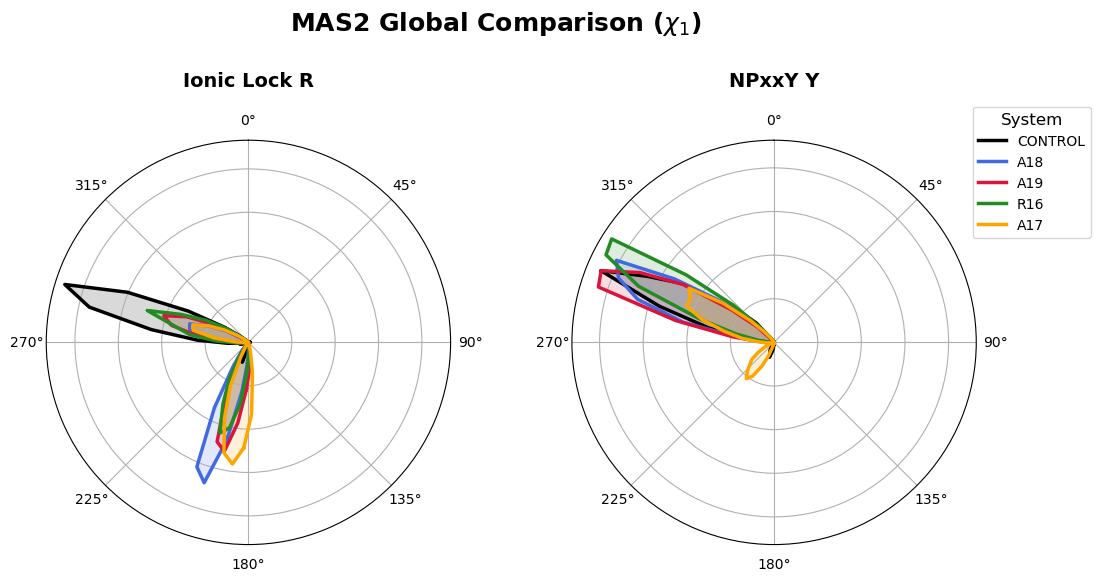

In [32]:
# Cell: Global Dihedral Comparison (Overlayed Polar Density Plots)
import numpy as np
import matplotlib.pyplot as plt
import os

print("Generating Overlayed Polar Dihedral Distributions...\n")

# --- 1. Figure Setup ---
fn_out_polar_png = f'{systemid}/DATA/Dihedral_Polar.png'
fn_out_polar_pdf = f'{systemid}/DATA/Dihedral_Polar.pdf'
os.makedirs("DATA/ALL", exist_ok=True)

# We use subplot_kw={'polar': True} to force 360-degree radial axes
fig_polar, axes_polar = plt.subplots(nrows=1, ncols=n_motifs, figsize=(6 * n_motifs, 6), subplot_kw={'polar': True})
fig_polar.suptitle(f'{systemid} Global Comparison ($\chi_1$)', fontsize=18, fontweight='bold', y=1.05)

if n_motifs == 1:
    axes_polar = [axes_polar]

# --- 2. Plotting Logic ---
# We bin the angles into 5-degree increments across the full -180 to 180 spectrum
bins_deg = np.linspace(-180, 180, 73)
bins_rad = np.radians(bins_deg)
bin_centers_rad = (bins_rad[:-1] + bins_rad[1:]) / 2

# To cleanly draw a continuous loop in a polar plot, the last point must mathematically connect back to the first point
bin_centers_closed = np.append(bin_centers_rad, bin_centers_rad[0])

for idx, motif in enumerate(available_motifs):
    ax = axes_polar[idx]
    
    for sys_name in target_systems:
        # Extract data for this specific system and motif
        sys_data = master_df[master_df['System'] == sys_name][motif].dropna()
        
        if not sys_data.empty:
            # Calculate the density of frames in each 5-degree bin
            hist, _ = np.histogram(sys_data, bins=bins_deg, density=True)
            hist_closed = np.append(hist, hist[0])
            
            # Plot the thick outline
            ax.plot(bin_centers_closed, hist_closed, color=system_colors[sys_name], linewidth=2.5, label=sys_name)
            # Add a faint, transparent fill so we can see overlapping distributions
            ax.fill(bin_centers_closed, hist_closed, color=system_colors[sys_name], alpha=0.15)
            
    # --- Formatting the Polar Canvas ---
    ax.set_title(f"{motif.replace('_', ' ')}", fontsize=14, fontweight='bold', pad=20)
    
    # Standardize the orientation (0 degrees at the top, rotating clockwise)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    
    # Hide the raw density values on the concentric rings to keep the plot clean
    ax.set_yticklabels([]) 
    
    # Add the legend to the right of the plot
    if idx == n_motifs - 1:
        ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), title="System", fontsize=10, title_fontsize=12)

# Prevent plots from crashing into each other
plt.subplots_adjust(wspace=0.3)

# --- 3. Export ---
fig_polar.savefig(fn_out_polar_png, dpi=300, bbox_inches='tight')
fig_polar.savefig(fn_out_polar_pdf, bbox_inches='tight')

print(f" -> Saved Polar Comparison Plot: {fn_out_polar_png} | .pdf")
plt.show()

# Clean up memory
fig_polar.clf()
plt.close(fig_polar)